# Temporal Analysis of Users according to their ideology and credibility.


In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [132]:
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.
df_links = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_links.csv") # Import data from Voluntarios de Valencia groupchat with messages with links and misinformation score.
df_users = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_users.csv") # Import data from Voluntarios de Valencia groupchat with user information.

In [133]:
df_users.head()

,sender_id,ideology_score,credibility_score
0,1110241832,0,-1
1,5919794964,0,0
2,1093591792,0,0
3,1622328415,0,0
4,6618601093,0,0


## Ideology_score division

In [134]:
# Divide users into three groups based on their ideology score: neutral, right-wing, and left-wing.
neutral_users = df_users[df_users['ideology_score'] == 0] # Gather users with a neutral ideology score (0).
right_users = df_users[df_users['ideology_score'] > 0] # Gather users with a right-wing ideology score.
left_users = df_users[df_users['ideology_score'] < 0] # Gather users with a left-wing ideology score.

In [135]:
neutral_users.size, right_users.size, left_users.size


(1221, 105, 15)

In [136]:
neutral_users_id = neutral_users['sender_id'].tolist() # Get the sender IDs of neutral users.
right_users_id = right_users['sender_id'].tolist() # Get the sender IDs of right-wing users.
left_users_id = left_users['sender_id'].tolist() # Get the sender IDs of left-wing users.

In [137]:
# Gather messages sent by neutral users, right-wing users, and left-wing users.
neutral_messages = df[df['sender_id'].isin(neutral_users_id)] # Gather messages sent by neutral users.
right_messages = df[df['sender_id'].isin(right_users_id)] # Gather messages sent by right-wing users.
left_messages = df[df['sender_id'].isin(left_users_id)] # Gather messages sent by left-wing users.

neutral_messages.size, right_messages.size, left_messages.size

(118660, 46155, 9486)

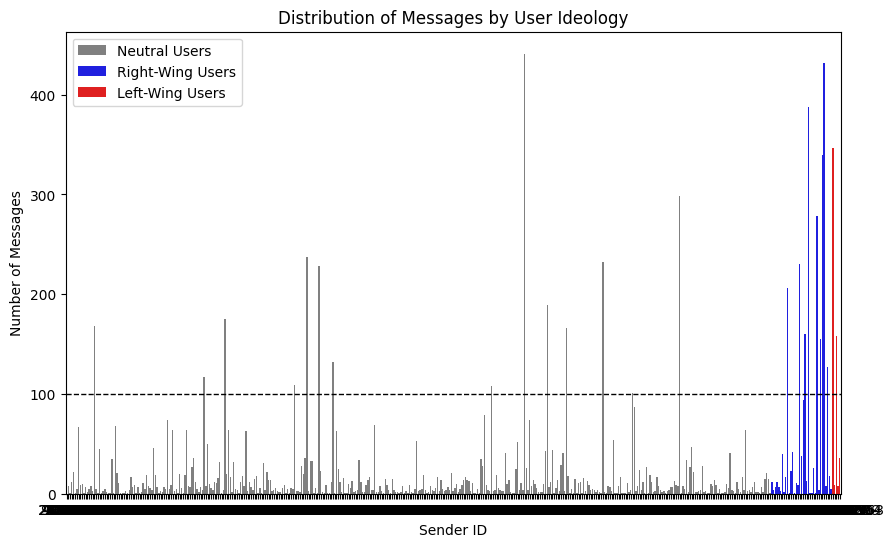

In [141]:
# Plot the distribution of messages sent by neutral users, right-wing users, and left-wing users.
plt.figure(figsize=(10, 6))
sns.countplot(x='sender_id', data=neutral_messages, color='gray', label='Neutral Users')
sns.countplot(x='sender_id', data=right_messages, color='blue', label='Right-Wing Users')
sns.countplot(x='sender_id', data=left_messages, color='red', label='Left-Wing Users')
plt.axhline(y=100, color='black', linestyle='--', linewidth=1) # Add a horizontal line at y=100 for better visualization of the distribution of the cutoff.
plt.xlabel('Sender ID')
plt.ylabel('Number of Messages')
plt.title('Distribution of Messages by User Ideology')
plt.legend()
plt.show()

In [ ]:
# gather users with 100 or more messages sent for each ideology group
neutral_active_users = neutral_messages['sender_id'].value_counts()[neutral_messages['sender_id'].value_counts() >= 100].index.tolist() # Gather sender IDs of neutral users with 100 or more messages sent.
right_active_users = right_messages['sender_id'].value_counts()[right_messages['sender_id'].value_counts() >= 100].index.tolist() # Gather sender IDs of right-wing users with 100 or more messages sent.
left_active_users = left_messages['sender_id'].value_counts()[left_messages['sender_id'].value_counts() >= 100].index.tolist() # Gather sender IDs of left-wing users with 100 or more messages sent.
len(neutral_active_users), len(right_active_users), len(left_active_users)

(14, 9, 2)

In [ ]:
# from these active users, get their period of activity and number of messages sent

def print_active_users_summary(group_name, active_users, messages_df):
    print("=" * 70)
    print(f"{group_name} Active Users:\n")
    print("=" * 70)
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        period_of_activity = user_dates.max() - user_dates.min() # Calculate the period of activity of the user.
        number_of_messages = user_messages.shape[0] # Calculate the number of messages sent by the user.
        print(f"User {user} has a period of activity of {period_of_activity} and has sent {number_of_messages} messages.")

print_active_users_summary("Neutral", neutral_active_users, neutral_messages)
print_active_users_summary("Right", right_active_users, right_messages)
print_active_users_summary("Left", left_active_users, left_messages)


Neutral Active Users:

User 1762777403 has a period of activity of 52 days 17:26:21 and has sent 441 messages.
User 6601816159 has a period of activity of 40 days 08:34:08 and has sent 298 messages.
User 1095473116 has a period of activity of 7 days 12:38:49 and has sent 237 messages.
User 5689570195 has a period of activity of 104 days 06:51:49 and has sent 232 messages.
User 1110241832 has a period of activity of 375 days 22:27:23 and has sent 228 messages.
User 2047003776 has a period of activity of 358 days 09:02:19 and has sent 189 messages.
User 791270353 has a period of activity of 56 days 17:01:07 and has sent 175 messages.
User 57072401 has a period of activity of 25 days 02:03:04 and has sent 168 messages.
User 5212333848 has a period of activity of 6 days 04:21:20 and has sent 166 messages.
User 1131058651 has a period of activity of 48 days 15:04:11 and has sent 132 messages.
User 693274644 has a period of activity of 9 days 18:07:40 and has sent 117 messages.
User 10653321

In [ ]:
# Remove users with a period of activity of less than 10 days

def filter_users_by_activity(active_users, messages_df, min_days=10):
    kept_users = []
    min_period = pd.Timedelta(days=min_days)
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        if user_dates.empty:
            continue
        period_of_activity = user_dates.max() - user_dates.min() # Calculate the period of activity of the user.
        if period_of_activity >= min_period:
            kept_users.append(user)
    return kept_users

neutral_active_users = filter_users_by_activity(neutral_active_users, neutral_messages, min_days=10)
right_active_users = filter_users_by_activity(right_active_users, right_messages, min_days=10)
left_active_users = filter_users_by_activity(left_active_users, left_messages, min_days=10)

len(neutral_active_users), len(right_active_users), len(left_active_users)

(10, 7, 2)

In [ ]:
# from these filtered active users, get their period of activity and number of messages sent
print_active_users_summary("Neutral", neutral_active_users, neutral_messages)
print_active_users_summary("Right", right_active_users, right_messages)
print_active_users_summary("Left", left_active_users, left_messages)


Neutral Active Users:

User 1762777403 has a period of activity of 52 days 17:26:21 and has sent 441 messages.
User 6601816159 has a period of activity of 40 days 08:34:08 and has sent 298 messages.
User 5689570195 has a period of activity of 104 days 06:51:49 and has sent 232 messages.
User 1110241832 has a period of activity of 375 days 22:27:23 and has sent 228 messages.
User 2047003776 has a period of activity of 358 days 09:02:19 and has sent 189 messages.
User 791270353 has a period of activity of 56 days 17:01:07 and has sent 175 messages.
User 57072401 has a period of activity of 25 days 02:03:04 and has sent 168 messages.
User 1131058651 has a period of activity of 48 days 15:04:11 and has sent 132 messages.
User 1551829597 has a period of activity of 213 days 00:44:52 and has sent 108 messages.
User 5992929865 has a period of activity of 257 days 11:13:23 and has sent 101 messages.
Right Active Users:

User 7094531229 has a period of activity of 108 days 03:26:50 and has sent

### Waiting times for neutral users

In [ ]:
# Plain power-law fit function for waiting times, with comparisons to other distributions and KS test on the tail
import powerlaw
from scipy import stats

def fit_power_law_report(waiting_times_input, label, discrete=True, show_results=True, show_plots=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        if show_results:
            print("=" * 70)
            print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
            print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    pl = fit_pl.power_law

    alpha_pl = getattr(pl, "alpha", np.nan)
    xmin_pl = getattr(pl, "xmin", np.nan)
    sigma_pl = getattr(pl, "sigma", np.nan)

    tail_pl = np.sort(data_pl[data_pl >= xmin_pl])
    if len(tail_pl) == 0:
        ks_pl = float("nan")
        ks_p_pl = float("nan")
    else:
        empirical_cdf_pl = np.arange(1, len(tail_pl) + 1) / len(tail_pl)
        try:
            model_cdf_pl = pl.cdf(tail_pl)
        except Exception:
            model_cdf_pl = 1 - pl.ccdf(tail_pl)
        ks_pl = np.max(np.abs(empirical_cdf_pl - model_cdf_pl))
        _, ks_p_pl = stats.kstest(tail_pl, pl.cdf)

    if show_results:
        print("=" * 70)
        print(f"POWER LAW FIT RESULTS: {label}")
        print("=" * 70)
        print(f"alpha: {alpha_pl:.4f}")
        print(f"xmin: {xmin_pl:.4f}")
        print(f"sigma: {sigma_pl:.4f}")
        n_tail_pl = int(np.sum(data_pl >= xmin_pl))
        print(f"Data points above xmin: {n_tail_pl} / {len(data_pl)} ({100 * n_tail_pl / len(data_pl):.2f}%)")

        print("\n" + "=" * 70)
        print("POWER LAW COMPARISONS")
        print("=" * 70)
        comparisons = [
            ("power_law", "truncated_power_law", "Power Law vs Truncated PL"),
            ("power_law", "lognormal", "Power Law vs Lognormal"),
            ("power_law", "exponential", "Power Law vs Exponential"),
        ]

        for d1, d2, cmp_label in comparisons:
            R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
            print(f"\n{cmp_label}:")
            print(f"  R = {R:.4f}, p = {p:.4f}")
            if p < 0.05:
                if R > 0:
                    print("  Power law is significantly better")
                else:
                    print(f"  {d2.replace('_', ' ')} is significantly better")
            else:
                print("  No significant difference")

        print("\n" + "=" * 70)
        print(f"KS distance (power law): {ks_pl:.4f}")
        print(f"KS p-value (tail): {ks_p_pl:.6g}")
        print("=" * 70)

    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
        pl.plot_pdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[0])
        fit_pl.truncated_power_law.plot_pdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[0])
        fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
        axes[0].set_xlabel("Waiting Time (seconds)")
        axes[0].set_ylabel("P(X = x)")
        axes[0].set_title(f"PDF: {label} (Power-law fit)")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
        pl.plot_ccdf(color="royalblue", linestyle="--", linewidth=2, label=f"Power Law (alpha={alpha_pl:.2f})", ax=axes[1])
        fit_pl.truncated_power_law.plot_ccdf(color="crimson", linestyle="--", linewidth=1.8, label="Truncated PL", ax=axes[1])
        fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
        axes[1].set_xlabel("Waiting Time (seconds)")
        axes[1].set_ylabel("P(X > x)")
        axes[1].set_title(f"CCDF: {label} (Power-law fit)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return fit_pl

In [ ]:
# Truncated power-law fit function for waiting times, with comparisons to other distributions and KS test on the tail
def fit_truncated_power_law_report(waiting_times_input, label, discrete=True, show_results=True, show_plots=True):
    data_pl = np.asarray(waiting_times_input, dtype=float)
    data_pl = data_pl[np.isfinite(data_pl)]
    data_pl = data_pl[data_pl > 0]

    if len(data_pl) < 20:
        print("=" * 70)
        print(f"{label}: Not enough data to fit reliably (n={len(data_pl)}).")
        print("=" * 70)
        return None

    fit_pl = powerlaw.Fit(data_pl, discrete=discrete, verbose=False)
    tpl = fit_pl.truncated_power_law

    alpha_tpl = getattr(tpl, "alpha", np.nan)
    lambda_tpl = getattr(tpl, "lambda_", np.nan)
    xmin_tpl = getattr(tpl, "xmin", np.nan)
    sigma_tpl = getattr(tpl, "sigma", np.nan)
    if show_results:
        print("=" * 70)
        print(f"TRUNCATED POWER LAW FIT RESULTS: {label}")
        print("=" * 70)
        print(f"alpha: {alpha_tpl:.4f}")
        print(f"lambda: {lambda_tpl:.4f}")
        print(f"xmin: {xmin_tpl:.4f}")
        print(f"sigma: {sigma_tpl:.4f}")
        n_tail_tpl = int(np.sum(data_pl >= xmin_tpl))
        print(f"Data points above xmin: {n_tail_tpl} / {len(data_pl)} ({100 * n_tail_tpl / len(data_pl):.2f}%)")

        print("\n" + "=" * 70)
        print("TRUNCATED POWER LAW COMPARISONS")
        print("=" * 70)
        comparisons = [
            ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
            ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
            ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
        ]

        for d1, d2, cmp_label in comparisons:
            R, p = fit_pl.distribution_compare(d1, d2, normalized_ratio=True)
            print(f"\n{cmp_label}:")
            print(f"  R = {R:.4f}, p = {p:.4f}")
            if p < 0.05:
                if R > 0:
                    print(f"  Truncated power law is significantly better")
                else:                
                    print(f"  {d2.replace('_', ' ')} is significantly better")
            else:            
                print("  No significant difference")
        tail_tpl = np.sort(data_pl[data_pl >= xmin_tpl])
        if len(tail_tpl) == 0:
            ks_tpl = float("nan")
            ks_p_tpl = float("nan")
        else:
            empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
            try:
                model_cdf_tpl = tpl.cdf(tail_tpl)
            except Exception:
                model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
            ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))
            ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)
        
        print("\n" + "=" * 70)
        print(f"KS distance (truncated power law): {ks_tpl:.4f}")
        print(f"KS p-value (tail): {ks_p_tpl:.6g}")
        print("=" * 70)
    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fit_pl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
        tpl.plot_pdf(color="crimson", linestyle="--", linewidth=2, label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.2f})", ax=axes[0])
        fit_pl.power_law.plot_pdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[0])
        fit_pl.lognormal.plot_pdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[0])
        axes[0].set_xlabel("Waiting Time (seconds)")
        axes[0].set_ylabel("P(X = x)")
        axes[0].set_title(f"PDF: {label} (Truncated Power-law fit)")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        fit_pl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
        tpl.plot_ccdf(color="crimson", linestyle="--", linewidth=2, label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.2f})", ax=axes[1])
        fit_pl.power_law.plot_ccdf(color="royalblue", linestyle="--", linewidth=1.8, label="Power Law", ax=axes[1])
        fit_pl.lognormal.plot_ccdf(color="darkorange", linestyle="--", linewidth=1.8, label="Lognormal", ax=axes[1])
        axes[1].set_xlabel("Waiting Time (seconds)")
        axes[1].set_ylabel("P(X > x)")
        axes[1].set_title(f"CCDF: {label} (Truncated Power-law fit)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    return fit_pl




Analyzing waiting times for Neutral User 1762777403...
POWER LAW FIT RESULTS: Neutral User 1762777403
alpha: 1.4724
xmin: 437.0000
sigma: 0.0384
Data points above xmin: 151 / 427 (35.36%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -2.4602, p = 0.0041
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.3124, p = 0.1894
  No significant difference

Power Law vs Exponential:
  R = 6.8412, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0429
KS p-value (tail): 0.834089


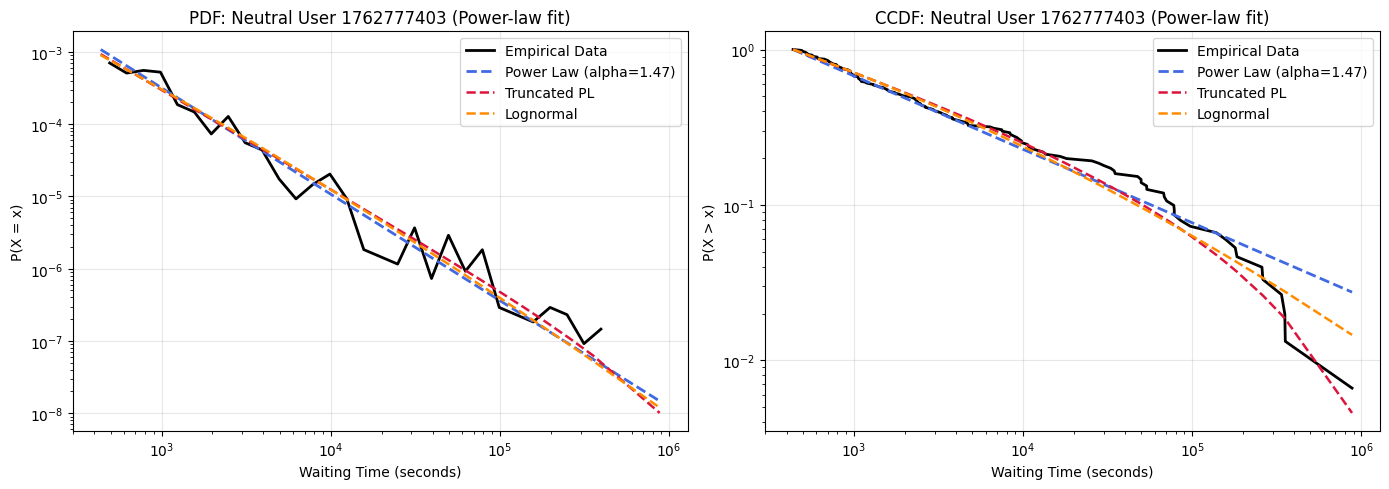

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Neutral User 1762777403
alpha: 1.3740
lambda: nan
xmin: 437.0000
sigma: nan
Data points above xmin: 151 / 427 (35.36%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.4602, p = 0.0041
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 2.7630, p = 0.0057
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 7.2816, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0644
KS p-value (tail): 0.536928


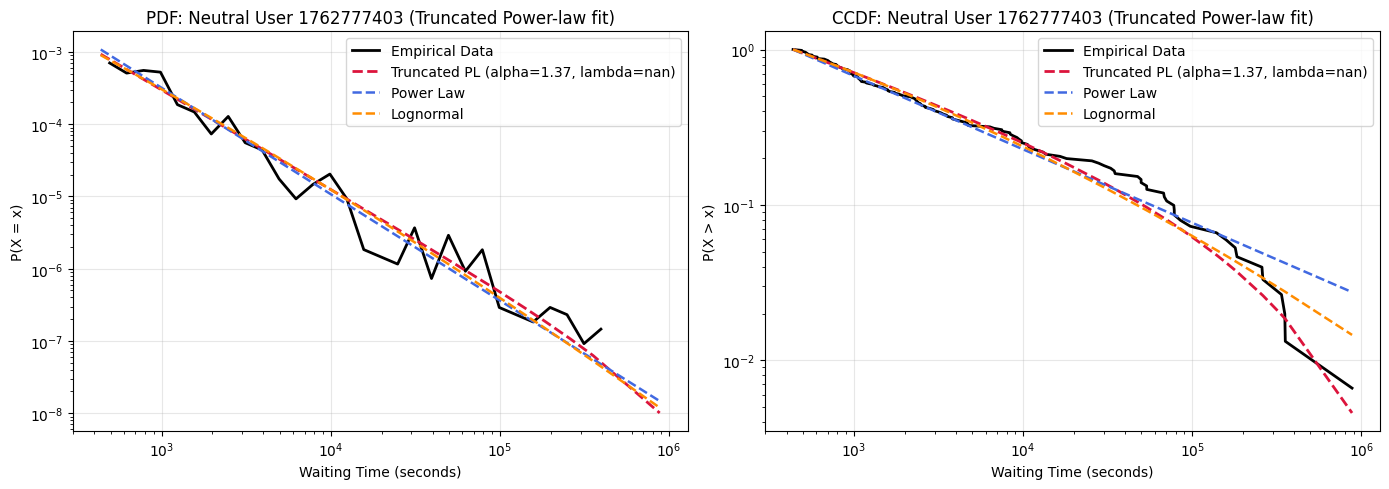



Analyzing waiting times for Neutral User 6601816159...
POWER LAW FIT RESULTS: Neutral User 6601816159
alpha: 1.3602
xmin: 46.0000
sigma: 0.0265
Data points above xmin: 185 / 280 (66.07%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -3.1298, p = 0.0005
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.7754, p = 0.0758
  No significant difference

Power Law vs Exponential:
  R = 9.4921, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0440
KS p-value (tail): 0.736985


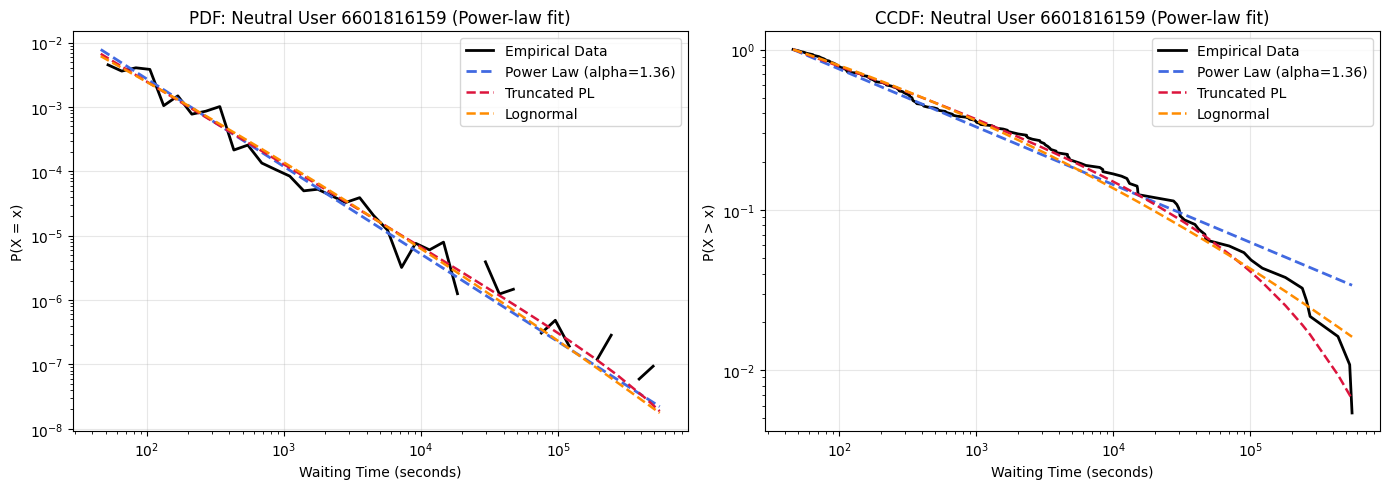

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Neutral User 6601816159
alpha: 1.2830
lambda: nan
xmin: 46.0000
sigma: nan
Data points above xmin: 185 / 280 (66.07%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 3.1298, p = 0.0005
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 2.4766, p = 0.0133
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 9.9557, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0617
KS p-value (tail): 0.464033


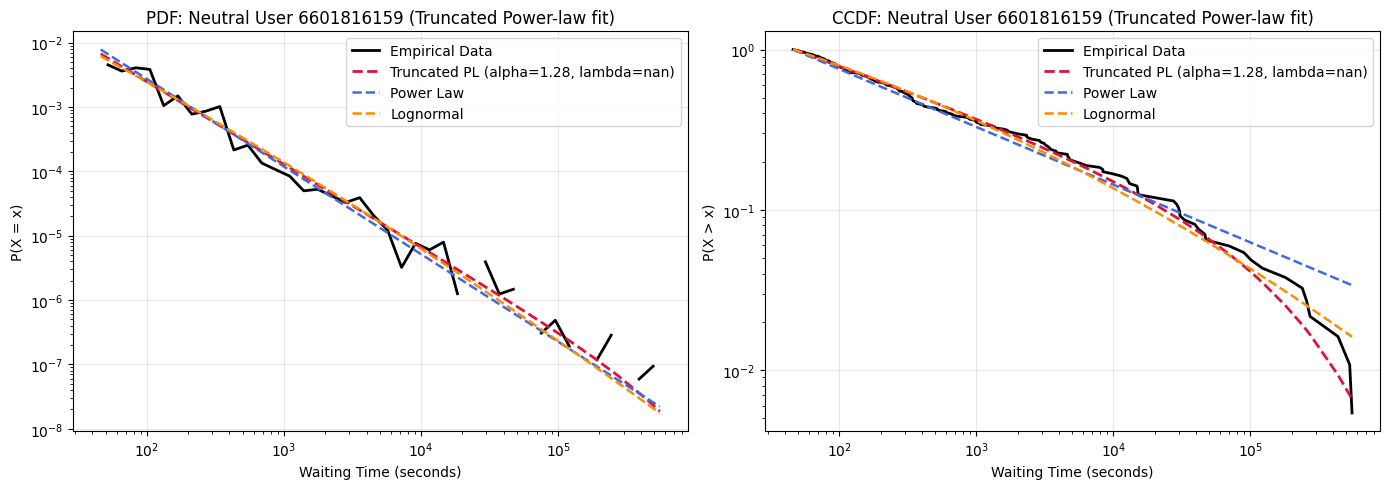



Analyzing waiting times for Neutral User 5689570195...
POWER LAW FIT RESULTS: Neutral User 5689570195
alpha: 1.6879
xmin: 17284.0000
sigma: 0.1088
Data points above xmin: 40 / 223 (17.94%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -1.1255, p = 0.2124
  No significant difference

Power Law vs Lognormal:
  R = -0.5134, p = 0.6077
  No significant difference

Power Law vs Exponential:
  R = 3.2514, p = 0.0011
  Power law is significantly better

KS distance (power law): 0.0639
KS p-value (tail): 0.993232


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


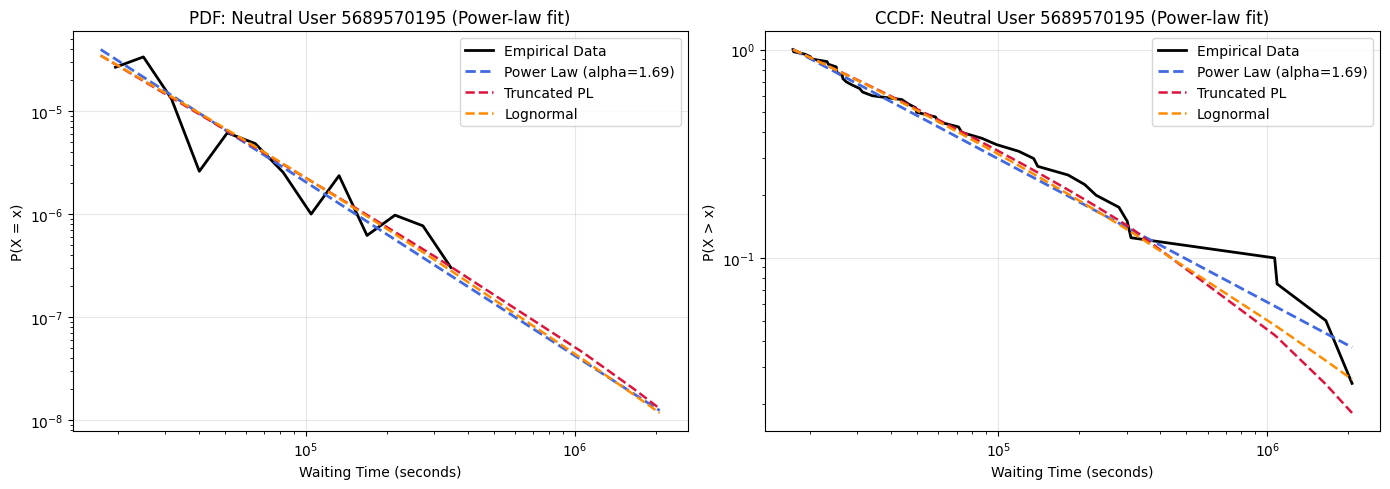

TRUNCATED POWER LAW FIT RESULTS: Neutral User 5689570195
alpha: 1.5485
lambda: nan
xmin: 17284.0000
sigma: nan
Data points above xmin: 40 / 223 (17.94%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.1255, p = 0.2124
  No significant difference

Truncated PL vs Lognormal:
  R = 1.6202, p = 0.1052
  No significant difference

Truncated PL vs Exponential:
  R = 3.5834, p = 0.0003
  Truncated power law is significantly better

KS distance (truncated power law): 0.0950
KS p-value (tail): 0.829716


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


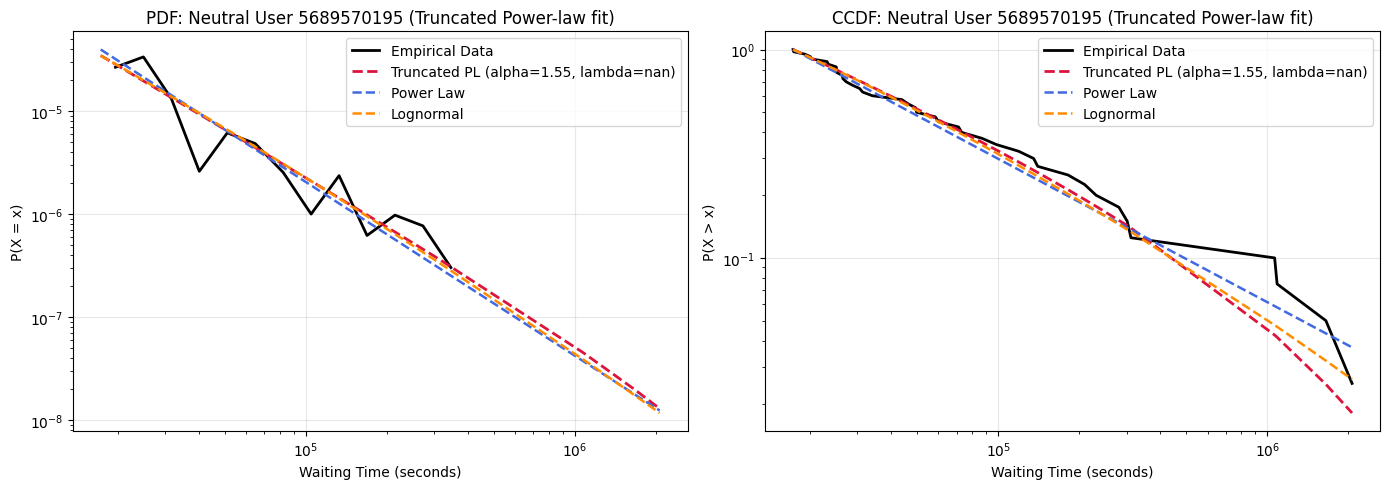



Analyzing waiting times for Neutral User 1110241832...
POWER LAW FIT RESULTS: Neutral User 1110241832
alpha: 1.4284
xmin: 2395.0000
sigma: 0.0449
Data points above xmin: 91 / 221 (41.18%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -1.7441, p = 0.0359
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.4325, p = 0.1520
  No significant difference

Power Law vs Exponential:
  R = 3.6368, p = 0.0003
  Power law is significantly better

KS distance (power law): 0.0847
KS p-value (tail): 0.353037


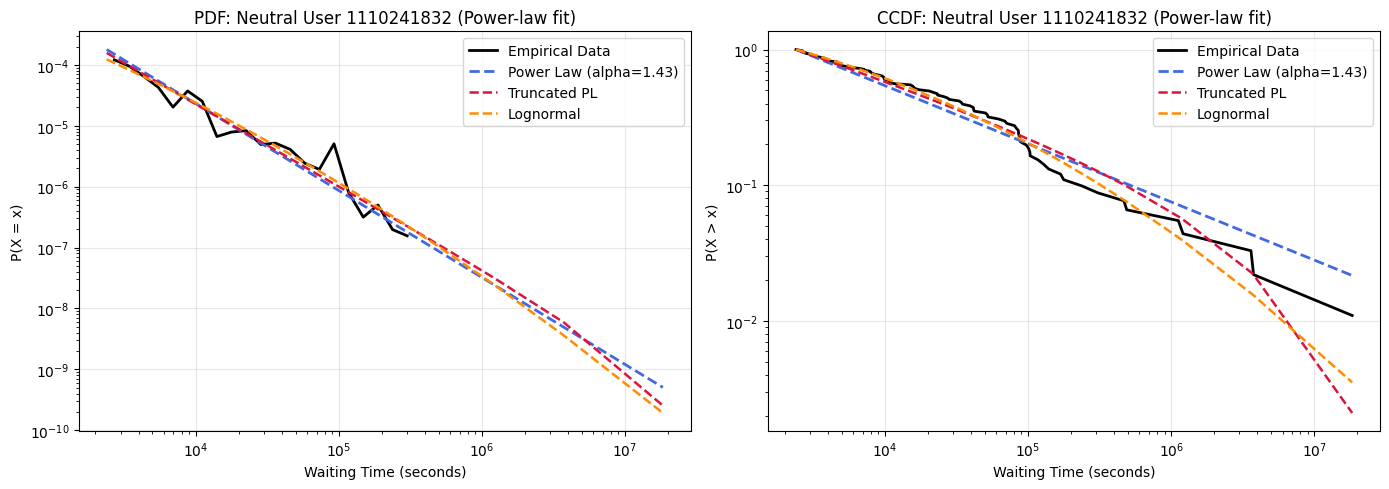

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Neutral User 1110241832
alpha: 1.3524
lambda: nan
xmin: 2395.0000
sigma: nan
Data points above xmin: 91 / 221 (41.18%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.7441, p = 0.0359
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = -0.7461, p = 0.4556
  No significant difference

Truncated PL vs Exponential:
  R = 3.7702, p = 0.0002
  Truncated power law is significantly better

KS distance (truncated power law): 0.0685
KS p-value (tail): 0.760987


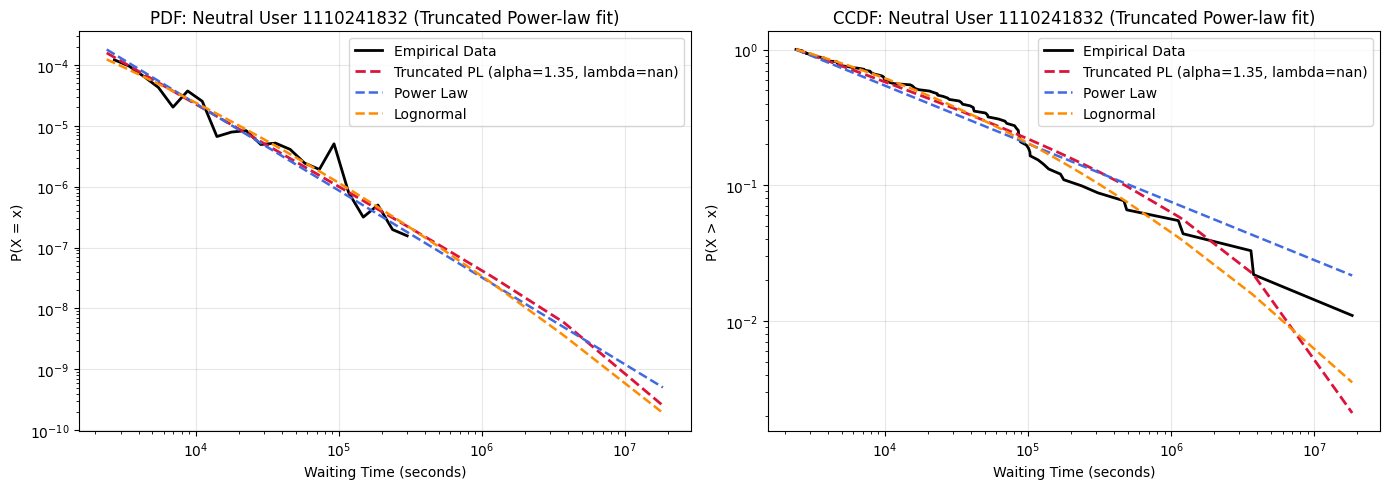



Analyzing waiting times for Neutral User 2047003776...
POWER LAW FIT RESULTS: Neutral User 2047003776
alpha: 1.6681
xmin: 21406.0000
sigma: 0.0926
Data points above xmin: 52 / 182 (28.57%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -0.7834, p = 0.5076
  No significant difference

Power Law vs Lognormal:
  R = -0.3230, p = 0.7467
  No significant difference

Power Law vs Exponential:
  R = 2.7867, p = 0.0053
  Power law is significantly better

KS distance (power law): 0.0579
KS p-value (tail): 0.984287


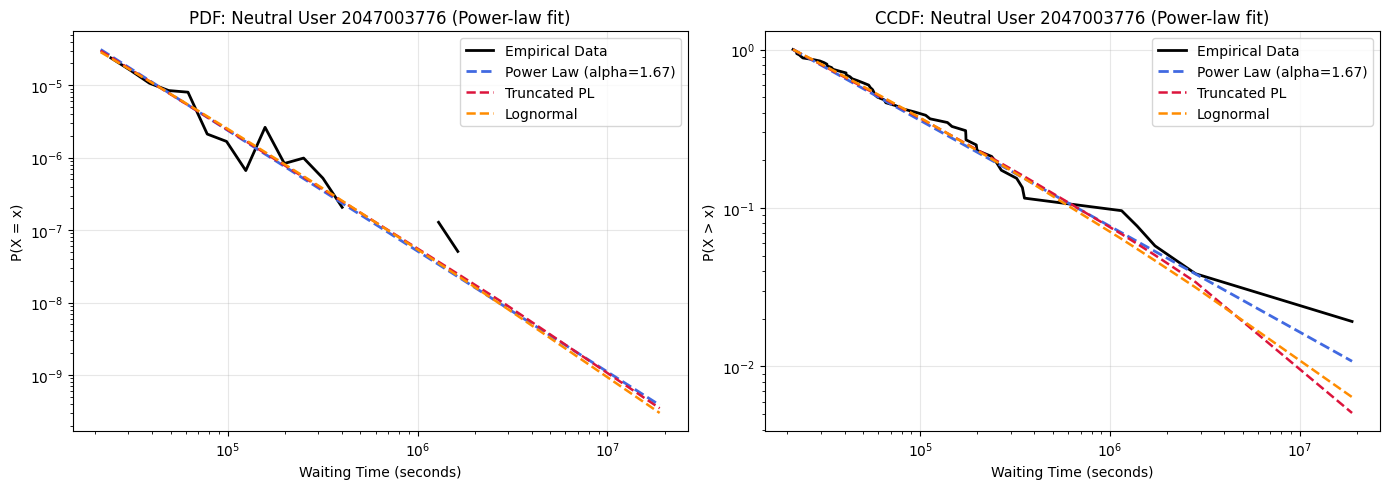

TRUNCATED POWER LAW FIT RESULTS: Neutral User 2047003776
alpha: 1.6325
lambda: nan
xmin: 21406.0000
sigma: nan
Data points above xmin: 52 / 182 (28.57%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 0.7834, p = 0.5076
  No significant difference

Truncated PL vs Lognormal:
  R = 0.2826, p = 0.7774
  No significant difference

Truncated PL vs Exponential:
  R = 2.8165, p = 0.0049
  Truncated power law is significantly better

KS distance (truncated power law): 0.0617
KS p-value (tail): 0.981831


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


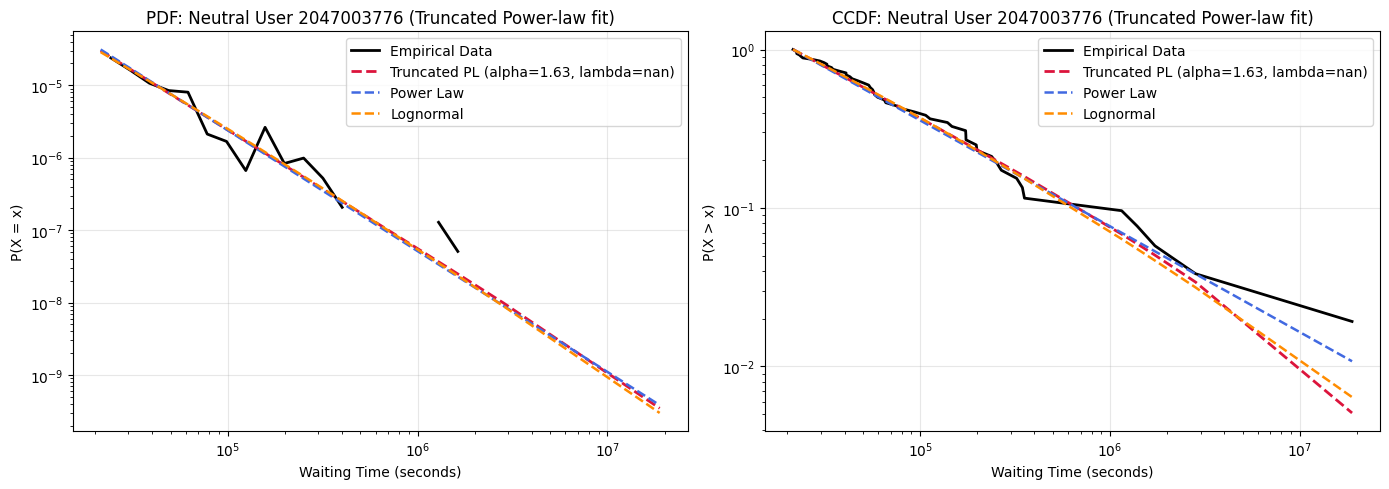



Analyzing waiting times for Neutral User 791270353...
POWER LAW FIT RESULTS: Neutral User 791270353
alpha: 2.0894
xmin: 40490.0000
sigma: 0.2224
Data points above xmin: 24 / 146 (16.44%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -0.4139, p = 0.7105
  No significant difference

Power Law vs Lognormal:
  R = -0.0864, p = 0.9311
  No significant difference

Power Law vs Exponential:
  R = 1.7864, p = 0.0740
  No significant difference

KS distance (power law): 0.0938
KS p-value (tail): 0.97114


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


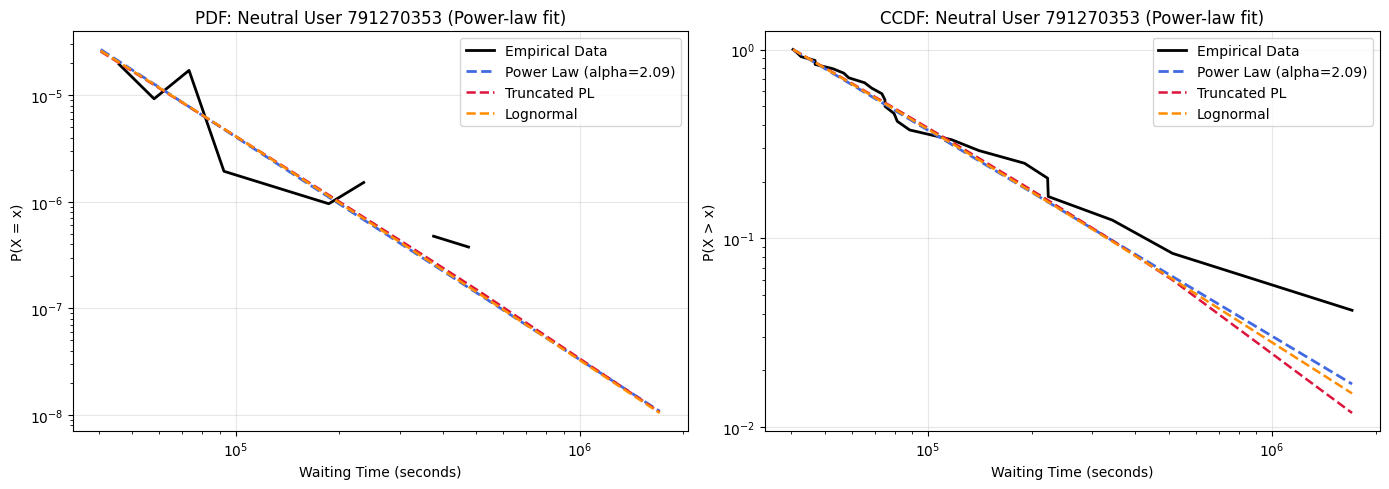

TRUNCATED POWER LAW FIT RESULTS: Neutral User 791270353
alpha: 2.0178
lambda: nan
xmin: 40490.0000
sigma: nan
Data points above xmin: 24 / 146 (16.44%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 0.4139, p = 0.7105
  No significant difference

Truncated PL vs Lognormal:
  R = 0.6443, p = 0.5194
  No significant difference

Truncated PL vs Exponential:
  R = 1.8335, p = 0.0667
  No significant difference

KS distance (truncated power law): 0.1051
KS p-value (tail): 0.928548


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


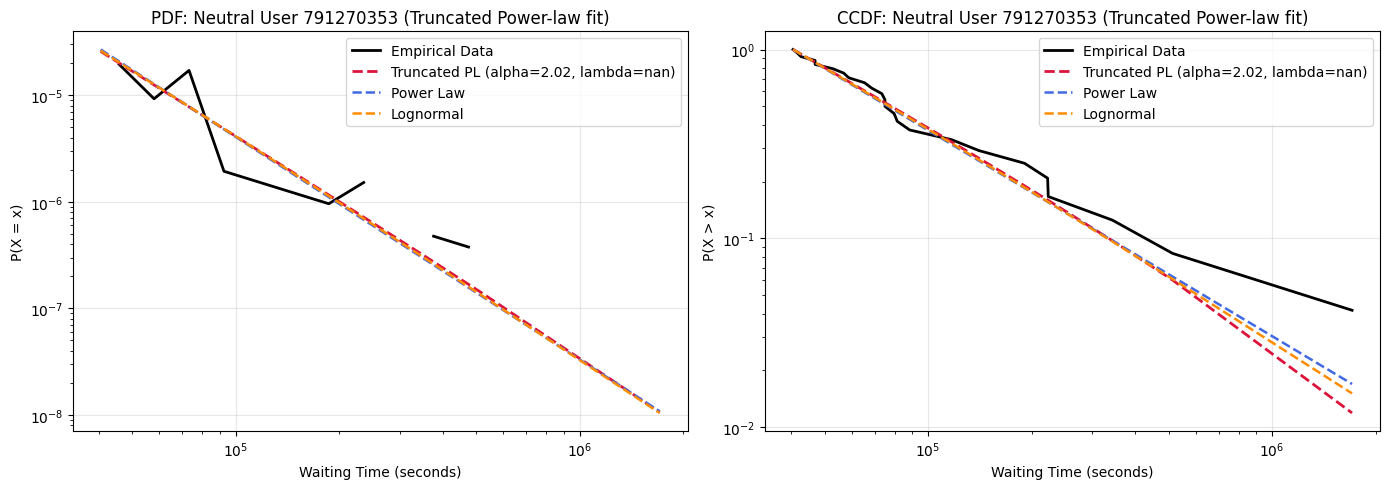



Analyzing waiting times for Neutral User 57072401...
POWER LAW FIT RESULTS: Neutral User 57072401
alpha: 1.3184
xmin: 10.0000
sigma: 0.0266
Data points above xmin: 143 / 167 (85.63%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -2.4671, p = 0.0040
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.1163, p = 0.2643
  No significant difference

Power Law vs Exponential:
  R = 8.1007, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0701
KS p-value (tail): 0.345216


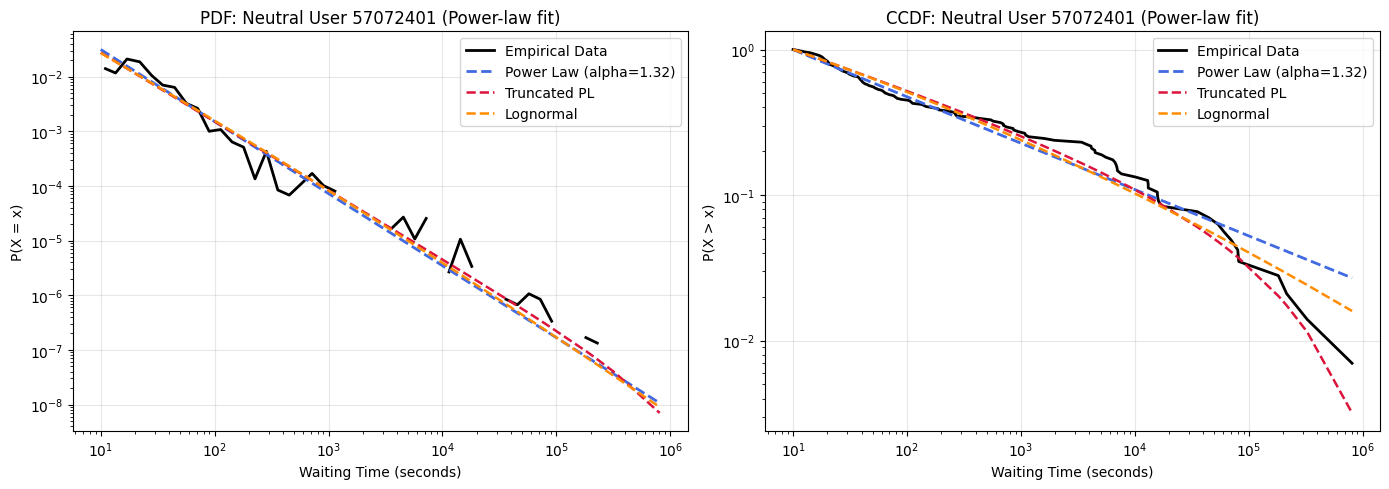

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Neutral User 57072401
alpha: 1.2606
lambda: nan
xmin: 10.0000
sigma: nan
Data points above xmin: 143 / 167 (85.63%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.4671, p = 0.0040
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 2.9866, p = 0.0028
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 8.3692, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0970
KS p-value (tail): 0.127143


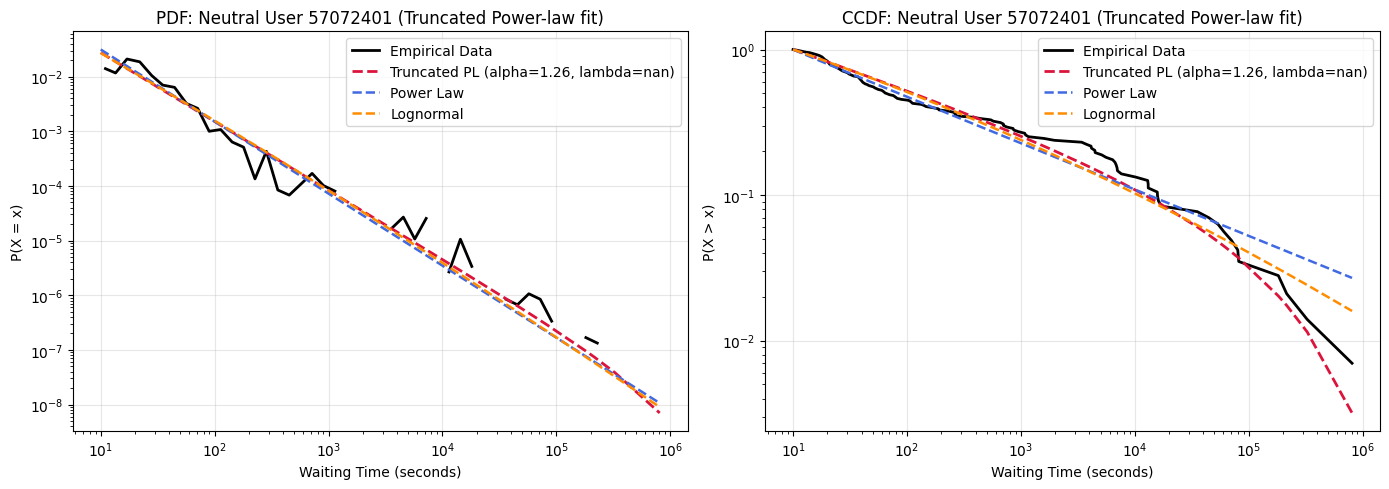



Analyzing waiting times for Neutral User 1131058651...
POWER LAW FIT RESULTS: Neutral User 1131058651
alpha: 1.3035
xmin: 19.0000
sigma: 0.0300
Data points above xmin: 102 / 108 (94.44%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -2.2016, p = 0.0106
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.2798, p = 0.2006
  No significant difference

Power Law vs Exponential:
  R = 6.2761, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0740
KS p-value (tail): 0.44665


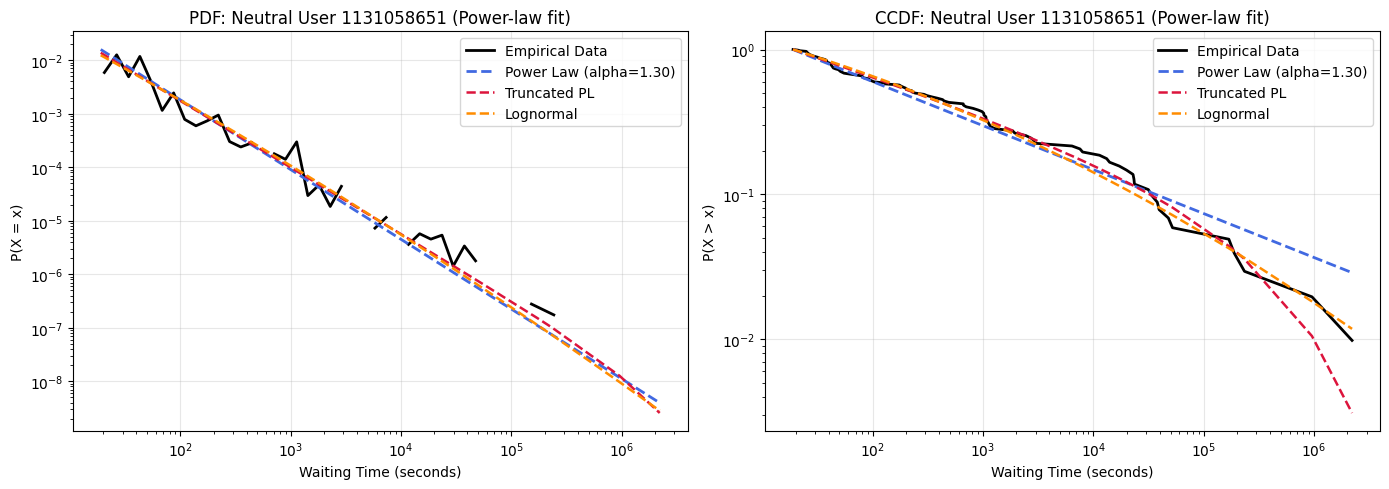

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Neutral User 1131058651
alpha: 1.2444
lambda: nan
xmin: 19.0000
sigma: nan
Data points above xmin: 102 / 108 (94.44%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.2016, p = 0.0106
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 1.4858, p = 0.1373
  No significant difference

Truncated PL vs Exponential:
  R = 6.4772, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0831
KS p-value (tail): 0.456831


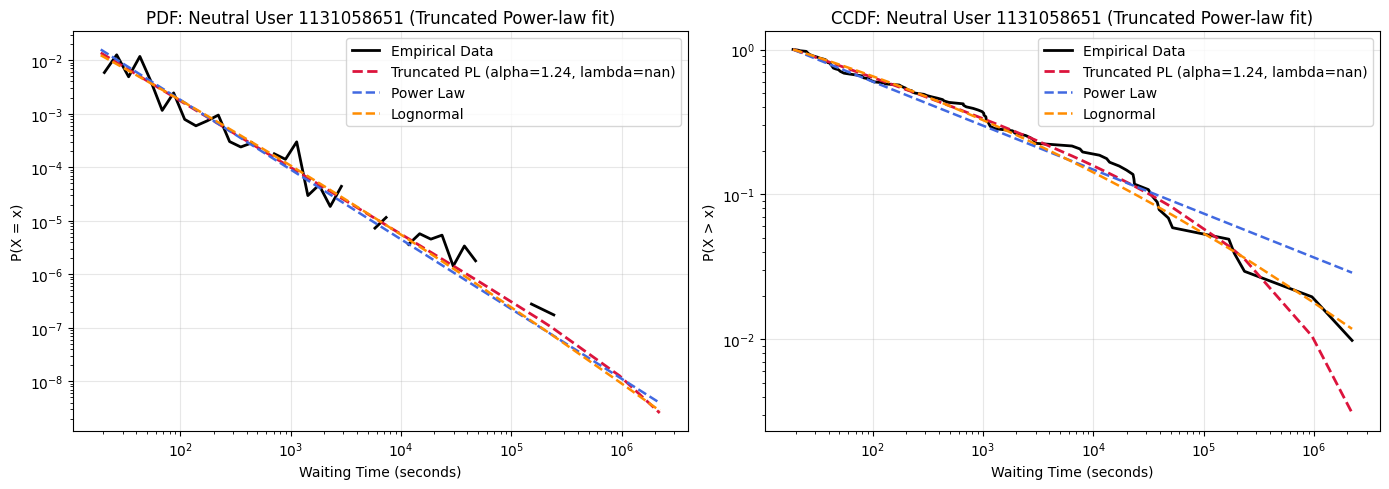



Analyzing waiting times for Neutral User 1551829597...
POWER LAW FIT RESULTS: Neutral User 1551829597
alpha: 2.5386
xmin: 355001.0000
sigma: 0.4267
Data points above xmin: 13 / 102 (12.75%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = 0.0002, p = 0.9996
  No significant difference

Power Law vs Lognormal:
  R = 1.9494, p = 0.0512
  No significant difference

Power Law vs Exponential:
  R = 3.5904, p = 0.0003
  Power law is significantly better

KS distance (power law): 0.2004
KS p-value (tail): 0.604416


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:2792: RuntimeWarning: invalid value encountered in divide
  return likelihoods/norm
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


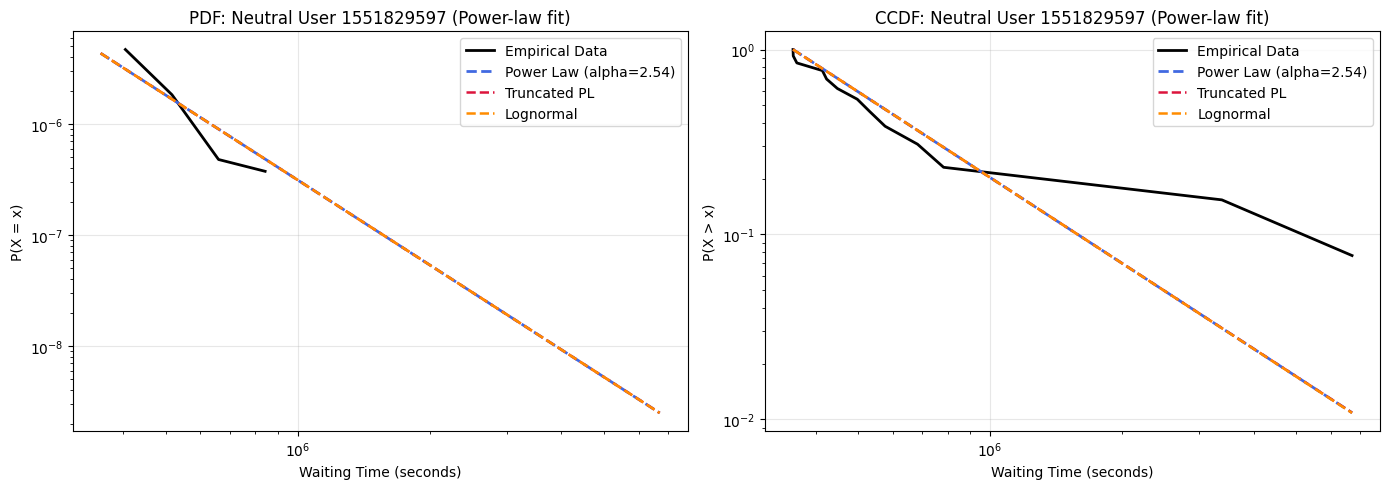

TRUNCATED POWER LAW FIT RESULTS: Neutral User 1551829597
alpha: 2.5384
lambda: nan
xmin: 355001.0000
sigma: nan
Data points above xmin: 13 / 102 (12.75%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = -0.0002, p = 0.9996
  No significant difference

Truncated PL vs Lognormal:
  R = 2.0698, p = 0.0385
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 3.5907, p = 0.0003
  Truncated power law is significantly better

KS distance (truncated power law): 0.2004
KS p-value (tail): 0.604392


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:2792: RuntimeWarning: invalid value encountered in divide
  return likelihoods/norm
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


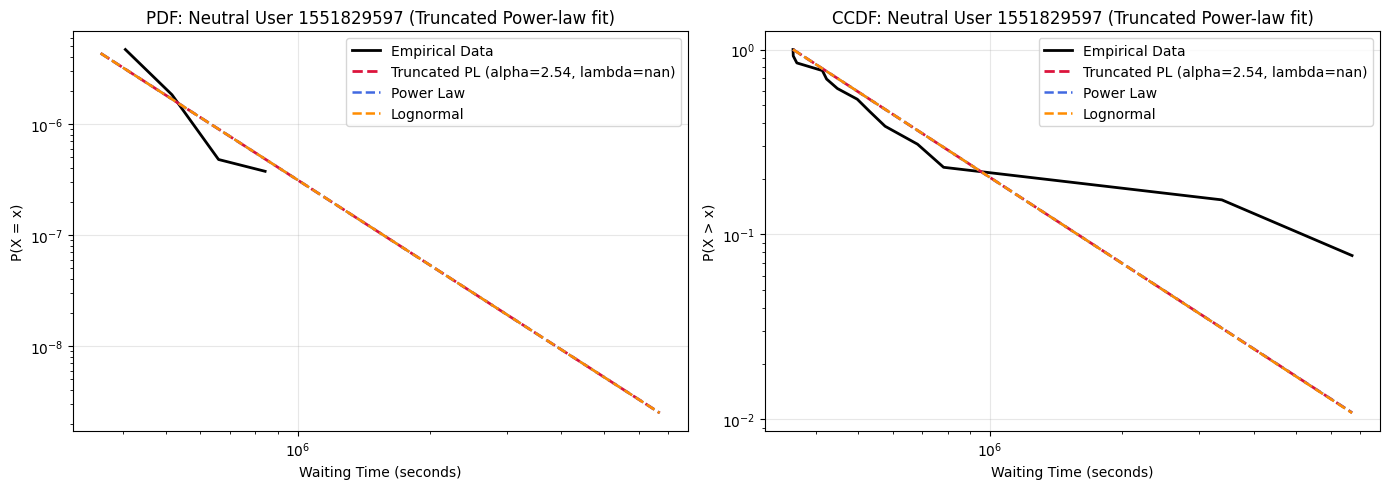



Analyzing waiting times for Neutral User 5992929865...
POWER LAW FIT RESULTS: Neutral User 5992929865
alpha: 1.1786
xmin: 3.0000
sigma: 0.0179
Data points above xmin: 100 / 100 (100.00%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -3.1490, p = 0.0000
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.7985, p = 0.0721
  No significant difference

Power Law vs Exponential:
  R = 9.4573, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.1066
KS p-value (tail): 0.121745


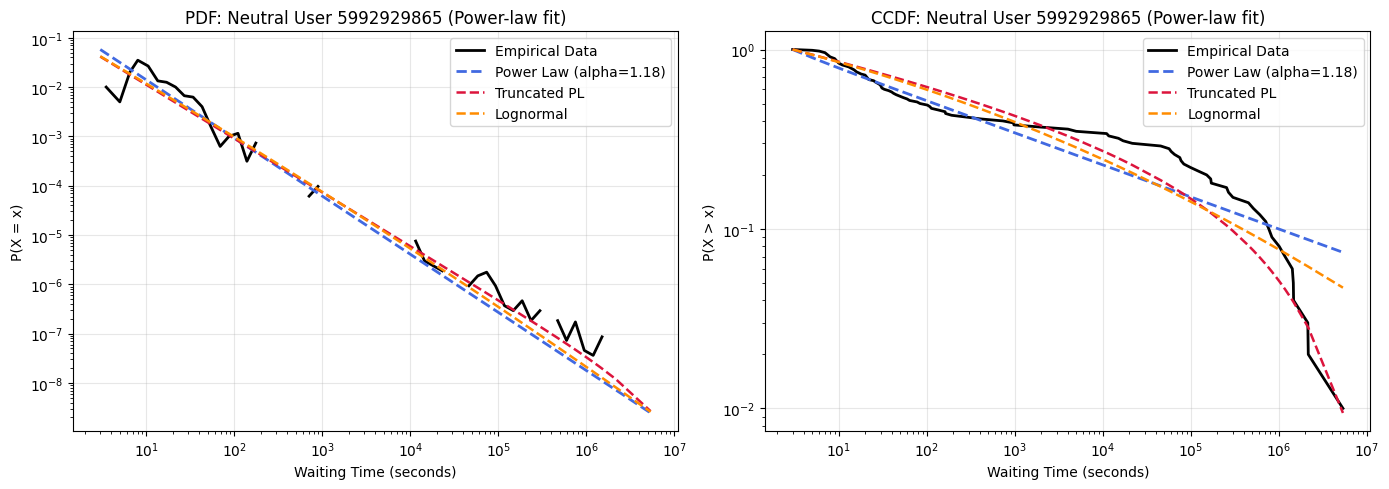

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Neutral User 5992929865
alpha: 1.0918
lambda: nan
xmin: 3.0000
sigma: nan
Data points above xmin: 100 / 100 (100.00%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 3.1490, p = 0.0000
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 3.8818, p = 0.0001
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 10.4705, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.1549
KS p-value (tail): 0.0146517


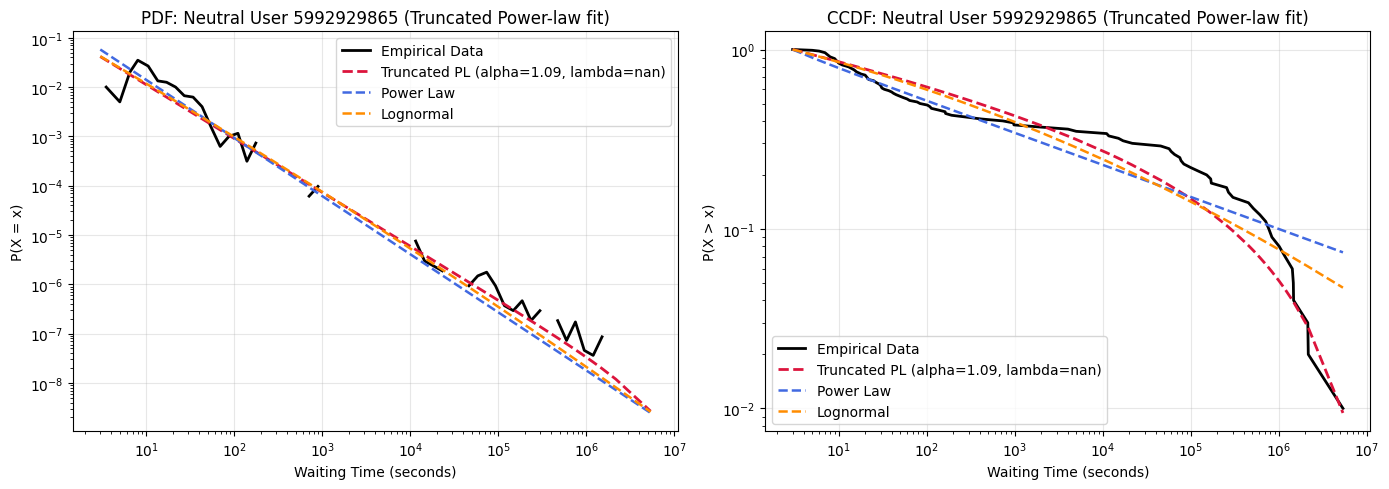

In [ ]:
for user in neutral_active_users:
    user_messages = neutral_messages[neutral_messages['sender_id'] == user] # Gather messages sent by the user.
    user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
    waiting_time = user_dates.diff().dropna()
    # Fit the waiting time to a power-law distribution and plot it with comparisons to other distributions and KS test on the tail
    print(f"\n\nAnalyzing waiting times for Neutral User {user}...")
    fit_power_law_report(waiting_time.dt.total_seconds(), f"Neutral User {user}")
    fit_truncated_power_law_report(waiting_time.dt.total_seconds(), f"Neutral User {user}")


### Waiting times for right-wing users



Analyzing waiting times for Right-Wing User 7094531229...
POWER LAW FIT RESULTS: Right-Wing User 7094531229
alpha: 1.3662
xmin: 37.0000
sigma: 0.0195
Data points above xmin: 354 / 423 (83.69%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -3.3290, p = 0.0002
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.2055, p = 0.2280
  No significant difference

Power Law vs Exponential:
  R = 11.6443, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0611
KS p-value (tail): 0.136352


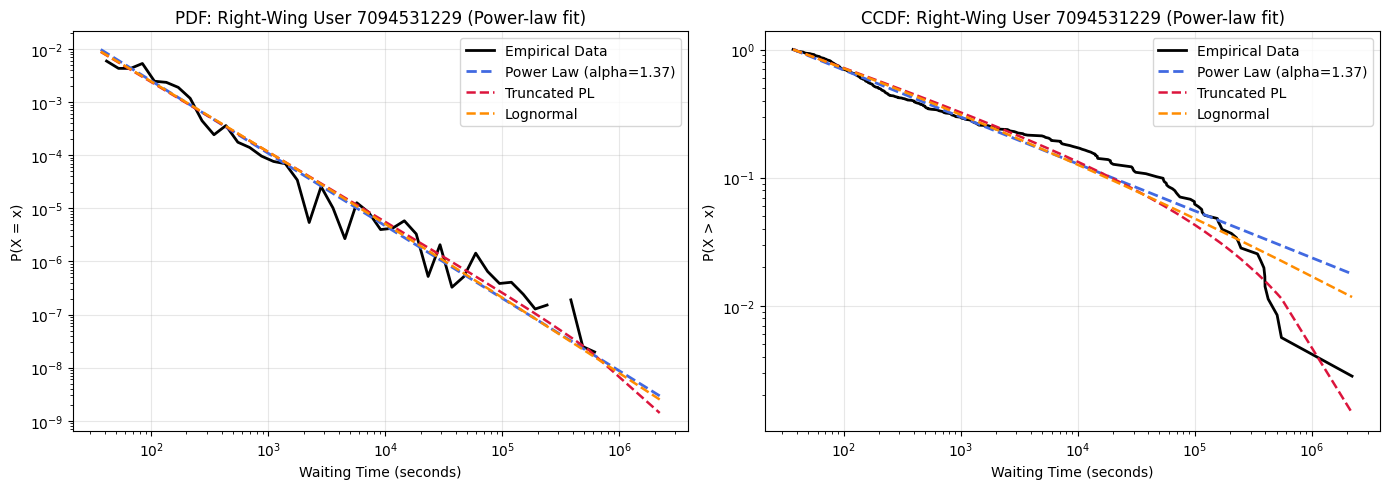

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Right-Wing User 7094531229
alpha: 1.3164
lambda: nan
xmin: 37.0000
sigma: nan
Data points above xmin: 354 / 423 (83.69%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 3.3290, p = 0.0002
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 3.8768, p = 0.0001
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 11.9315, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0923
KS p-value (tail): 0.00446305


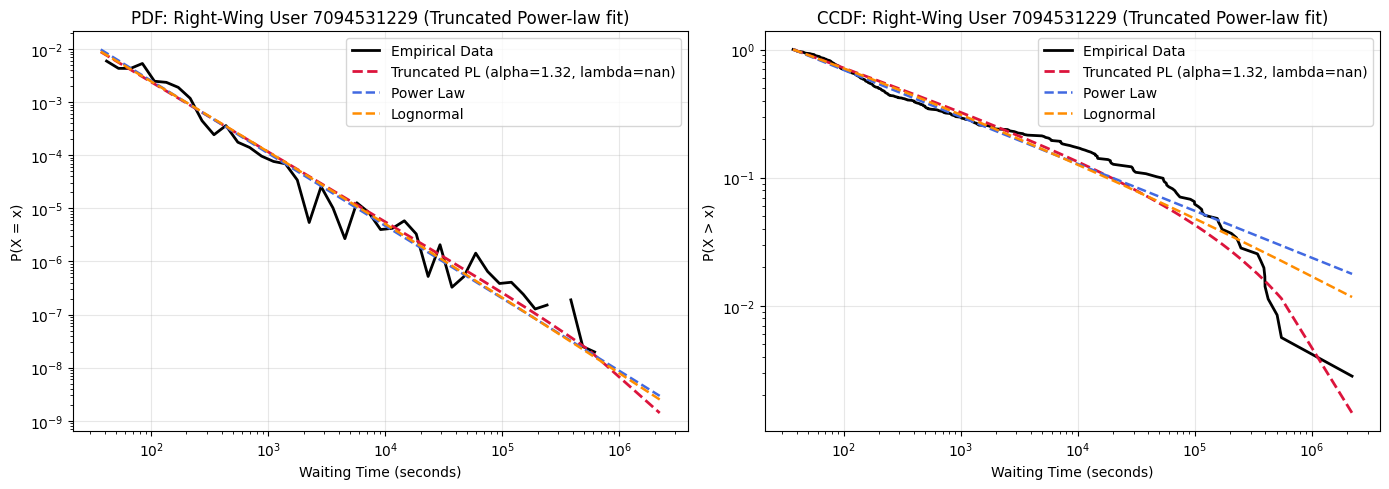



Analyzing waiting times for Right-Wing User 1505404600...
POWER LAW FIT RESULTS: Right-Wing User 1505404600
alpha: 1.6882
xmin: 1359.0000
sigma: 0.0817
Data points above xmin: 71 / 386 (18.39%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -1.4046, p = 0.0930
  No significant difference

Power Law vs Lognormal:
  R = -0.6969, p = 0.4859
  No significant difference

Power Law vs Exponential:
  R = 3.5649, p = 0.0004
  Power law is significantly better

KS distance (power law): 0.0557
KS p-value (tail): 0.971309


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


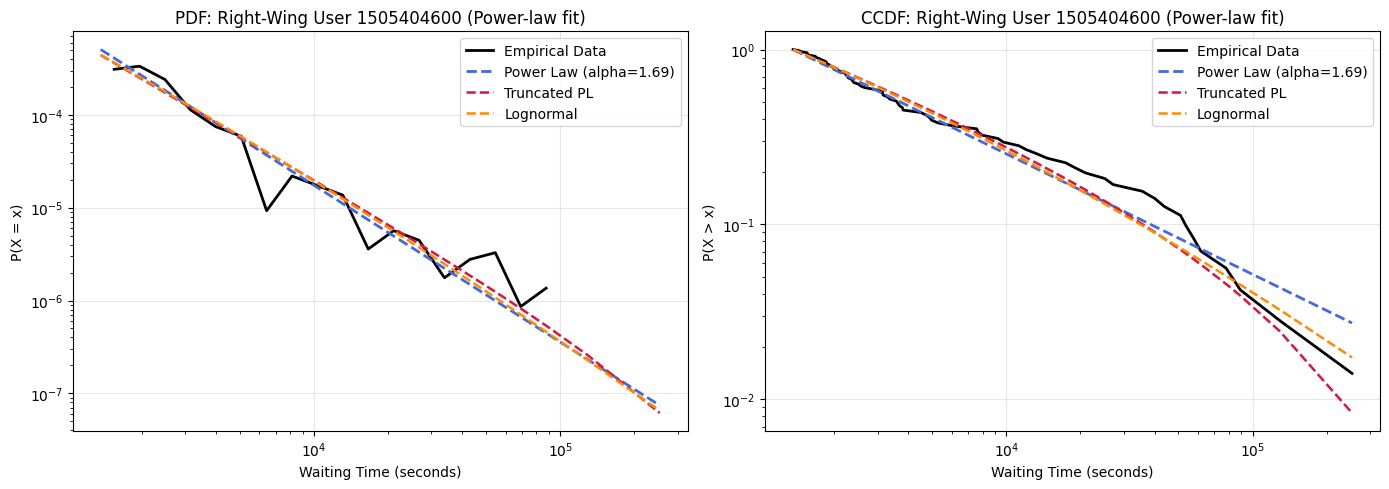

TRUNCATED POWER LAW FIT RESULTS: Right-Wing User 1505404600
alpha: 1.5460
lambda: nan
xmin: 1359.0000
sigma: nan
Data points above xmin: 71 / 386 (18.39%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.4046, p = 0.0930
  No significant difference

Truncated PL vs Lognormal:
  R = 1.9746, p = 0.0483
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 3.9208, p = 0.0001
  Truncated power law is significantly better

KS distance (truncated power law): 0.0922
KS p-value (tail): 0.551702


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


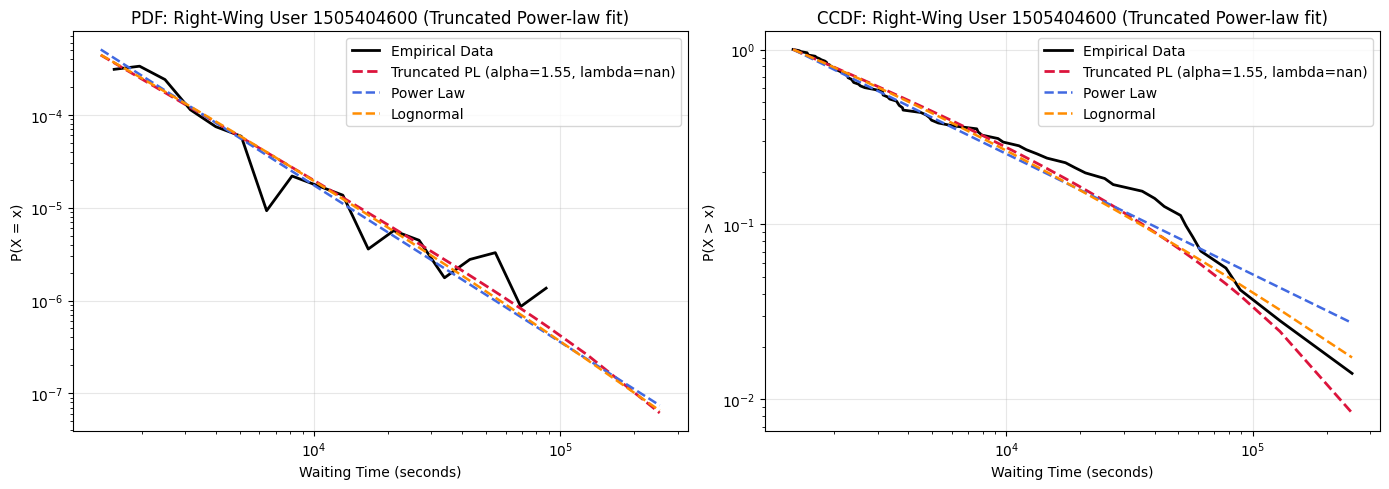



Analyzing waiting times for Right-Wing User 6973904485...
POWER LAW FIT RESULTS: Right-Wing User 6973904485
alpha: 1.4882
xmin: 666.0000
sigma: 0.0401
Data points above xmin: 148 / 320 (46.25%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -2.1533, p = 0.0012
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.9453, p = 0.0517
  No significant difference

Power Law vs Exponential:
  R = 3.4776, p = 0.0005
  Power law is significantly better

KS distance (power law): 0.0861
KS p-value (tail): 0.145851


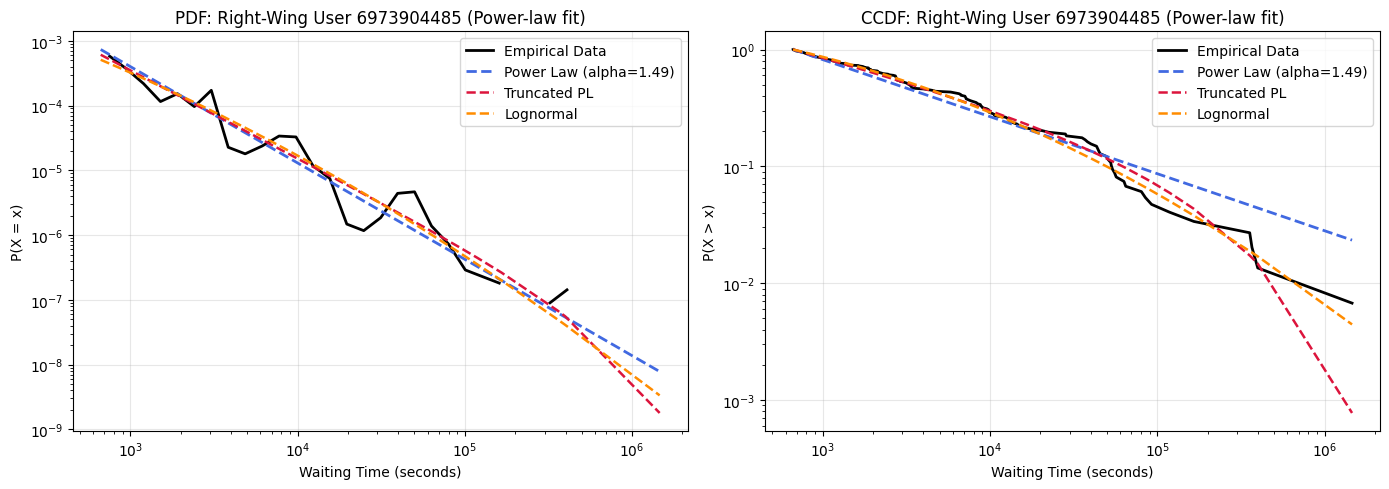

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Right-Wing User 6973904485
alpha: 1.3568
lambda: nan
xmin: 666.0000
sigma: nan
Data points above xmin: 148 / 320 (46.25%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.1533, p = 0.0012
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 0.0605, p = 0.9518
  No significant difference

Truncated PL vs Exponential:
  R = 3.7737, p = 0.0002
  Truncated power law is significantly better

KS distance (truncated power law): 0.0431
KS p-value (tail): 0.836579


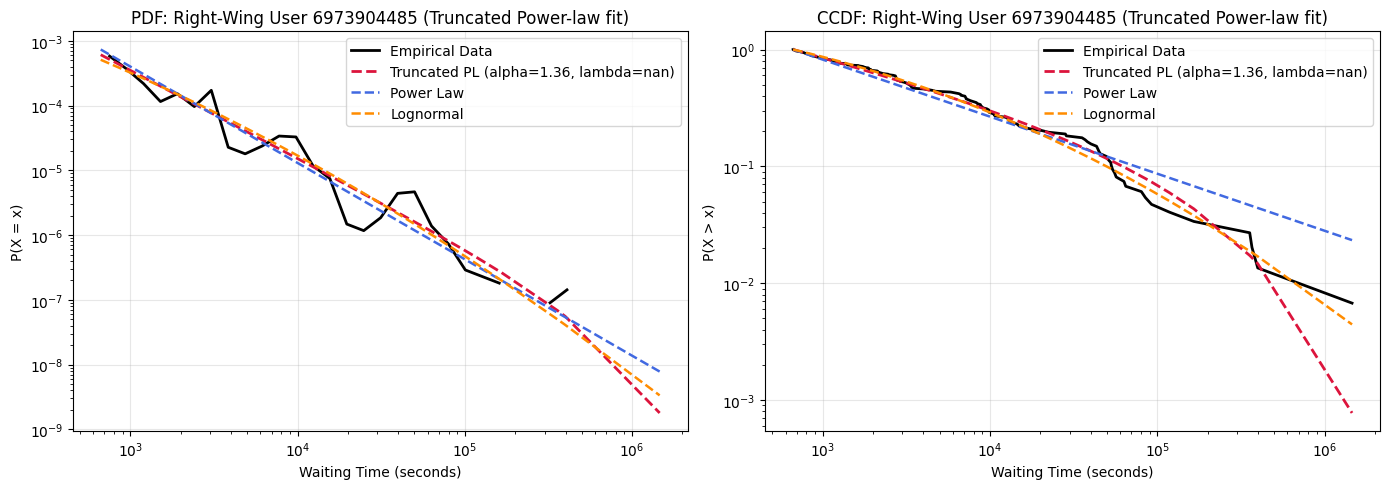



Analyzing waiting times for Right-Wing User 6221273187...
POWER LAW FIT RESULTS: Right-Wing User 6221273187
alpha: 1.5494
xmin: 238.0000
sigma: 0.0499
Data points above xmin: 121 / 267 (45.32%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -1.9279, p = 0.0372
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -0.8337, p = 0.4044
  No significant difference

Power Law vs Exponential:
  R = 6.0302, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0503
KS p-value (tail): 0.787966


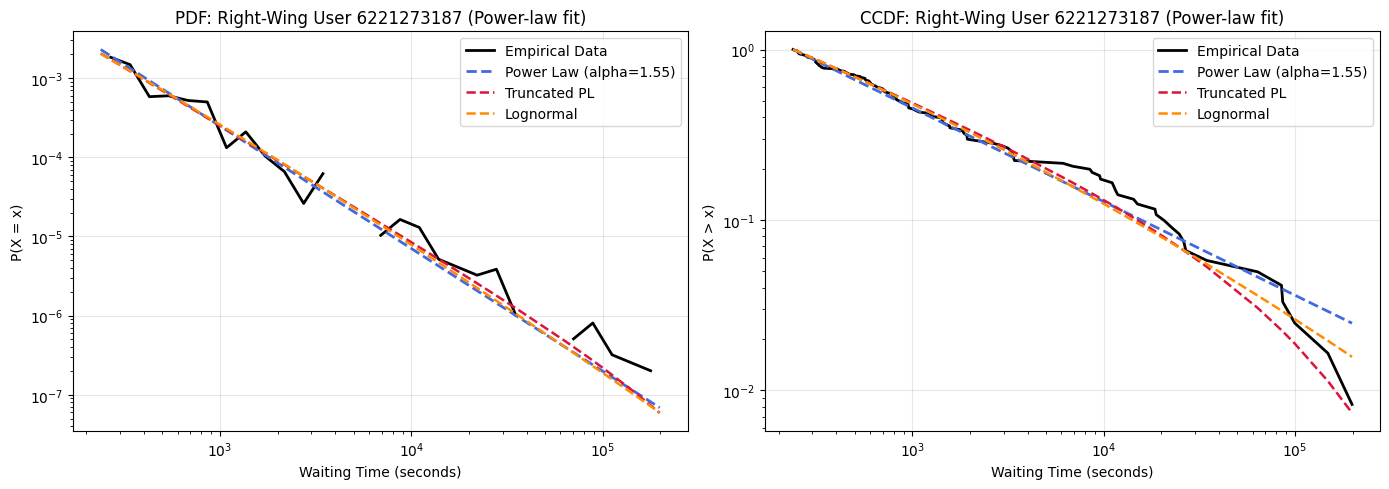

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Right-Wing User 6221273187
alpha: 1.4620
lambda: nan
xmin: 238.0000
sigma: nan
Data points above xmin: 121 / 267 (45.32%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.9279, p = 0.0372
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 2.4913, p = 0.0127
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 6.3295, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0668
KS p-value (tail): 0.628478


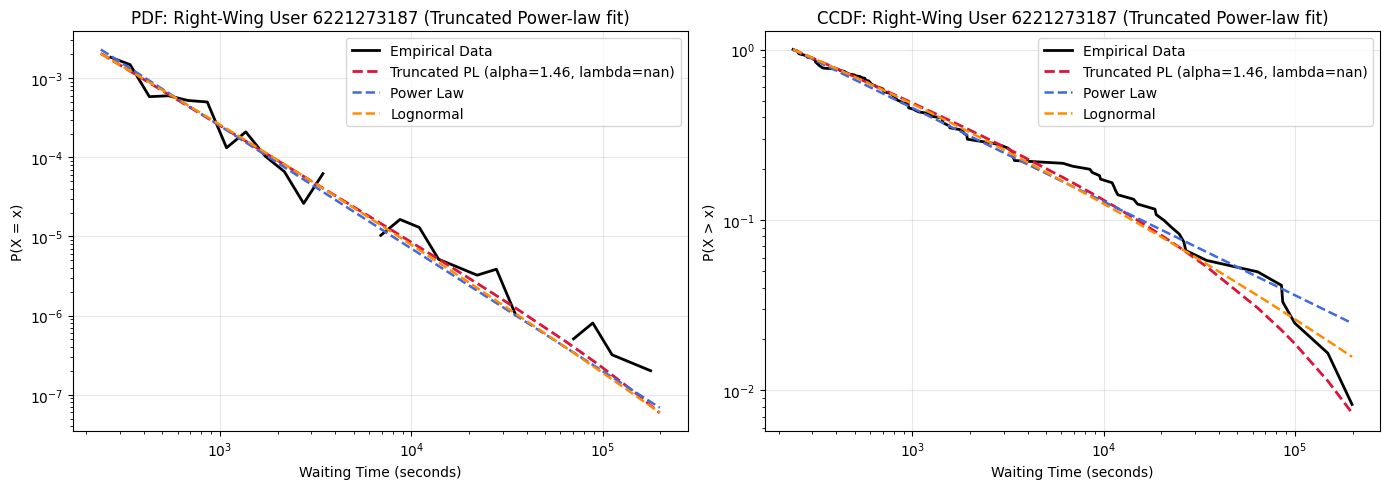



Analyzing waiting times for Right-Wing User 1151037126...
POWER LAW FIT RESULTS: Right-Wing User 1151037126
alpha: 1.5188
xmin: 749.0000
sigma: 0.0527
Data points above xmin: 97 / 213 (45.54%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -2.1324, p = 0.0095
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.2532, p = 0.2101
  No significant difference

Power Law vs Exponential:
  R = 4.8499, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0630
KS p-value (tail): 0.646724


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


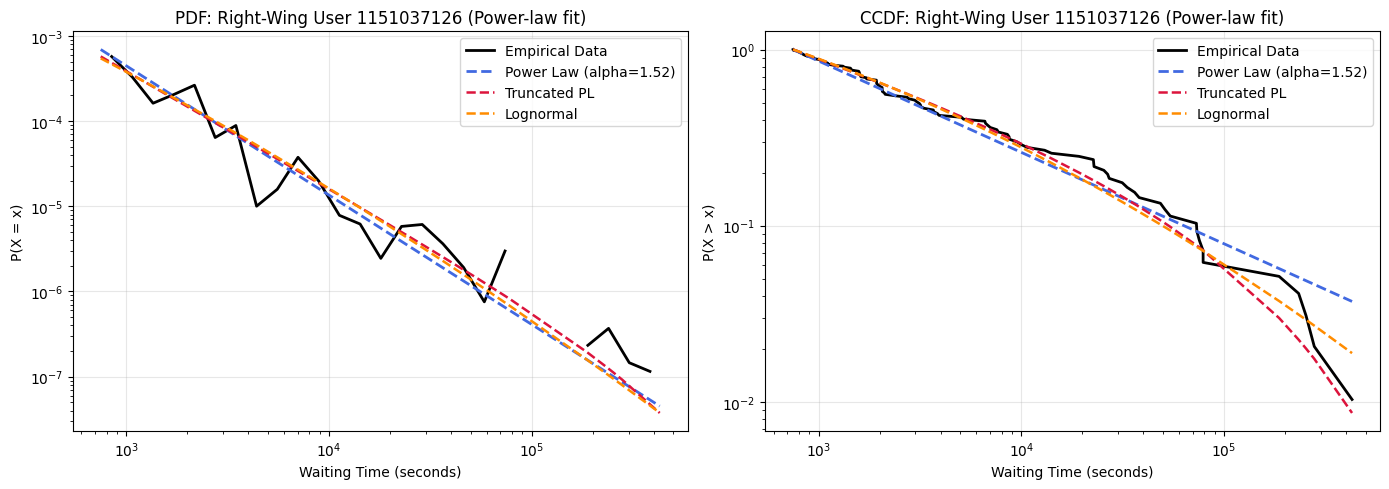

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Right-Wing User 1151037126
alpha: 1.3765
lambda: nan
xmin: 749.0000
sigma: nan
Data points above xmin: 97 / 213 (45.54%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.1324, p = 0.0095
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 2.4212, p = 0.0155
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 5.3959, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0822
KS p-value (tail): 0.502172


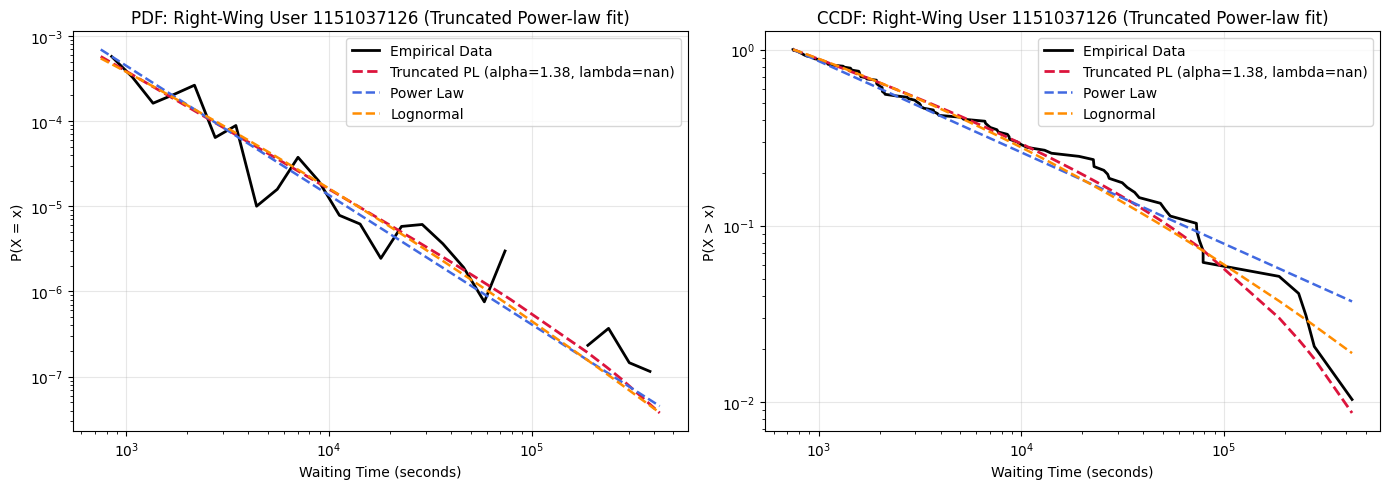



Analyzing waiting times for Right-Wing User 6938249017...
POWER LAW FIT RESULTS: Right-Wing User 6938249017
alpha: 2.2259
xmin: 44980.0000
sigma: 0.3276
Data points above xmin: 14 / 62 (22.58%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -0.5166, p = 0.5456
  No significant difference

Power Law vs Lognormal:
  R = -0.2507, p = 0.8020
  No significant difference

Power Law vs Exponential:
  R = 1.1364, p = 0.2558
  No significant difference

KS distance (power law): 0.1206
KS p-value (tail): 0.971803


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


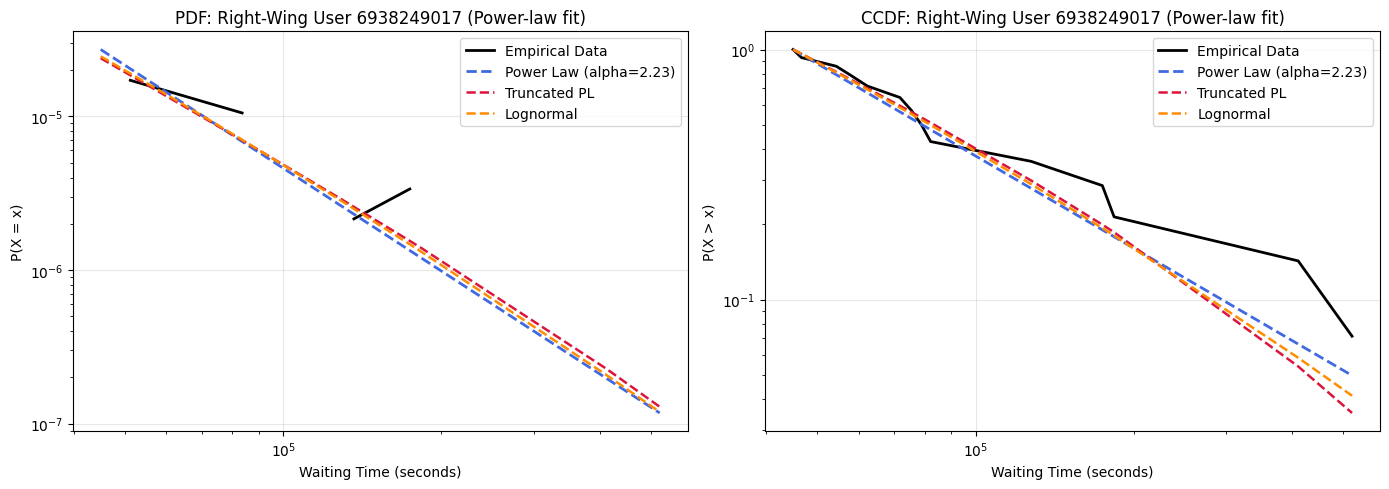

TRUNCATED POWER LAW FIT RESULTS: Right-Wing User 6938249017
alpha: 1.9162
lambda: nan
xmin: 44980.0000
sigma: nan
Data points above xmin: 14 / 62 (22.58%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 0.5166, p = 0.5456
  No significant difference

Truncated PL vs Lognormal:
  R = 0.8210, p = 0.4117
  No significant difference

Truncated PL vs Exponential:
  R = 1.4586, p = 0.1447
  No significant difference

KS distance (truncated power law): 0.1528
KS p-value (tail): 0.851803


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


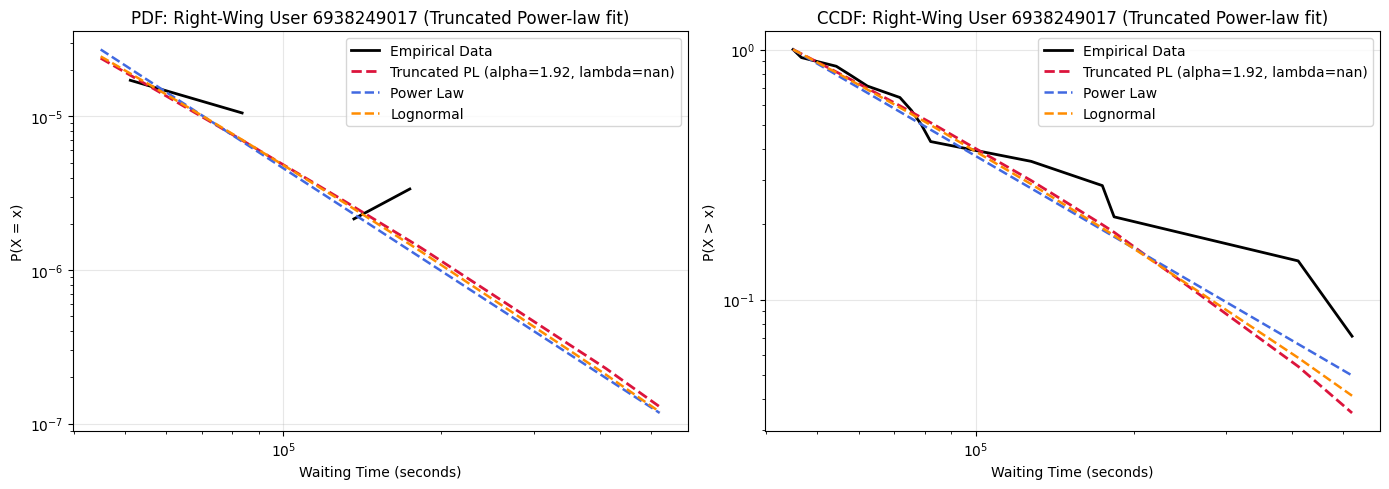



Analyzing waiting times for Right-Wing User 7567764882...
POWER LAW FIT RESULTS: Right-Wing User 7567764882
alpha: 1.4201
xmin: 35.0000
sigma: 0.0436
Data points above xmin: 93 / 124 (75.00%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -1.7252, p = 0.0929
  No significant difference

Power Law vs Lognormal:
  R = -0.5387, p = 0.5901
  No significant difference

Power Law vs Exponential:
  R = 7.5312, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0572
KS p-value (tail): 0.757075


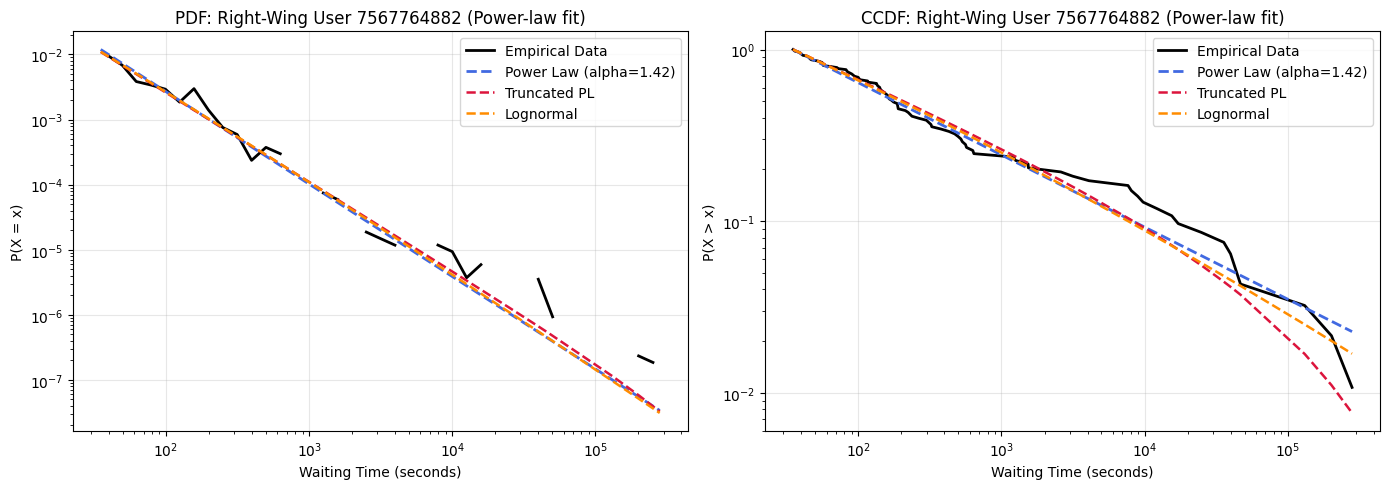

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Right-Wing User 7567764882
alpha: 1.3712
lambda: nan
xmin: 35.0000
sigma: nan
Data points above xmin: 93 / 124 (75.00%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.7252, p = 0.0929
  No significant difference

Truncated PL vs Lognormal:
  R = 2.0815, p = 0.0374
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 7.7163, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0788
KS p-value (tail): 0.583524


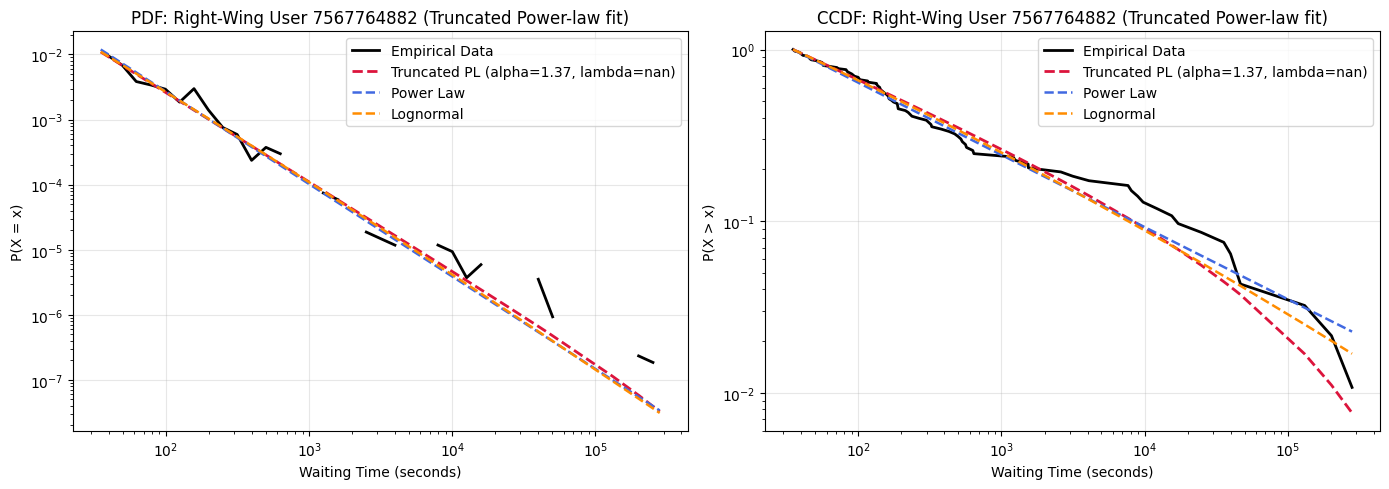

In [ ]:
for user in right_active_users:
    user_messages = right_messages[right_messages['sender_id'] == user] # Gather messages sent by the user.
    user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
    waiting_time = user_dates.diff().dropna()
    # Fit the waiting time to a power-law distribution and plot it with comparisons to other distributions and KS test on the tail
    print(f"\n\nAnalyzing waiting times for Right-Wing User {user}...")
    fit_power_law_report(waiting_time.dt.total_seconds(), f"Right-Wing User {user}")
    fit_truncated_power_law_report(waiting_time.dt.total_seconds(), f"Right-Wing User {user}")

### Waiting times for left-wing users



Analyzing waiting times for Left-Wing User 271855505...
POWER LAW FIT RESULTS: Left-Wing User 271855505
alpha: 1.9075
xmin: 36920.0000
sigma: 0.1162
Data points above xmin: 61 / 342 (17.84%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -1.6283, p = 0.0376
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.2394, p = 0.2152
  No significant difference

Power Law vs Exponential:
  R = 1.6008, p = 0.1094
  No significant difference

KS distance (power law): 0.0817
KS p-value (tail): 0.565943


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


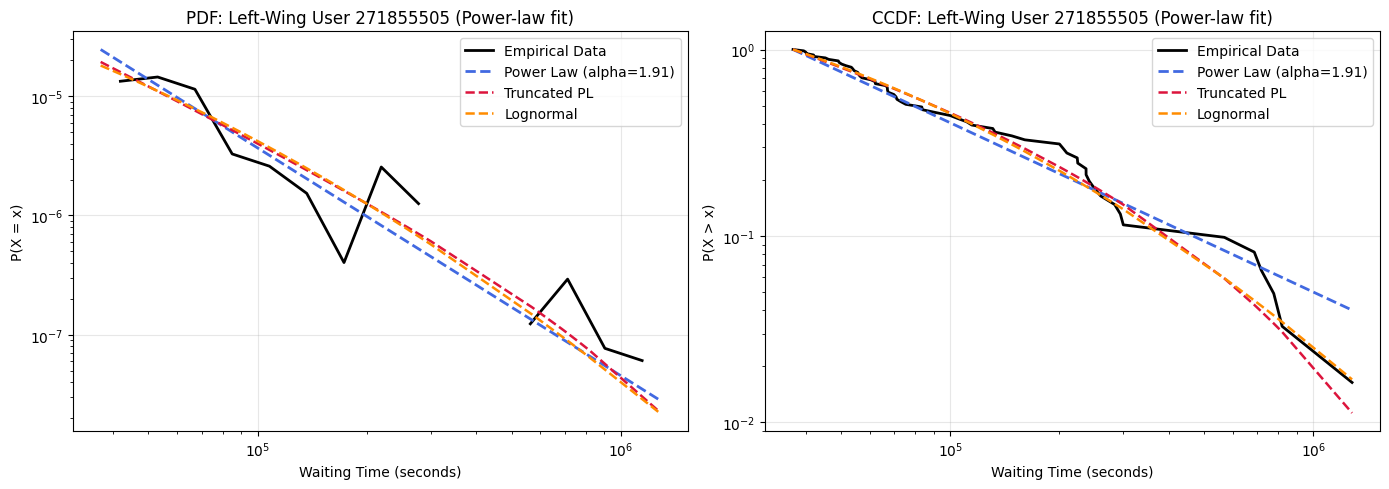

TRUNCATED POWER LAW FIT RESULTS: Left-Wing User 271855505
alpha: 1.5112
lambda: nan
xmin: 36920.0000
sigma: nan
Data points above xmin: 61 / 342 (17.84%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.6283, p = 0.0376
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 1.3420, p = 0.1796
  No significant difference

Truncated PL vs Exponential:
  R = 2.4148, p = 0.0157
  Truncated power law is significantly better

KS distance (truncated power law): 0.0881
KS p-value (tail): 0.698


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


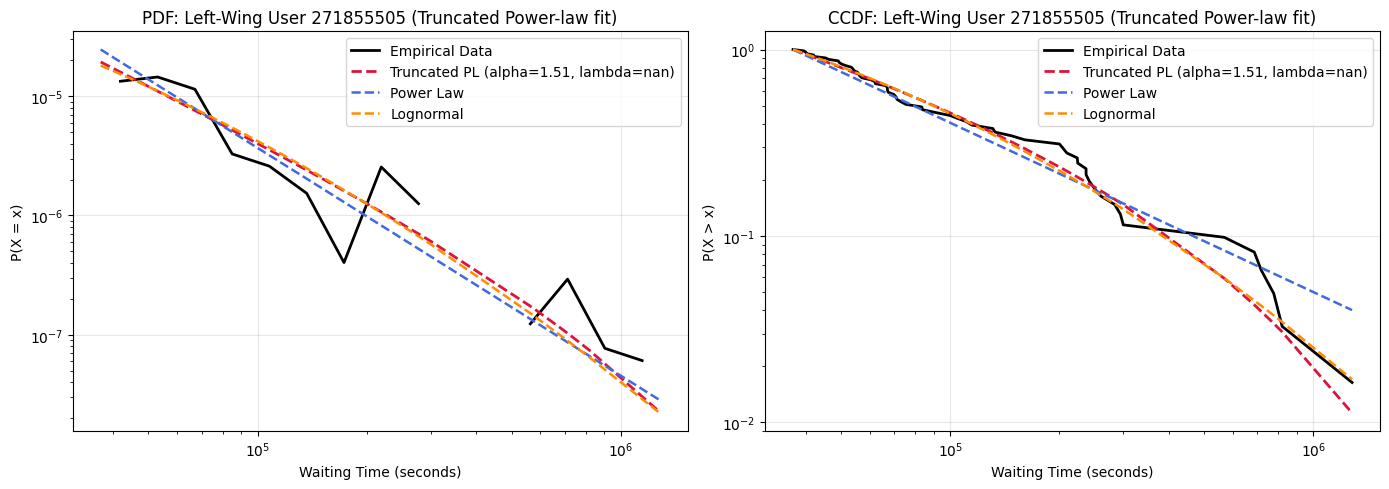



Analyzing waiting times for Left-Wing User 1357872899...
POWER LAW FIT RESULTS: Left-Wing User 1357872899
alpha: 1.3308
xmin: 147.0000
sigma: 0.0287
Data points above xmin: 133 / 156 (85.26%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -3.5549, p = 0.0000
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -2.3475, p = 0.0189
  lognormal is significantly better

Power Law vs Exponential:
  R = 7.1634, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0920
KS p-value (tail): 0.134084


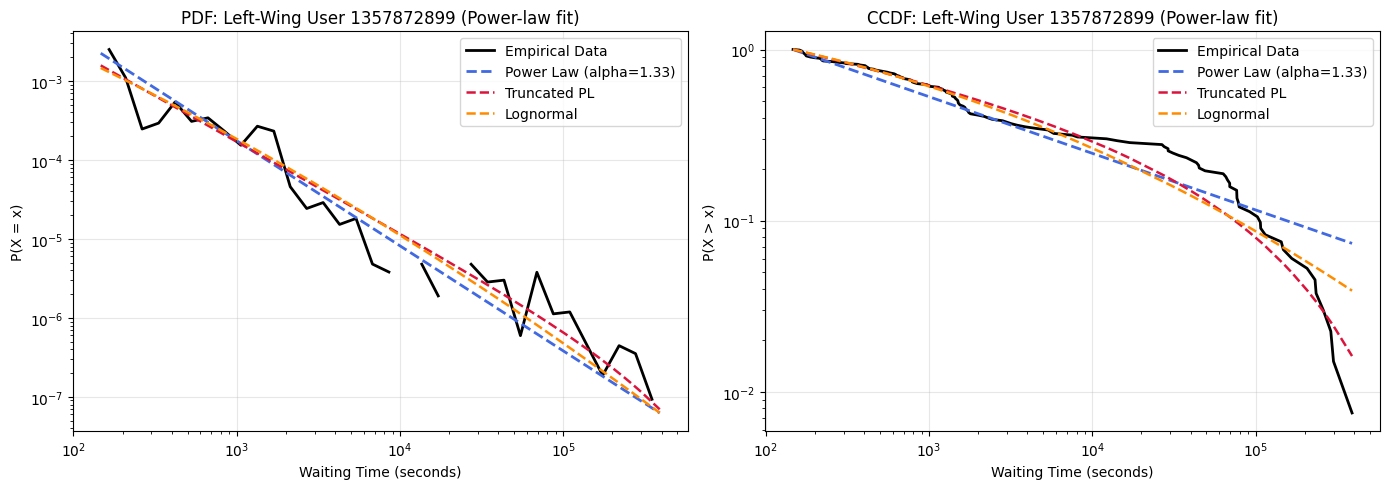

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Left-Wing User 1357872899
alpha: 1.1591
lambda: nan
xmin: 147.0000
sigma: nan
Data points above xmin: 133 / 156 (85.26%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 3.5549, p = 0.0000
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 3.7806, p = 0.0002
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 8.8682, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.1084
KS p-value (tail): 0.0812373


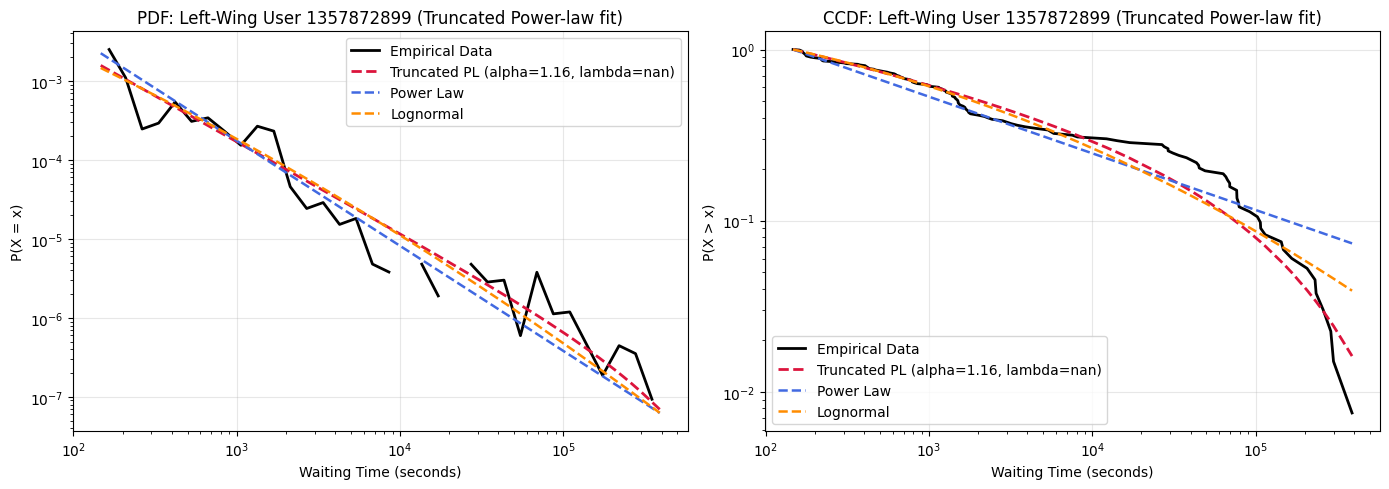

In [ ]:
for user in left_active_users:
    user_messages = left_messages[left_messages['sender_id'] == user] # Gather messages sent by the user.
    user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
    waiting_time = user_dates.diff().dropna()
    # Fit the waiting time to a power-law distribution and plot it with comparisons to other distributions and KS test on the tail
    print(f"\n\nAnalyzing waiting times for Left-Wing User {user}...")
    fit_power_law_report(waiting_time.dt.total_seconds(), f"Left-Wing User {user}")
    fit_truncated_power_law_report(waiting_time.dt.total_seconds(), f"Left-Wing User {user}")   
    

### Comparison of alpha for the different users

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

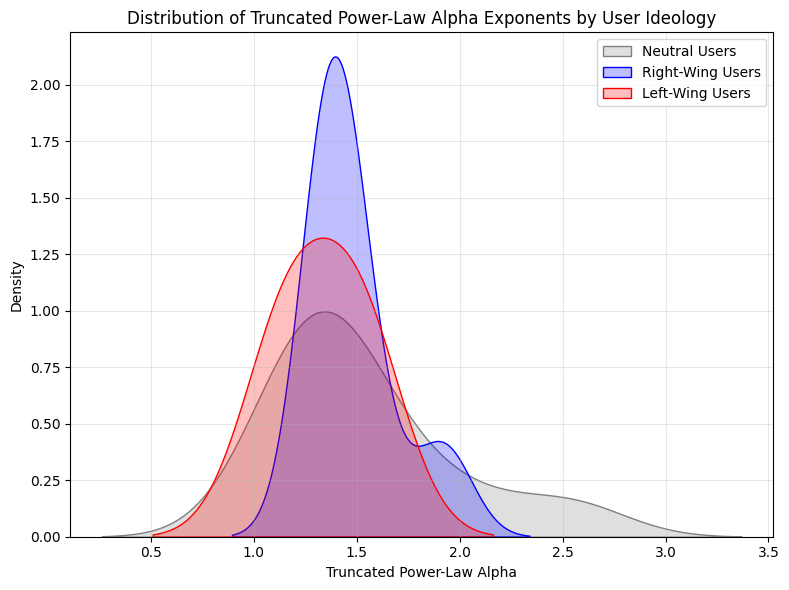

In [ ]:
# Compare the truncated power-law exponents (alpha and lambda) across the three ideology groups for the active users, and plot the distributions of these exponents for each group.
def extract_truncated_power_law_params(active_users, messages_df):
    alphas = []
    lambdas = []
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        waiting_time = user_dates.diff().dropna()
        fit_tpl = fit_truncated_power_law_report(waiting_time.dt.total_seconds(), f"User {user}", show_results=False, show_plots=False)
        if fit_tpl is not None:
            tpl = fit_tpl.truncated_power_law
            alphas.append(getattr(tpl, "alpha", np.nan))
            lambdas.append(getattr(tpl, "lambda_", np.nan))
    return alphas, lambdas
neutral_alphas, neutral_lambdas = extract_truncated_power_law_params(neutral_active_users, neutral_messages)
right_alphas, right_lambdas = extract_truncated_power_law_params(right_active_users, right_messages)
left_alphas, left_lambdas = extract_truncated_power_law_params(left_active_users, left_messages)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(neutral_alphas, color='gray', label='Neutral Users', fill=True)
sns.kdeplot(right_alphas, color='blue', label='Right-Wing Users', fill=True)
sns.kdeplot(left_alphas, color='red', label='Left-Wing Users', fill=True)
plt.xlabel('Truncated Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Truncated Power-Law Alpha Exponents by User Ideology')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

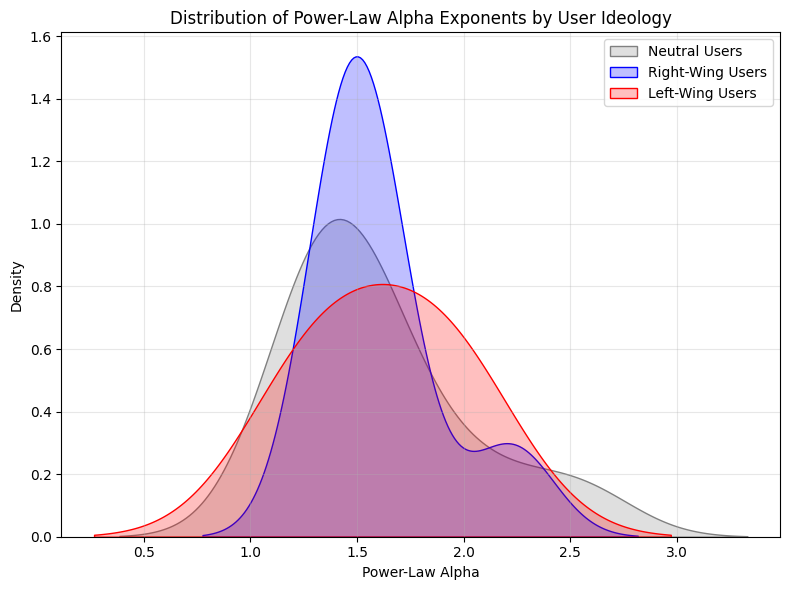

In [ ]:
# Compare the normal power-law exponents (alpha and lambda) across the three ideology groups for the active users, and plot the distributions of these exponents for each group.
def extract_power_law_params(active_users, messages_df):
    alphas = []
    lambdas = []
    for user in active_users:
        user_messages = messages_df[messages_df['sender_id'] == user] # Gather messages sent by the user.
        user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
        waiting_time = user_dates.diff().dropna()
        fit_tpl = fit_power_law_report(waiting_time.dt.total_seconds(), f"User {user}", show_results=False, show_plots=False)
        if fit_tpl is not None:
            tpl = fit_tpl.power_law
            alphas.append(getattr(tpl, "alpha", np.nan))
            lambdas.append(getattr(tpl, "lambda_", np.nan))
    return alphas, lambdas
neutral_alphas, neutral_lambdas = extract_power_law_params(neutral_active_users, neutral_messages)
right_alphas, right_lambdas = extract_power_law_params(right_active_users, right_messages)
left_alphas, left_lambdas = extract_power_law_params(left_active_users, left_messages)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(neutral_alphas, color='gray', label='Neutral Users', fill=True)
sns.kdeplot(right_alphas, color='blue', label='Right-Wing Users', fill=True)
sns.kdeplot(left_alphas, color='red', label='Left-Wing Users', fill=True)
plt.xlabel('Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Power-Law Alpha Exponents by User Ideology')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Credibility_score division

In [ ]:
# Divide users into three groups based on their credibility score: credible (<0), neutral (0), and non-credible (>0).
credible_users = df_users[df_users['credibility_score'] < 0] # Gather users with a credible credibility score (<0).
neutral_credibility_users = df_users[df_users['credibility_score'] == 0] # Gather users with a neutral credibility score (0).
non_credible_users = df_users[df_users['credibility_score'] > 0] # Gather users with a non-credible credibility score (>0).


In [ ]:
neutral_credibility_users.size, non_credible_users.size, credible_users.size

(1188, 108, 45)

In [ ]:
neutral_credibility_users_id = neutral_credibility_users['sender_id'].tolist() # Get the sender IDs of neutral users.
credible_users_id = credible_users['sender_id'].tolist() # Get the sender IDs of credible users.
non_credible_users_id = non_credible_users['sender_id'].tolist() # Get the sender IDs of non-credible users.

In [ ]:
# Gather messages sent by neutral users, credible users, and non-credible users.
neutral_credibility_messages = df[df['sender_id'].isin(neutral_credibility_users_id)] # Gather messages sent by neutral users.
credible_messages = df[df['sender_id'].isin(credible_users_id)] # Gather messages sent by credible users.
non_credible_messages = df[df['sender_id'].isin(non_credible_users_id)] # Gather messages sent by non-credible users.

neutral_credibility_messages.size, credible_messages.size, non_credible_messages.size

(102493, 34272, 37536)

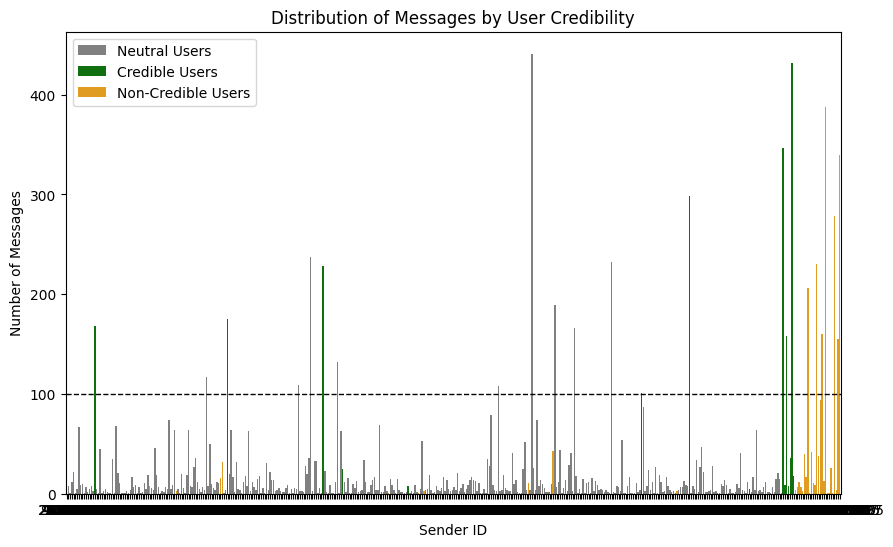

In [142]:
# Plot the distribution of messages sent by neutral users, credible users, and non-credible users.
plt.figure(figsize=(10, 6))
sns.countplot(x='sender_id', data=neutral_messages, color='gray', label='Neutral Users')
sns.countplot(x='sender_id', data=credible_messages, color='green', label='Credible Users')
sns.countplot(x='sender_id', data=non_credible_messages, color='orange', label='Non-Credible Users')
plt.axhline(y=100, color='black', linestyle='--', linewidth=1) # Add a horizontal line at y=100 for better visualization of the distribution of the cutoff.
plt.xlabel('Sender ID')
plt.ylabel('Number of Messages')
plt.title('Distribution of Messages by User Credibility')
plt.legend()
plt.show()

In [ ]:
# gather users with 100 or more messages sent for each credibility group
neutral_credibility_active_users = neutral_messages['sender_id'].value_counts()[neutral_messages['sender_id'].value_counts() >= 100].index.tolist() # Gather sender IDs of neutral users with 100 or more messages sent.
credible_active_users = credible_messages['sender_id'].value_counts()[credible_messages['sender_id'].value_counts() >= 100].index.tolist() # Gather sender IDs of credible users with 100 or more messages sent.
non_credible_active_users = non_credible_messages['sender_id'].value_counts()[non_credible_messages['sender_id'].value_counts() >= 100].index.tolist() # Gather sender IDs of non-credible users with 100 or more messages sent.
len(neutral_credibility_active_users), len(credible_active_users), len(non_credible_active_users)

(14, 8, 7)

In [ ]:
# from these active users, get their period of activity and number of messages sent

print_active_users_summary("Neutral", neutral_credibility_active_users, neutral_credibility_messages)
print_active_users_summary("Credible", credible_active_users, credible_messages)
print_active_users_summary("Non-Credible", non_credible_active_users, non_credible_messages)

Neutral Active Users:

User 1762777403 has a period of activity of 52 days 17:26:21 and has sent 441 messages.
User 6601816159 has a period of activity of NaT and has sent 0 messages.
User 1095473116 has a period of activity of 7 days 12:38:49 and has sent 237 messages.
User 5689570195 has a period of activity of 104 days 06:51:49 and has sent 232 messages.
User 1110241832 has a period of activity of NaT and has sent 0 messages.
User 2047003776 has a period of activity of 358 days 09:02:19 and has sent 189 messages.
User 791270353 has a period of activity of NaT and has sent 0 messages.
User 57072401 has a period of activity of NaT and has sent 0 messages.
User 5212333848 has a period of activity of 6 days 04:21:20 and has sent 166 messages.
User 1131058651 has a period of activity of 48 days 15:04:11 and has sent 132 messages.
User 693274644 has a period of activity of 9 days 18:07:40 and has sent 117 messages.
User 1065332141 has a period of activity of 6 days 10:28:52 and has sent 1

In [ ]:
# Remove users with a period of activity of less than 10 days


neutral_credibility_active_users = filter_users_by_activity(neutral_credibility_active_users, neutral_credibility_messages, min_days=10)
credible_active_users = filter_users_by_activity(credible_active_users, credible_messages, min_days=10)
non_credible_active_users = filter_users_by_activity(non_credible_active_users, non_credible_messages, min_days=10)

len(neutral_credibility_active_users), len(credible_active_users), len(non_credible_active_users)

(5, 8, 5)

In [ ]:
# from these active users, get their period of activity and number of messages sent

print_active_users_summary("Neutral", neutral_credibility_active_users, neutral_credibility_messages)
print_active_users_summary("Credible", credible_active_users, credible_messages)
print_active_users_summary("Non-Credible", non_credible_active_users, non_credible_messages)

Neutral Active Users:

User 1762777403 has a period of activity of 52 days 17:26:21 and has sent 441 messages.
User 5689570195 has a period of activity of 104 days 06:51:49 and has sent 232 messages.
User 2047003776 has a period of activity of 358 days 09:02:19 and has sent 189 messages.
User 1131058651 has a period of activity of 48 days 15:04:11 and has sent 132 messages.
User 1551829597 has a period of activity of 213 days 00:44:52 and has sent 108 messages.
Credible Active Users:

User 7094531229 has a period of activity of 108 days 03:26:50 and has sent 432 messages.
User 271855505 has a period of activity of 140 days 18:40:09 and has sent 347 messages.
User 6601816159 has a period of activity of 40 days 08:34:08 and has sent 298 messages.
User 1110241832 has a period of activity of 375 days 22:27:23 and has sent 228 messages.
User 791270353 has a period of activity of 56 days 17:01:07 and has sent 175 messages.
User 57072401 has a period of activity of 25 days 02:03:04 and has se

### Waiting times for neutral users



Analyzing waiting times for Neutral User 1762777403...
POWER LAW FIT RESULTS: Neutral User 1762777403
alpha: 1.4724
xmin: 437.0000
sigma: 0.0384
Data points above xmin: 151 / 427 (35.36%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -2.4602, p = 0.0041
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.3124, p = 0.1894
  No significant difference

Power Law vs Exponential:
  R = 6.8412, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0429
KS p-value (tail): 0.834089


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


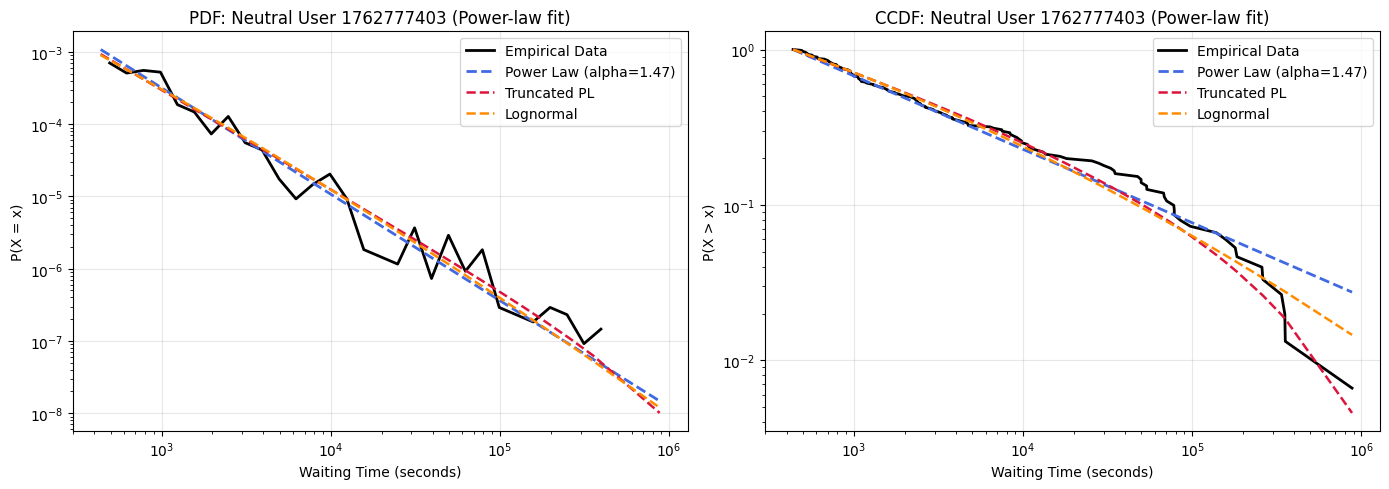

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Neutral User 1762777403
alpha: 1.3740
lambda: nan
xmin: 437.0000
sigma: nan
Data points above xmin: 151 / 427 (35.36%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.4602, p = 0.0041
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 2.7630, p = 0.0057
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 7.2816, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0644
KS p-value (tail): 0.536928


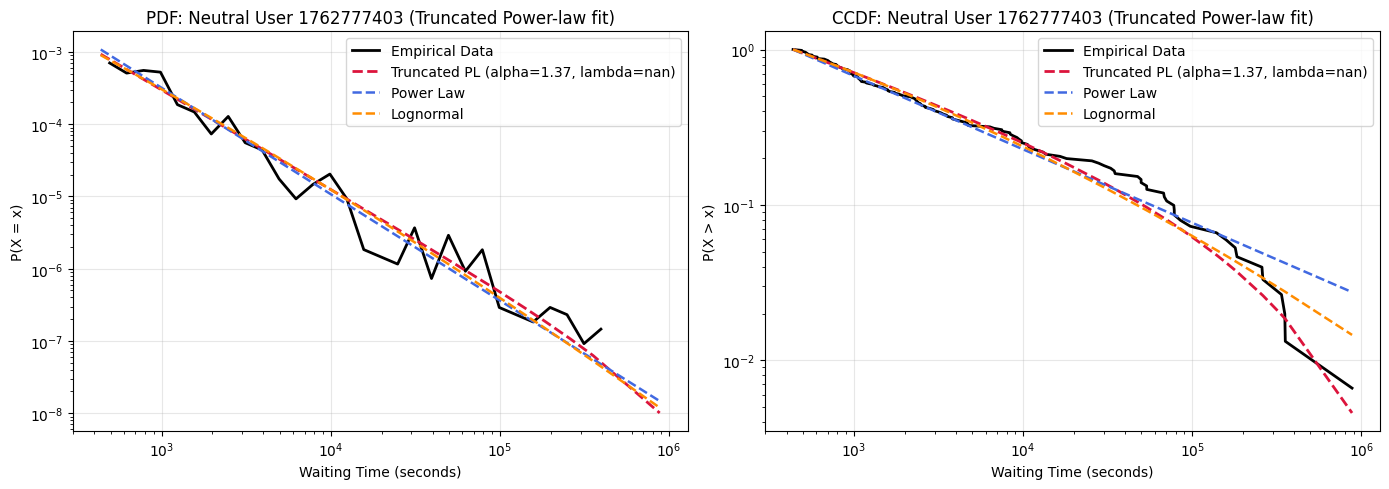



Analyzing waiting times for Neutral User 5689570195...
POWER LAW FIT RESULTS: Neutral User 5689570195
alpha: 1.6879
xmin: 17284.0000
sigma: 0.1088
Data points above xmin: 40 / 223 (17.94%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -1.1255, p = 0.2124
  No significant difference

Power Law vs Lognormal:
  R = -0.5134, p = 0.6077
  No significant difference

Power Law vs Exponential:
  R = 3.2514, p = 0.0011
  Power law is significantly better

KS distance (power law): 0.0639
KS p-value (tail): 0.993232


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


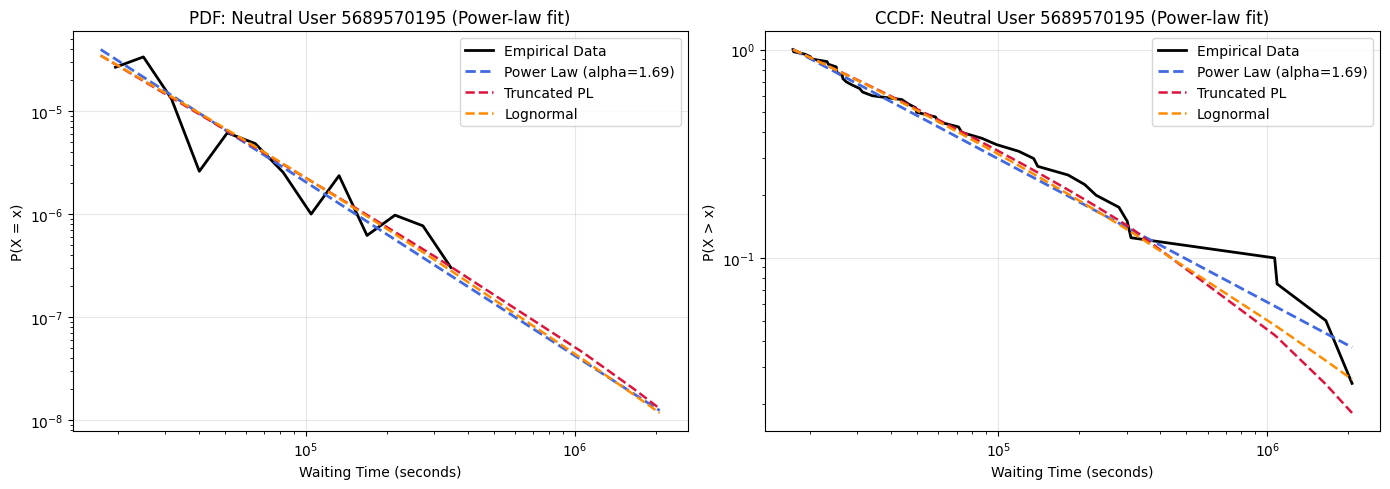

TRUNCATED POWER LAW FIT RESULTS: Neutral User 5689570195
alpha: 1.5485
lambda: nan
xmin: 17284.0000
sigma: nan
Data points above xmin: 40 / 223 (17.94%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.1255, p = 0.2124
  No significant difference

Truncated PL vs Lognormal:
  R = 1.6202, p = 0.1052
  No significant difference

Truncated PL vs Exponential:
  R = 3.5834, p = 0.0003
  Truncated power law is significantly better

KS distance (truncated power law): 0.0950
KS p-value (tail): 0.829716


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


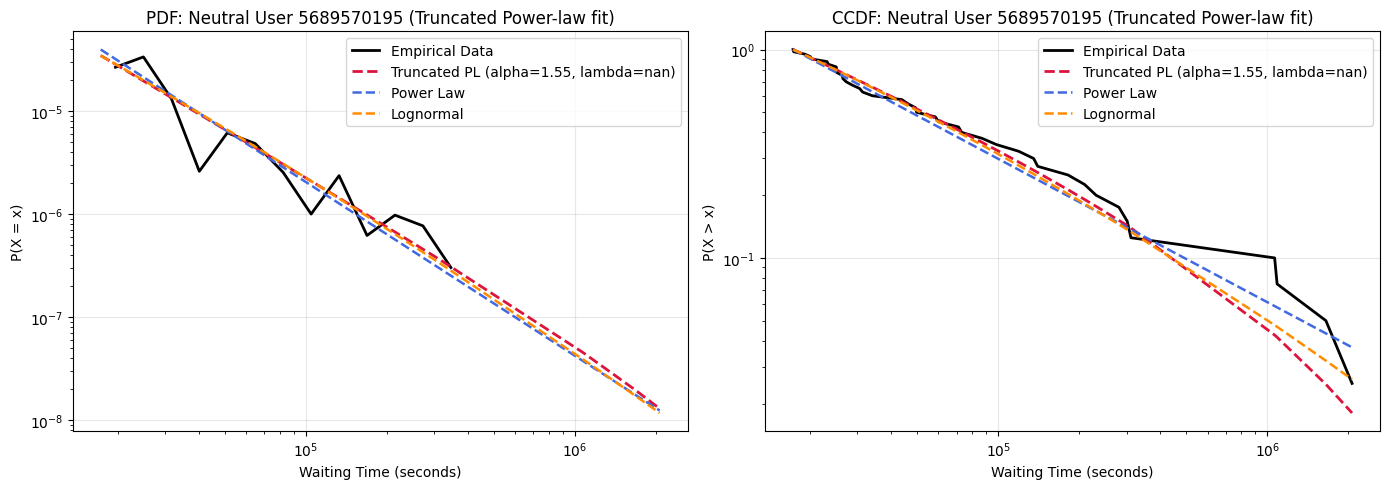



Analyzing waiting times for Neutral User 2047003776...
POWER LAW FIT RESULTS: Neutral User 2047003776
alpha: 1.6681
xmin: 21406.0000
sigma: 0.0926
Data points above xmin: 52 / 182 (28.57%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -0.7834, p = 0.5076
  No significant difference

Power Law vs Lognormal:
  R = -0.3230, p = 0.7467
  No significant difference

Power Law vs Exponential:
  R = 2.7867, p = 0.0053
  Power law is significantly better

KS distance (power law): 0.0579
KS p-value (tail): 0.984287


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


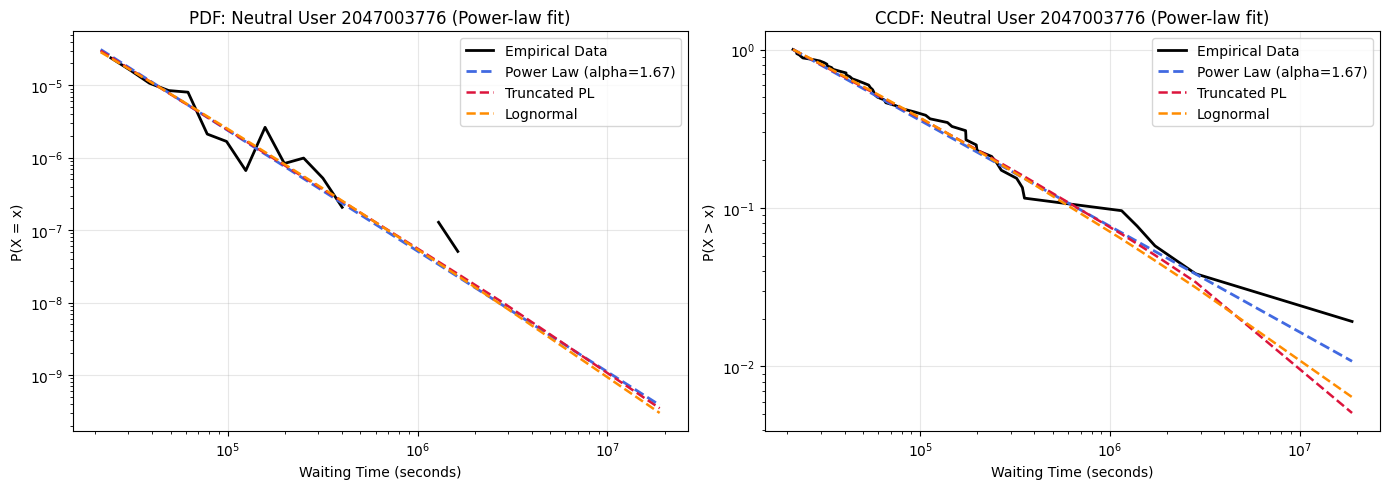

TRUNCATED POWER LAW FIT RESULTS: Neutral User 2047003776
alpha: 1.6325
lambda: nan
xmin: 21406.0000
sigma: nan
Data points above xmin: 52 / 182 (28.57%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 0.7834, p = 0.5076
  No significant difference

Truncated PL vs Lognormal:
  R = 0.2826, p = 0.7774
  No significant difference

Truncated PL vs Exponential:
  R = 2.8165, p = 0.0049
  Truncated power law is significantly better

KS distance (truncated power law): 0.0617
KS p-value (tail): 0.981831


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


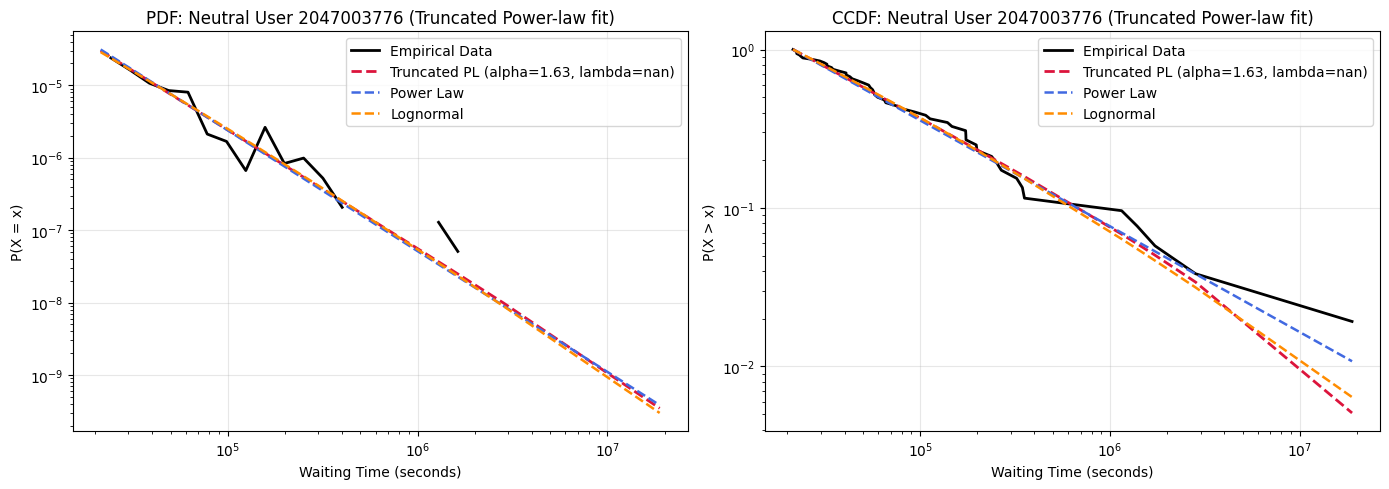



Analyzing waiting times for Neutral User 1131058651...
POWER LAW FIT RESULTS: Neutral User 1131058651
alpha: 1.3035
xmin: 19.0000
sigma: 0.0300
Data points above xmin: 102 / 108 (94.44%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -2.2016, p = 0.0106
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.2798, p = 0.2006
  No significant difference

Power Law vs Exponential:
  R = 6.2761, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0740
KS p-value (tail): 0.44665


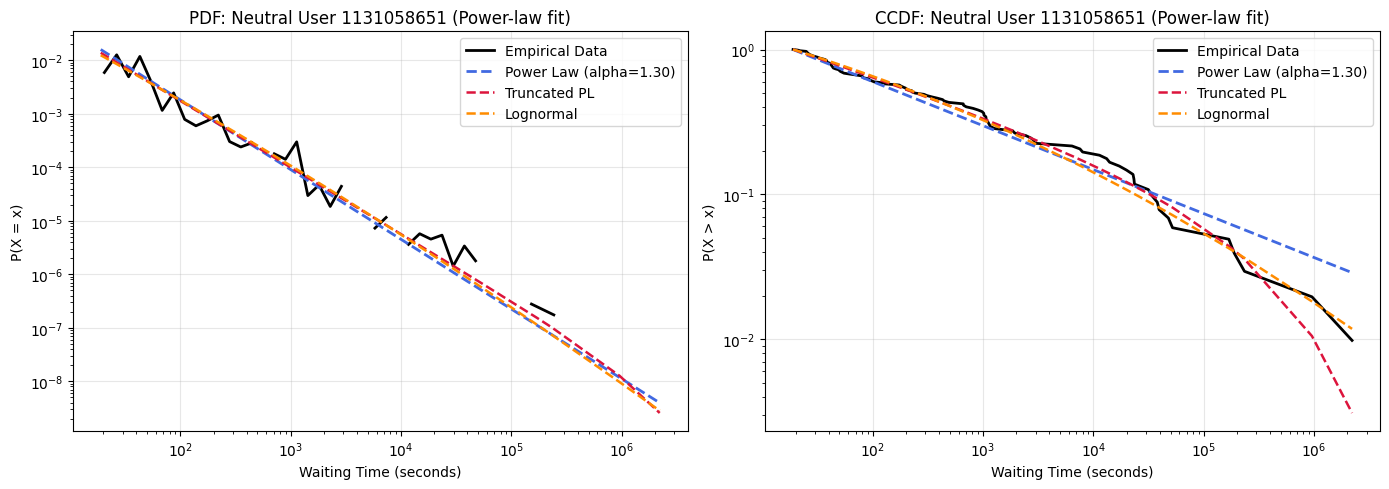

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Neutral User 1131058651
alpha: 1.2444
lambda: nan
xmin: 19.0000
sigma: nan
Data points above xmin: 102 / 108 (94.44%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.2016, p = 0.0106
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 1.4858, p = 0.1373
  No significant difference

Truncated PL vs Exponential:
  R = 6.4772, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0831
KS p-value (tail): 0.456831


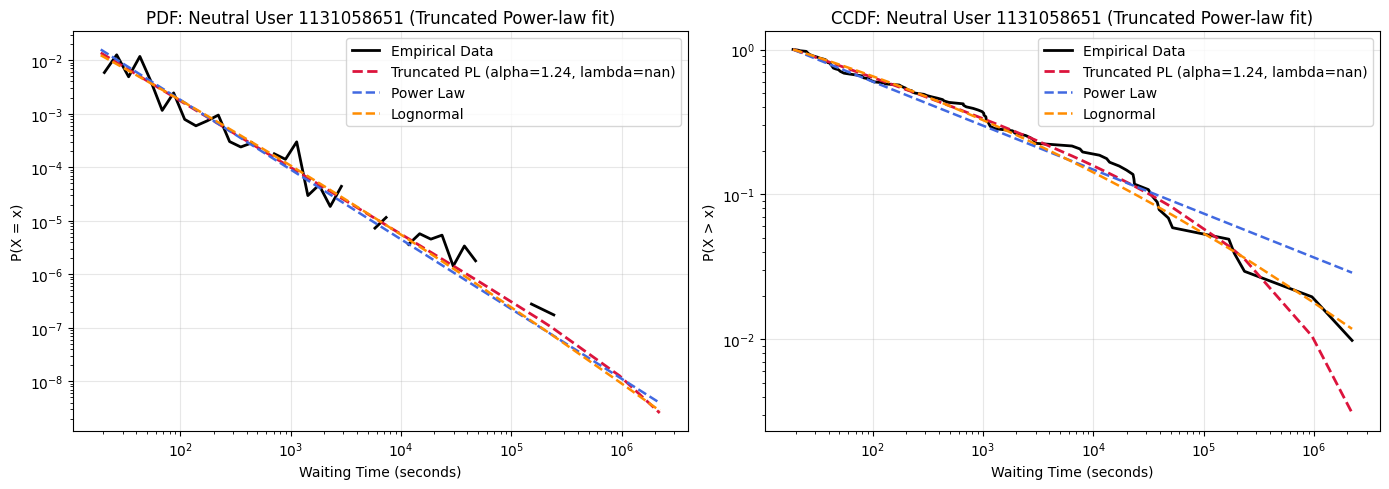



Analyzing waiting times for Neutral User 1551829597...
POWER LAW FIT RESULTS: Neutral User 1551829597
alpha: 2.5386
xmin: 355001.0000
sigma: 0.4267
Data points above xmin: 13 / 102 (12.75%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = 0.0002, p = 0.9996
  No significant difference

Power Law vs Lognormal:
  R = 1.9494, p = 0.0512
  No significant difference

Power Law vs Exponential:
  R = 3.5904, p = 0.0003
  Power law is significantly better

KS distance (power law): 0.2004
KS p-value (tail): 0.604416


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:2792: RuntimeWarning: invalid value encountered in divide
  return likelihoods/norm
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


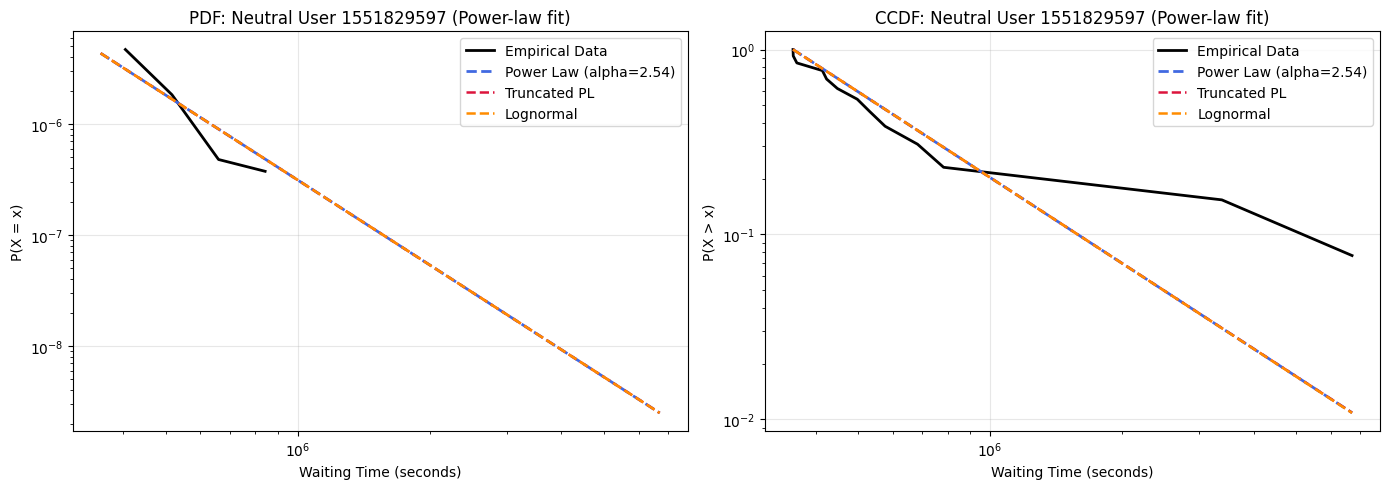

TRUNCATED POWER LAW FIT RESULTS: Neutral User 1551829597
alpha: 2.5384
lambda: nan
xmin: 355001.0000
sigma: nan
Data points above xmin: 13 / 102 (12.75%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = -0.0002, p = 0.9996
  No significant difference

Truncated PL vs Lognormal:
  R = 2.0698, p = 0.0385
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 3.5907, p = 0.0003
  Truncated power law is significantly better

KS distance (truncated power law): 0.2004
KS p-value (tail): 0.604392


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:2792: RuntimeWarning: invalid value encountered in divide
  return likelihoods/norm
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


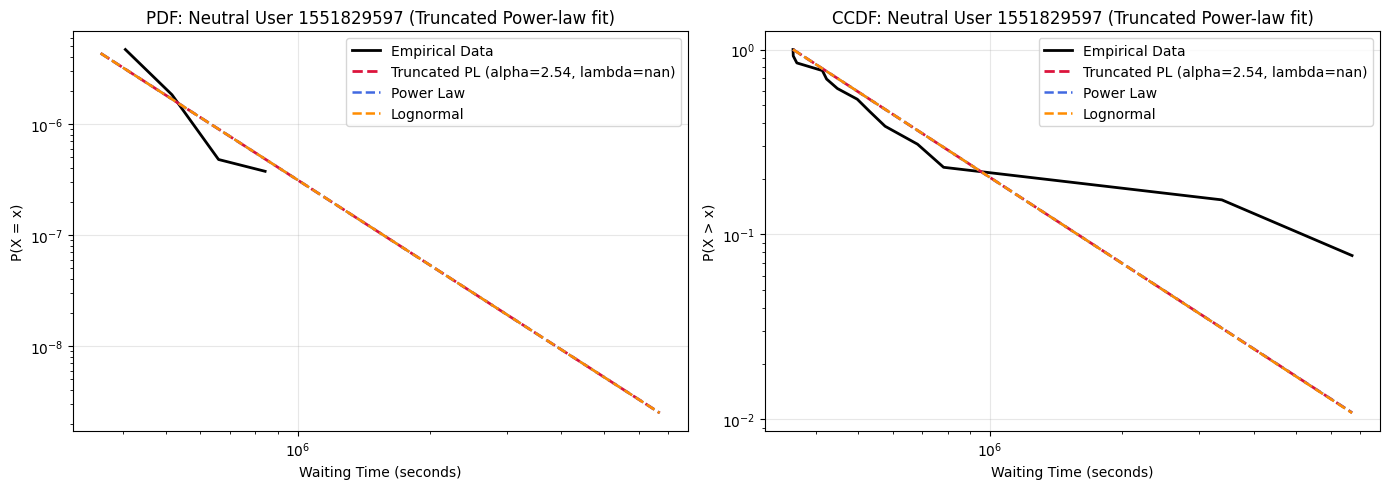

In [ ]:
for user in neutral_credibility_active_users:
    user_messages = neutral_credibility_messages[neutral_credibility_messages['sender_id'] == user] # Gather messages sent by the user.
    user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
    waiting_time = user_dates.diff().dropna()
    # Fit the waiting time to a power-law distribution and plot it with comparisons to other distributions and KS test on the tail
    print(f"\n\nAnalyzing waiting times for Neutral User {user}...")
    fit_power_law_report(waiting_time.dt.total_seconds(), f"Neutral User {user}")
    fit_truncated_power_law_report(waiting_time.dt.total_seconds(), f"Neutral User {user}")


### Credible users



Analyzing waiting times for Credible User 7094531229...
POWER LAW FIT RESULTS: Credible User 7094531229
alpha: 1.3662
xmin: 37.0000
sigma: 0.0195
Data points above xmin: 354 / 423 (83.69%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -3.3290, p = 0.0002
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.2055, p = 0.2280
  No significant difference

Power Law vs Exponential:
  R = 11.6443, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0611
KS p-value (tail): 0.136352


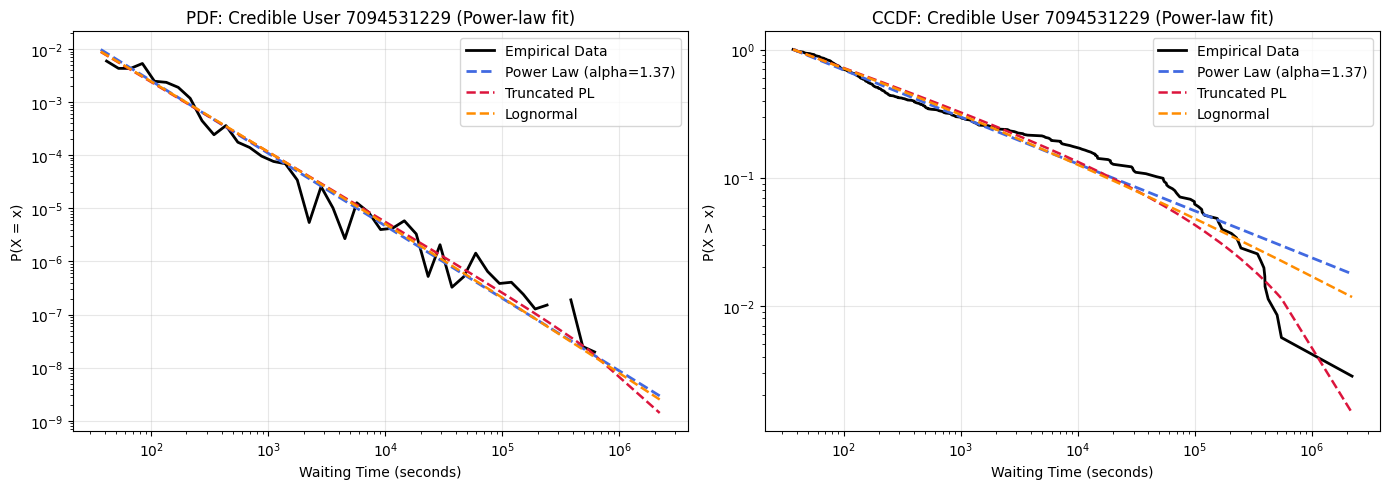

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Credible User 7094531229
alpha: 1.3164
lambda: nan
xmin: 37.0000
sigma: nan
Data points above xmin: 354 / 423 (83.69%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 3.3290, p = 0.0002
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 3.8768, p = 0.0001
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 11.9315, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0923
KS p-value (tail): 0.00446305


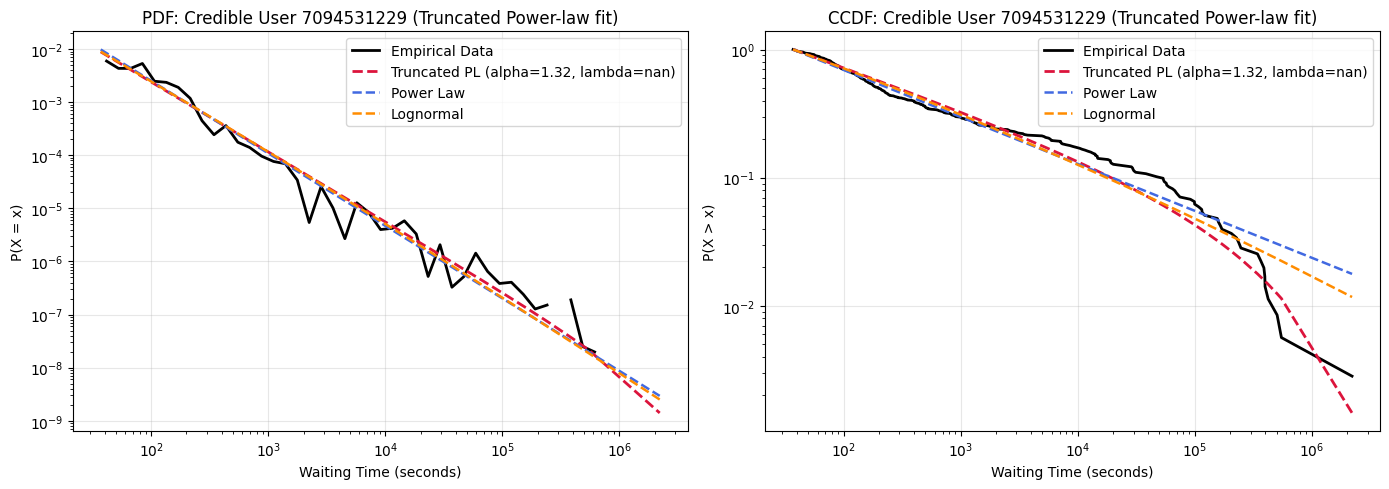



Analyzing waiting times for Credible User 271855505...
POWER LAW FIT RESULTS: Credible User 271855505
alpha: 1.9075
xmin: 36920.0000
sigma: 0.1162
Data points above xmin: 61 / 342 (17.84%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -1.6283, p = 0.0376
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.2394, p = 0.2152
  No significant difference

Power Law vs Exponential:
  R = 1.6008, p = 0.1094
  No significant difference

KS distance (power law): 0.0817
KS p-value (tail): 0.565943


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


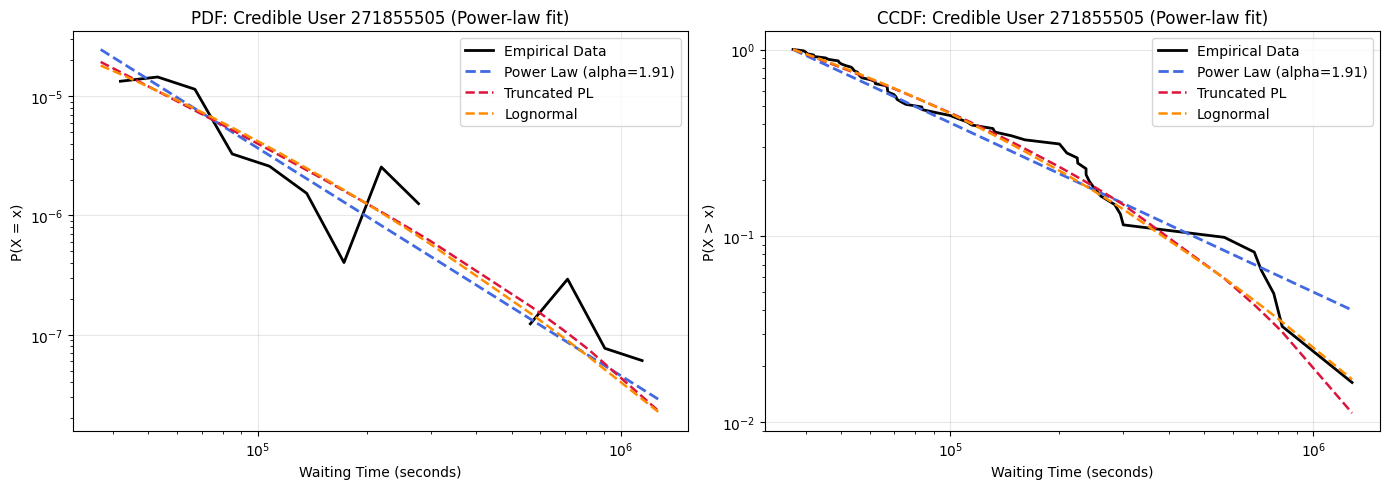

TRUNCATED POWER LAW FIT RESULTS: Credible User 271855505
alpha: 1.5112
lambda: nan
xmin: 36920.0000
sigma: nan
Data points above xmin: 61 / 342 (17.84%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.6283, p = 0.0376
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 1.3420, p = 0.1796
  No significant difference

Truncated PL vs Exponential:
  R = 2.4148, p = 0.0157
  Truncated power law is significantly better

KS distance (truncated power law): 0.0881
KS p-value (tail): 0.698


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


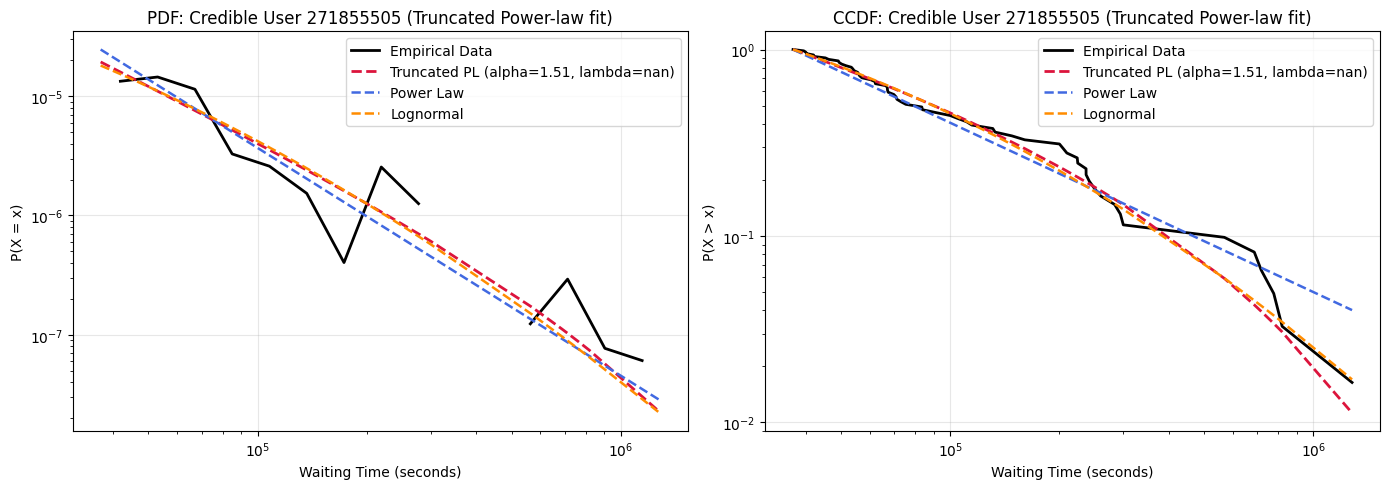



Analyzing waiting times for Credible User 6601816159...
POWER LAW FIT RESULTS: Credible User 6601816159
alpha: 1.3602
xmin: 46.0000
sigma: 0.0265
Data points above xmin: 185 / 280 (66.07%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -3.1298, p = 0.0005
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.7754, p = 0.0758
  No significant difference

Power Law vs Exponential:
  R = 9.4921, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0440
KS p-value (tail): 0.736985


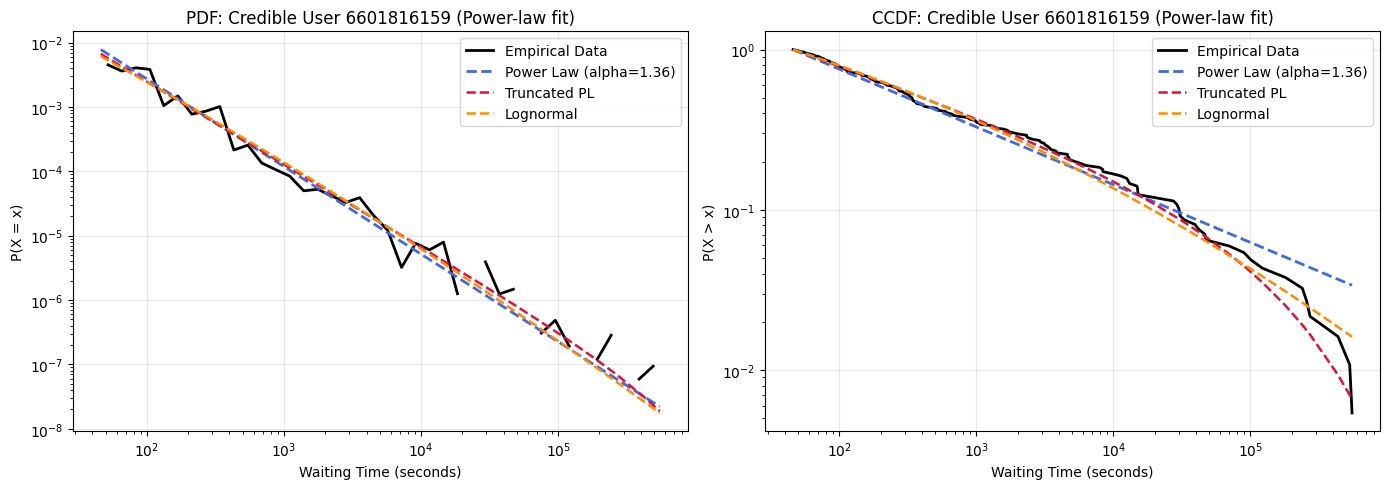

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Credible User 6601816159
alpha: 1.2830
lambda: nan
xmin: 46.0000
sigma: nan
Data points above xmin: 185 / 280 (66.07%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 3.1298, p = 0.0005
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 2.4766, p = 0.0133
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 9.9557, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0617
KS p-value (tail): 0.464033


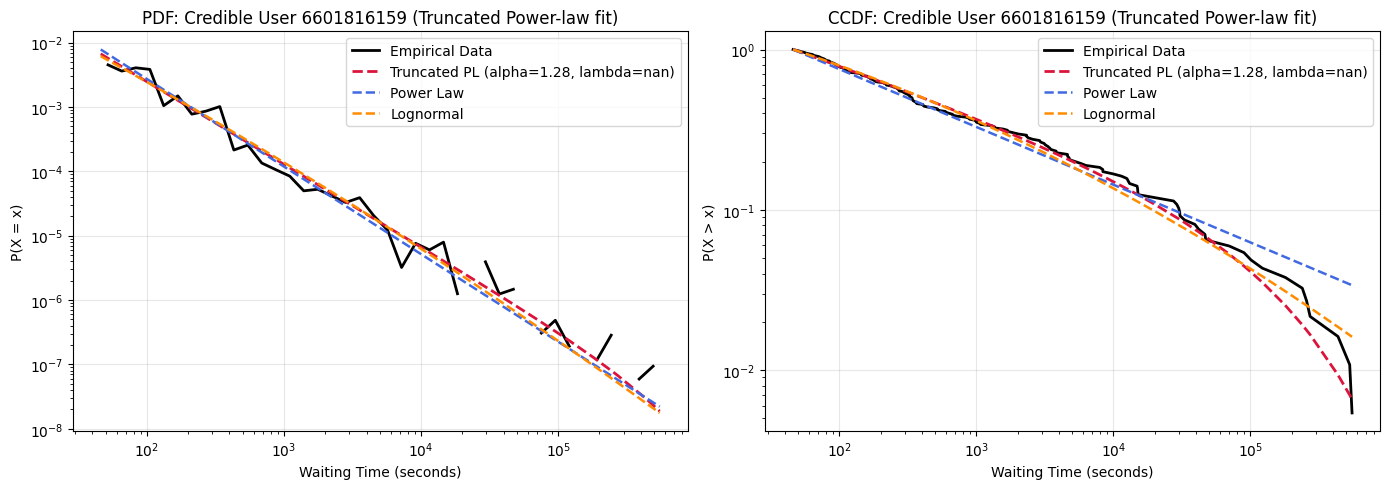



Analyzing waiting times for Credible User 1110241832...
POWER LAW FIT RESULTS: Credible User 1110241832
alpha: 1.4284
xmin: 2395.0000
sigma: 0.0449
Data points above xmin: 91 / 221 (41.18%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -1.7441, p = 0.0359
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.4325, p = 0.1520
  No significant difference

Power Law vs Exponential:
  R = 3.6368, p = 0.0003
  Power law is significantly better

KS distance (power law): 0.0847
KS p-value (tail): 0.353037


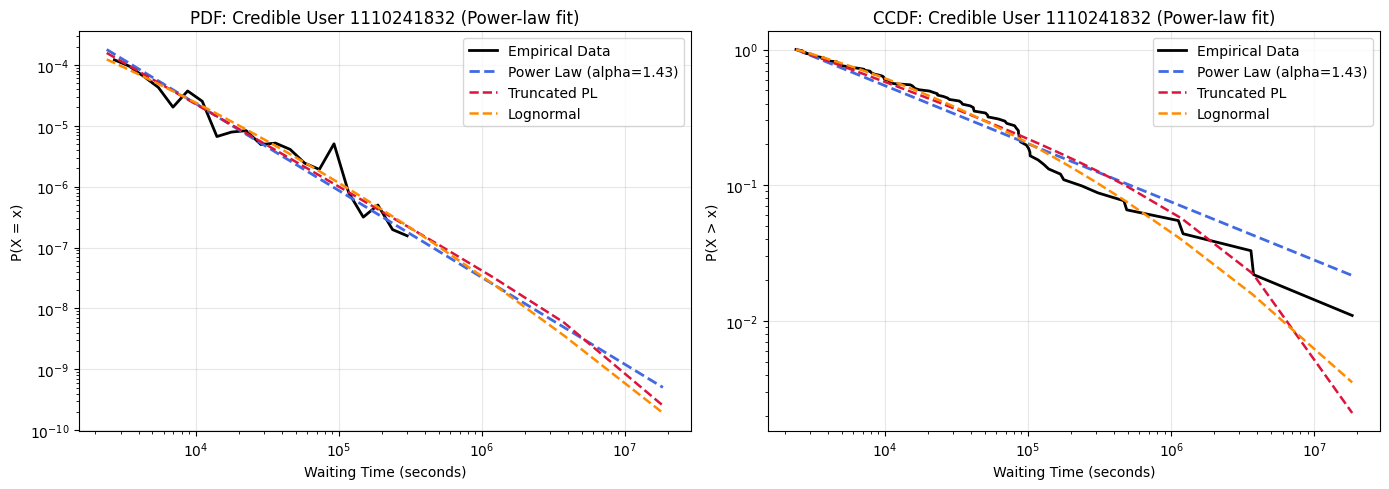

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Credible User 1110241832
alpha: 1.3524
lambda: nan
xmin: 2395.0000
sigma: nan
Data points above xmin: 91 / 221 (41.18%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.7441, p = 0.0359
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = -0.7461, p = 0.4556
  No significant difference

Truncated PL vs Exponential:
  R = 3.7702, p = 0.0002
  Truncated power law is significantly better

KS distance (truncated power law): 0.0685
KS p-value (tail): 0.760987


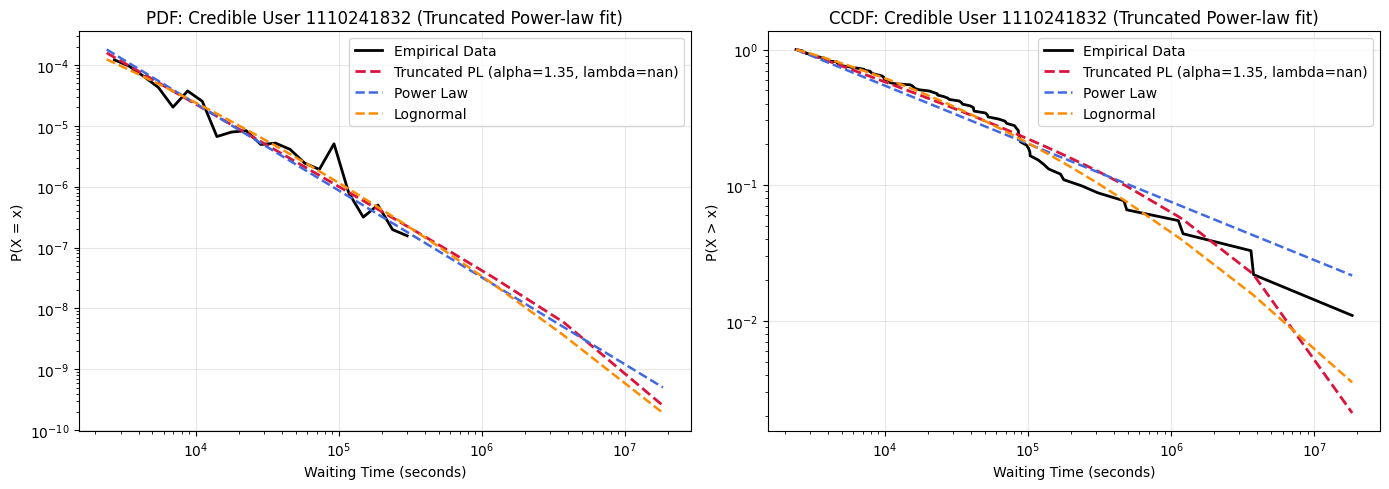



Analyzing waiting times for Credible User 791270353...
POWER LAW FIT RESULTS: Credible User 791270353
alpha: 2.0894
xmin: 40490.0000
sigma: 0.2224
Data points above xmin: 24 / 146 (16.44%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -0.4139, p = 0.7105
  No significant difference

Power Law vs Lognormal:
  R = -0.0864, p = 0.9311
  No significant difference

Power Law vs Exponential:
  R = 1.7864, p = 0.0740
  No significant difference

KS distance (power law): 0.0938
KS p-value (tail): 0.97114


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


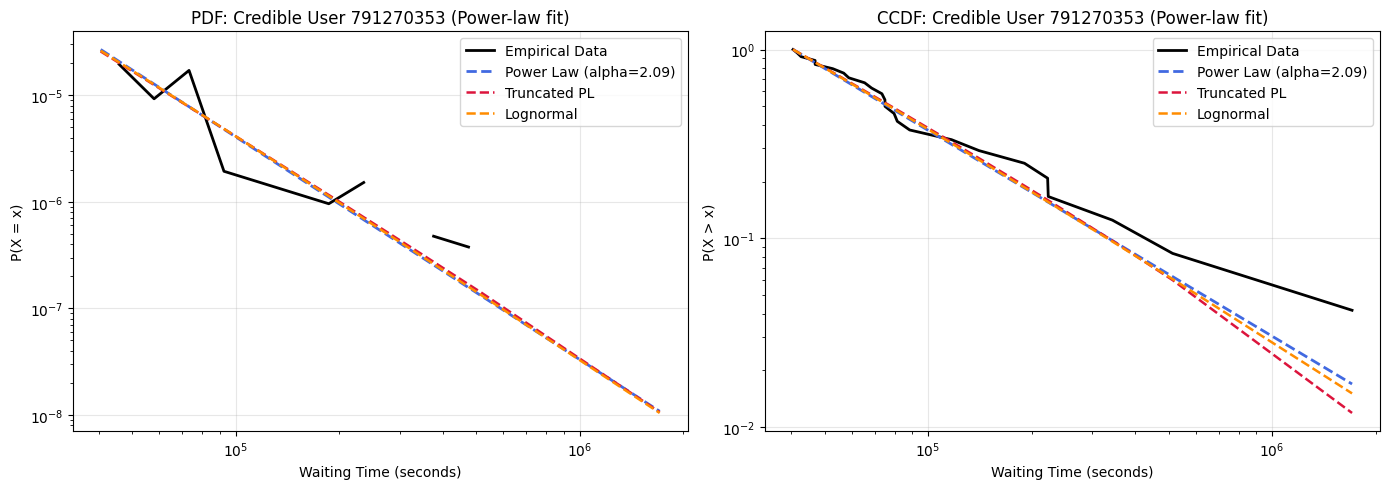

TRUNCATED POWER LAW FIT RESULTS: Credible User 791270353
alpha: 2.0178
lambda: nan
xmin: 40490.0000
sigma: nan
Data points above xmin: 24 / 146 (16.44%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 0.4139, p = 0.7105
  No significant difference

Truncated PL vs Lognormal:
  R = 0.6443, p = 0.5194
  No significant difference

Truncated PL vs Exponential:
  R = 1.8335, p = 0.0667
  No significant difference

KS distance (truncated power law): 0.1051
KS p-value (tail): 0.928548


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


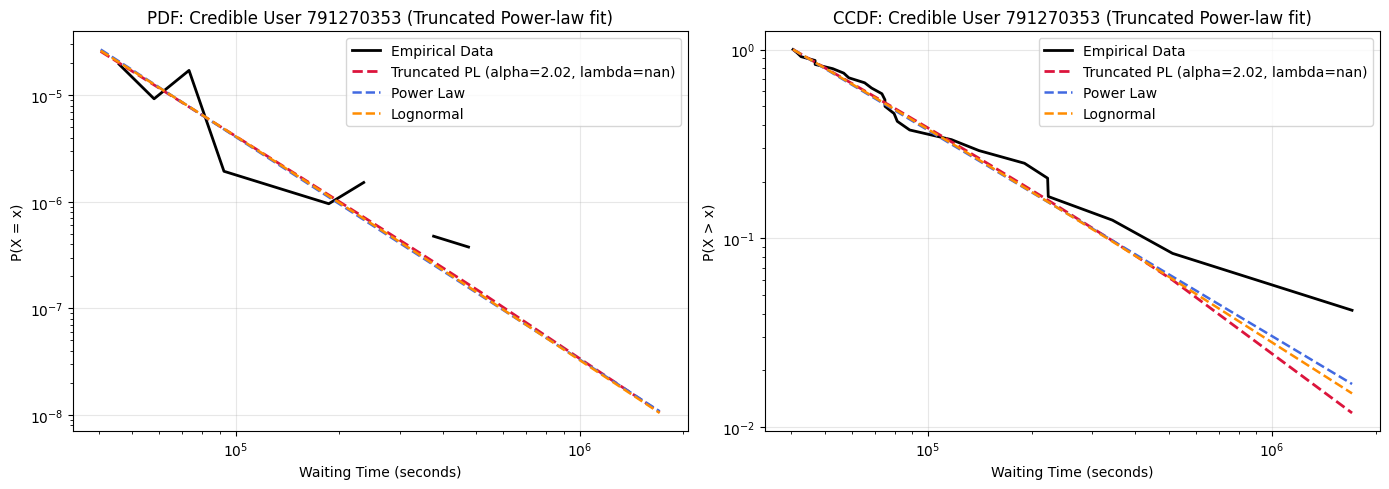



Analyzing waiting times for Credible User 57072401...
POWER LAW FIT RESULTS: Credible User 57072401
alpha: 1.3184
xmin: 10.0000
sigma: 0.0266
Data points above xmin: 143 / 167 (85.63%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -2.4671, p = 0.0040
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.1163, p = 0.2643
  No significant difference

Power Law vs Exponential:
  R = 8.1007, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0701
KS p-value (tail): 0.345216


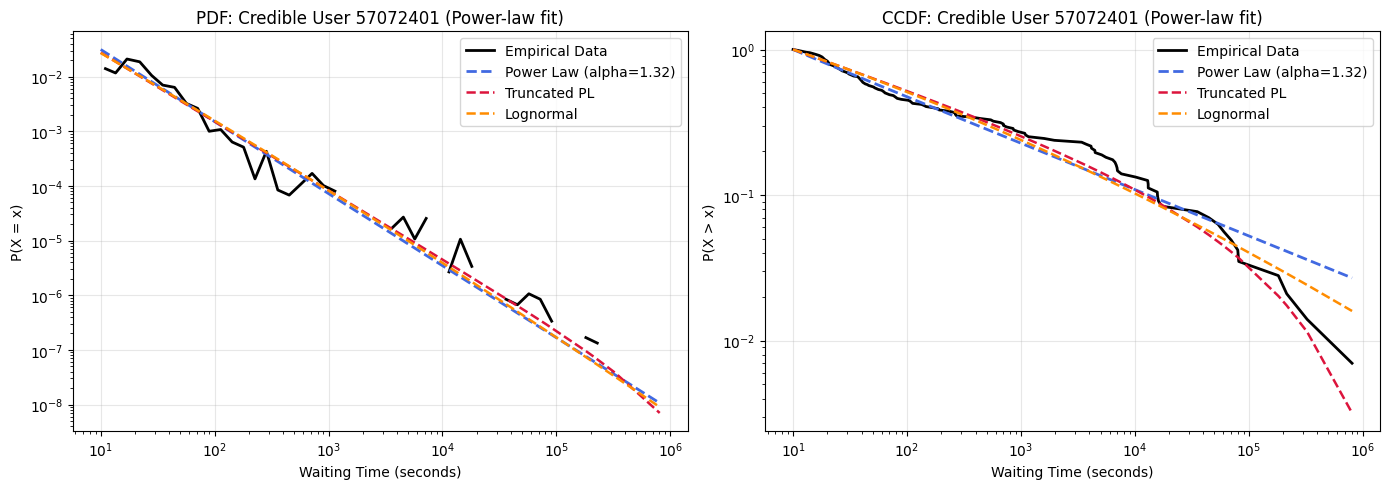

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Credible User 57072401
alpha: 1.2606
lambda: nan
xmin: 10.0000
sigma: nan
Data points above xmin: 143 / 167 (85.63%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.4671, p = 0.0040
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 2.9866, p = 0.0028
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 8.3692, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0970
KS p-value (tail): 0.127143


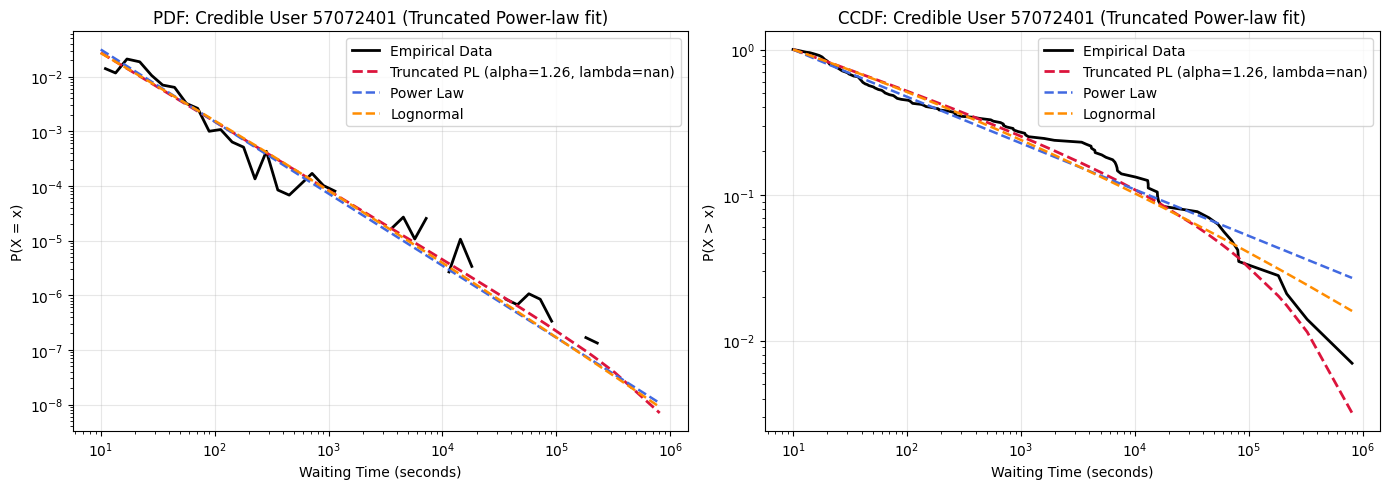



Analyzing waiting times for Credible User 1357872899...
POWER LAW FIT RESULTS: Credible User 1357872899
alpha: 1.3308
xmin: 147.0000
sigma: 0.0287
Data points above xmin: 133 / 156 (85.26%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -3.5549, p = 0.0000
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -2.3475, p = 0.0189
  lognormal is significantly better

Power Law vs Exponential:
  R = 7.1634, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0920
KS p-value (tail): 0.134084


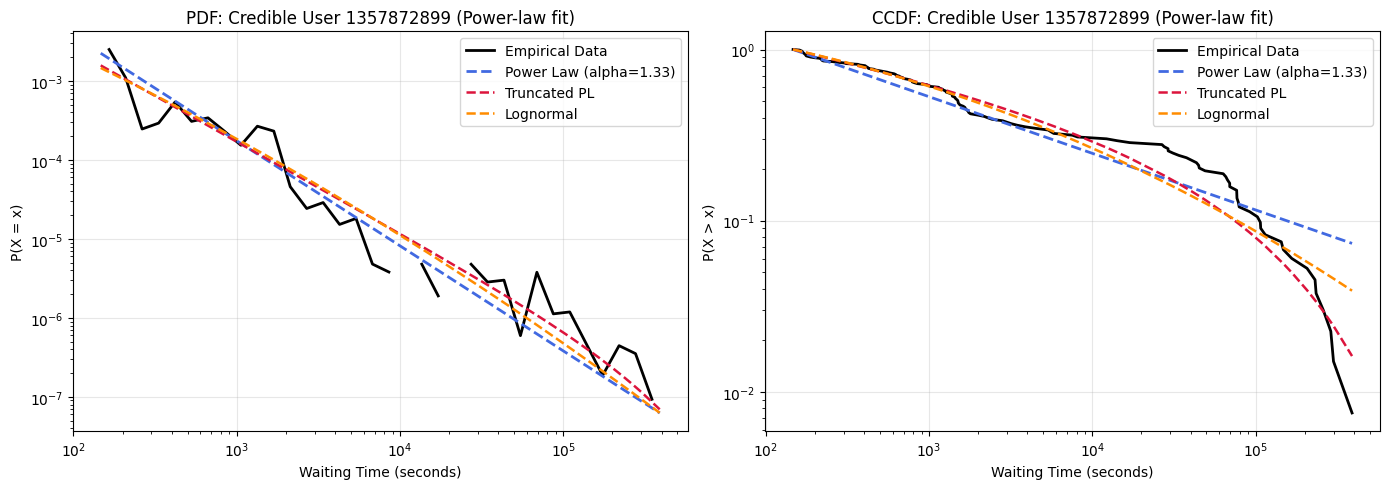

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Credible User 1357872899
alpha: 1.1591
lambda: nan
xmin: 147.0000
sigma: nan
Data points above xmin: 133 / 156 (85.26%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 3.5549, p = 0.0000
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 3.7806, p = 0.0002
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 8.8682, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.1084
KS p-value (tail): 0.0812373


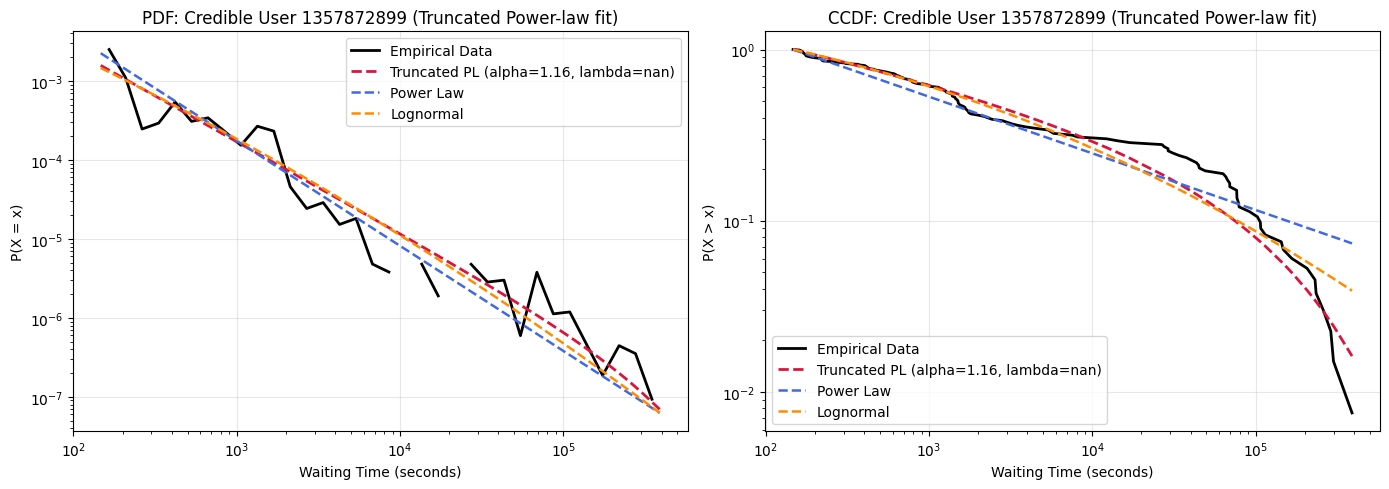



Analyzing waiting times for Credible User 5992929865...
POWER LAW FIT RESULTS: Credible User 5992929865
alpha: 1.1786
xmin: 3.0000
sigma: 0.0179
Data points above xmin: 100 / 100 (100.00%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -3.1490, p = 0.0000
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.7985, p = 0.0721
  No significant difference

Power Law vs Exponential:
  R = 9.4573, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.1066
KS p-value (tail): 0.121745


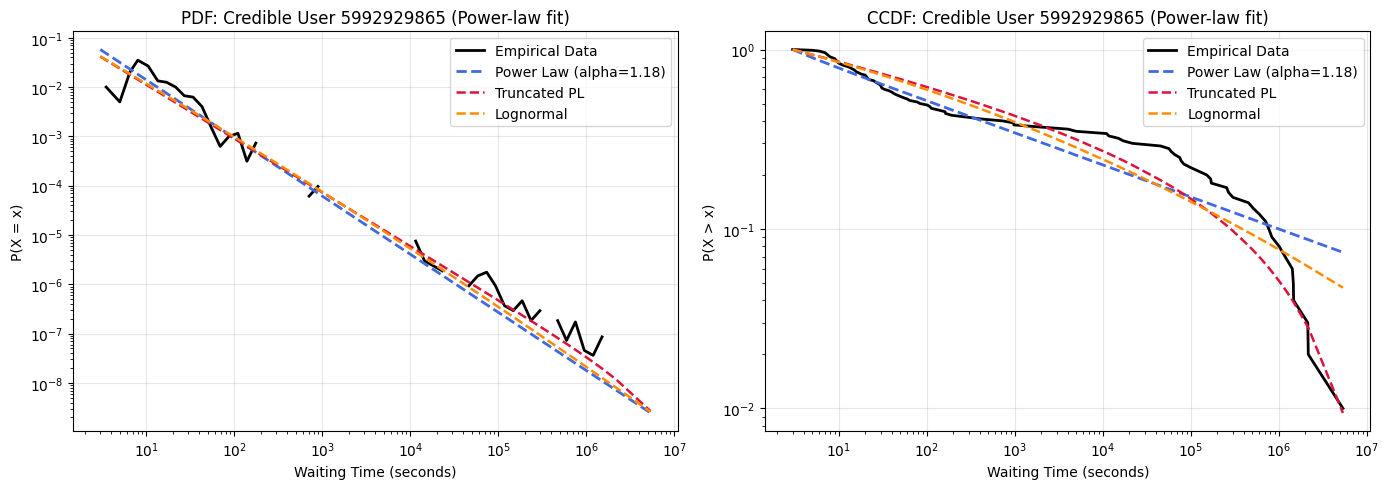

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Credible User 5992929865
alpha: 1.0918
lambda: nan
xmin: 3.0000
sigma: nan
Data points above xmin: 100 / 100 (100.00%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 3.1490, p = 0.0000
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 3.8818, p = 0.0001
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 10.4705, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.1549
KS p-value (tail): 0.0146517


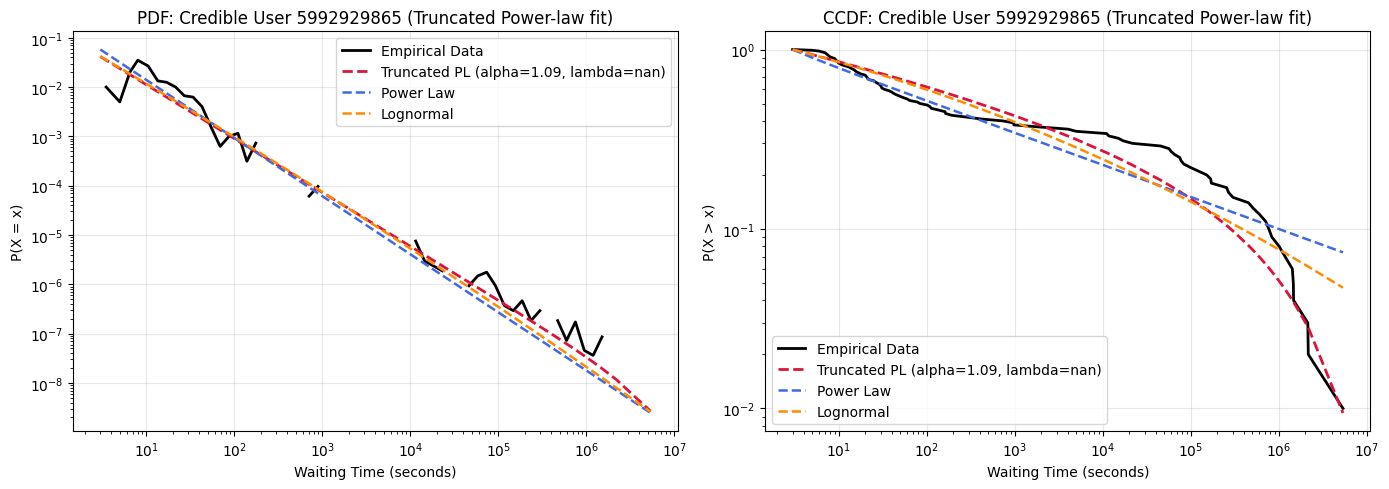

In [ ]:
for user in credible_active_users:
    user_messages = credible_messages[credible_messages['sender_id'] == user] # Gather messages sent by the user.
    user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
    waiting_time = user_dates.diff().dropna()
    # Fit the waiting time to a power-law distribution and plot it with comparisons to other distributions and KS test on the tail
    print(f"\n\nAnalyzing waiting times for Credible User {user}...")
    fit_power_law_report(waiting_time.dt.total_seconds(), f"Credible User {user}")
    fit_truncated_power_law_report(waiting_time.dt.total_seconds(), f"Credible User {user}")


### Non-credible users



Analyzing waiting times for Non-Credible User 1505404600...
POWER LAW FIT RESULTS: Non-Credible User 1505404600
alpha: 1.6882
xmin: 1359.0000
sigma: 0.0817
Data points above xmin: 71 / 386 (18.39%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -1.4046, p = 0.0930
  No significant difference

Power Law vs Lognormal:
  R = -0.6969, p = 0.4859
  No significant difference

Power Law vs Exponential:
  R = 3.5649, p = 0.0004
  Power law is significantly better

KS distance (power law): 0.0557
KS p-value (tail): 0.971309


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


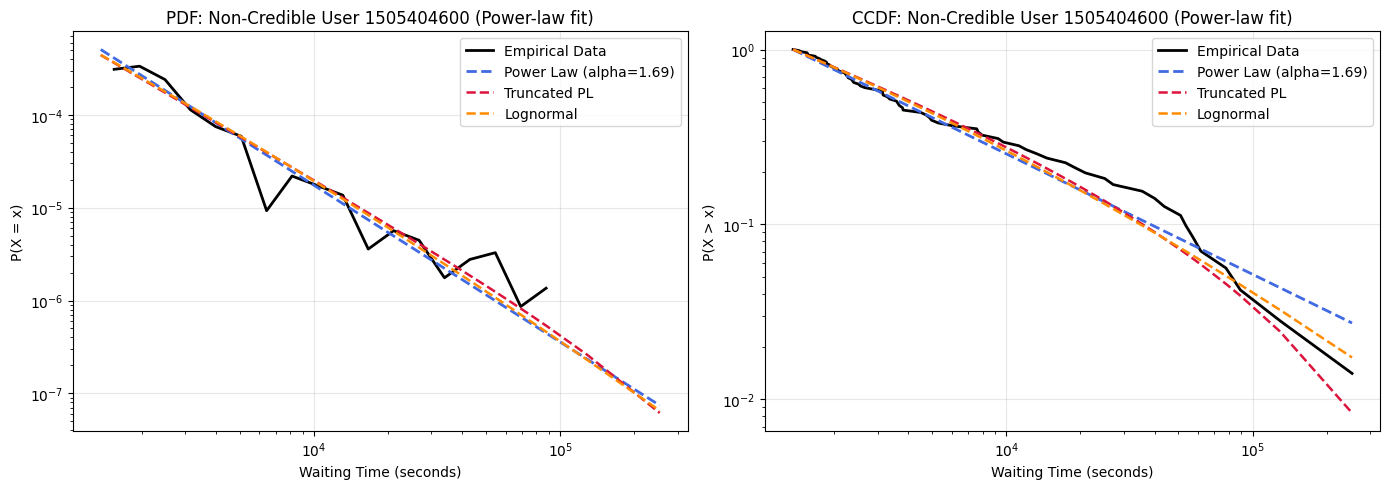

TRUNCATED POWER LAW FIT RESULTS: Non-Credible User 1505404600
alpha: 1.5460
lambda: nan
xmin: 1359.0000
sigma: nan
Data points above xmin: 71 / 386 (18.39%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.4046, p = 0.0930
  No significant difference

Truncated PL vs Lognormal:
  R = 1.9746, p = 0.0483
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 3.9208, p = 0.0001
  Truncated power law is significantly better

KS distance (truncated power law): 0.0922
KS p-value (tail): 0.551702


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


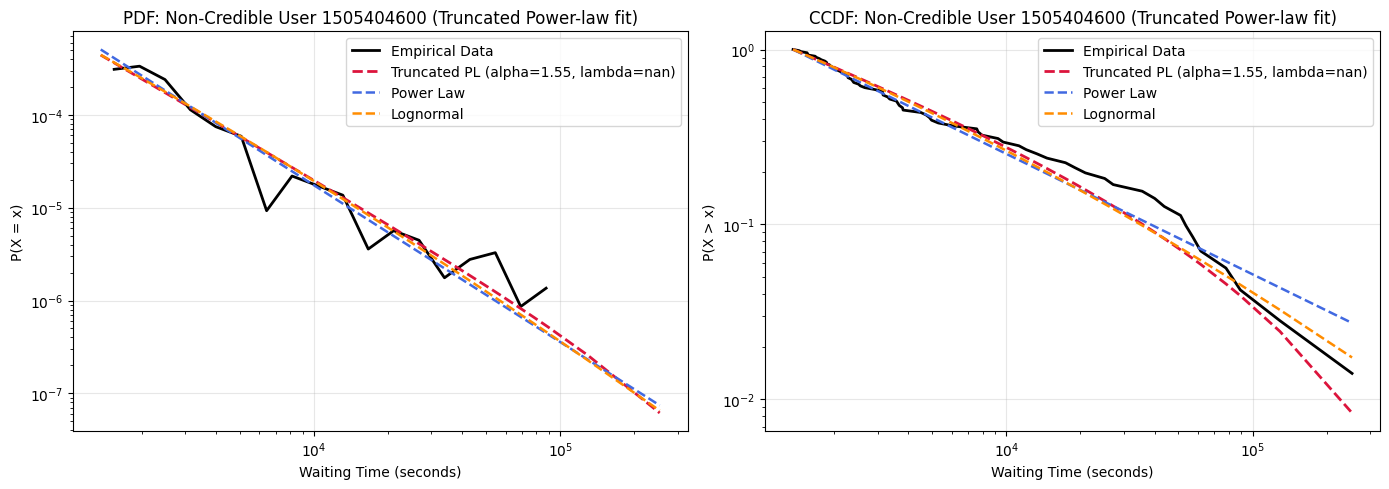



Analyzing waiting times for Non-Credible User 6973904485...
POWER LAW FIT RESULTS: Non-Credible User 6973904485
alpha: 1.4882
xmin: 666.0000
sigma: 0.0401
Data points above xmin: 148 / 320 (46.25%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -2.1533, p = 0.0012
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.9453, p = 0.0517
  No significant difference

Power Law vs Exponential:
  R = 3.4776, p = 0.0005
  Power law is significantly better

KS distance (power law): 0.0861
KS p-value (tail): 0.145851


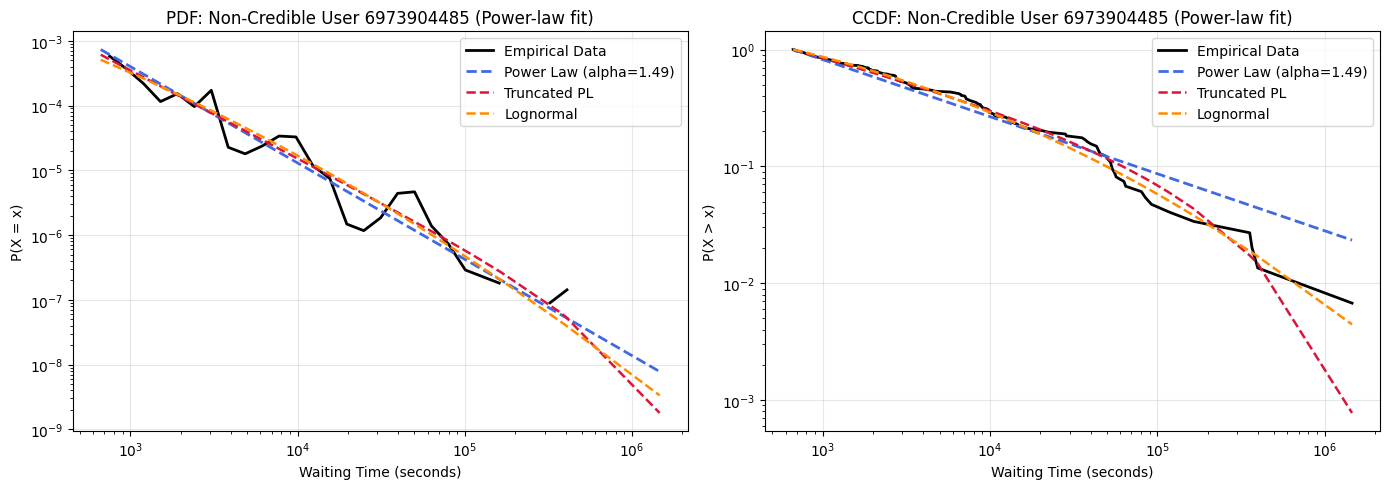

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Non-Credible User 6973904485
alpha: 1.3568
lambda: nan
xmin: 666.0000
sigma: nan
Data points above xmin: 148 / 320 (46.25%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.1533, p = 0.0012
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 0.0605, p = 0.9518
  No significant difference

Truncated PL vs Exponential:
  R = 3.7737, p = 0.0002
  Truncated power law is significantly better

KS distance (truncated power law): 0.0431
KS p-value (tail): 0.836579


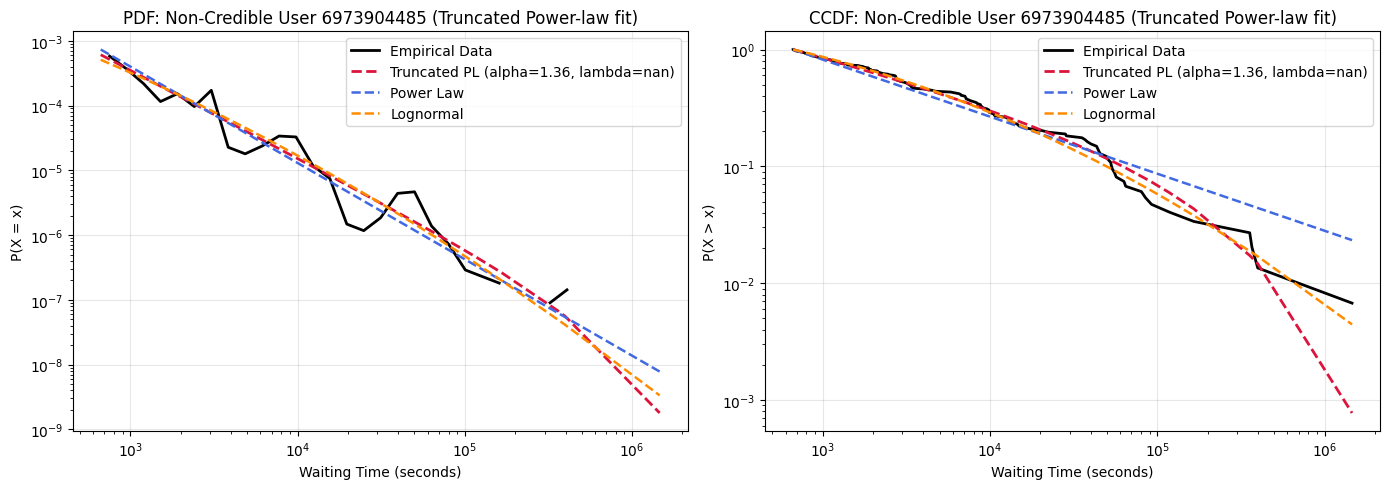



Analyzing waiting times for Non-Credible User 6221273187...
POWER LAW FIT RESULTS: Non-Credible User 6221273187
alpha: 1.5494
xmin: 238.0000
sigma: 0.0499
Data points above xmin: 121 / 267 (45.32%)

POWER LAW COMPARISONS


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



Power Law vs Truncated PL:
  R = -1.9279, p = 0.0372
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -0.8337, p = 0.4044
  No significant difference

Power Law vs Exponential:
  R = 6.0302, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0503
KS p-value (tail): 0.787966


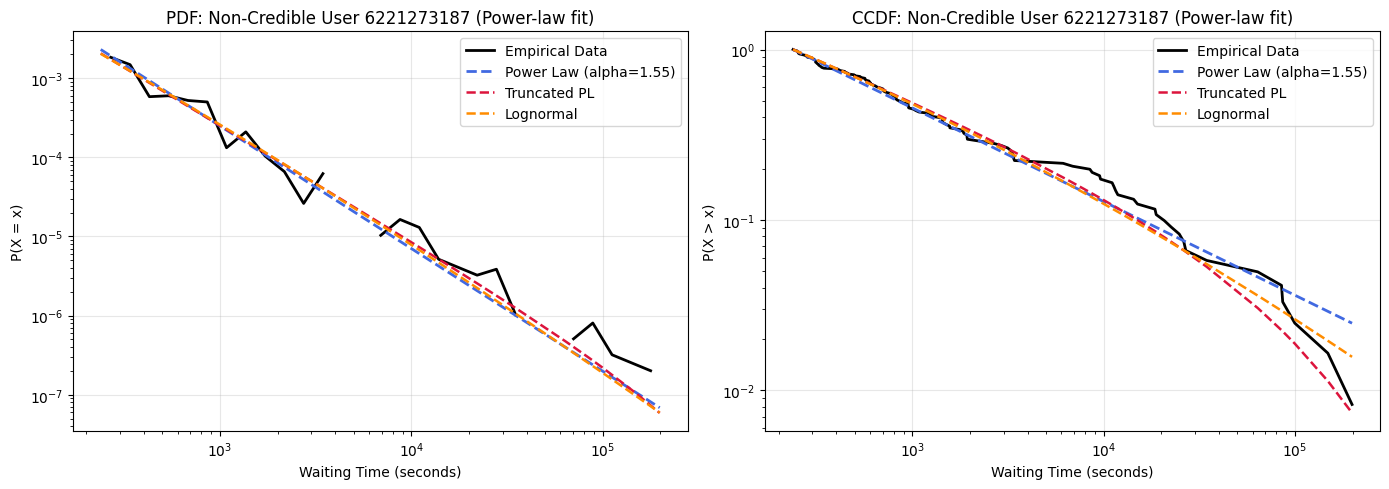

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Non-Credible User 6221273187
alpha: 1.4620
lambda: nan
xmin: 238.0000
sigma: nan
Data points above xmin: 121 / 267 (45.32%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 1.9279, p = 0.0372
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 2.4913, p = 0.0127
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 6.3295, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0668
KS p-value (tail): 0.628478


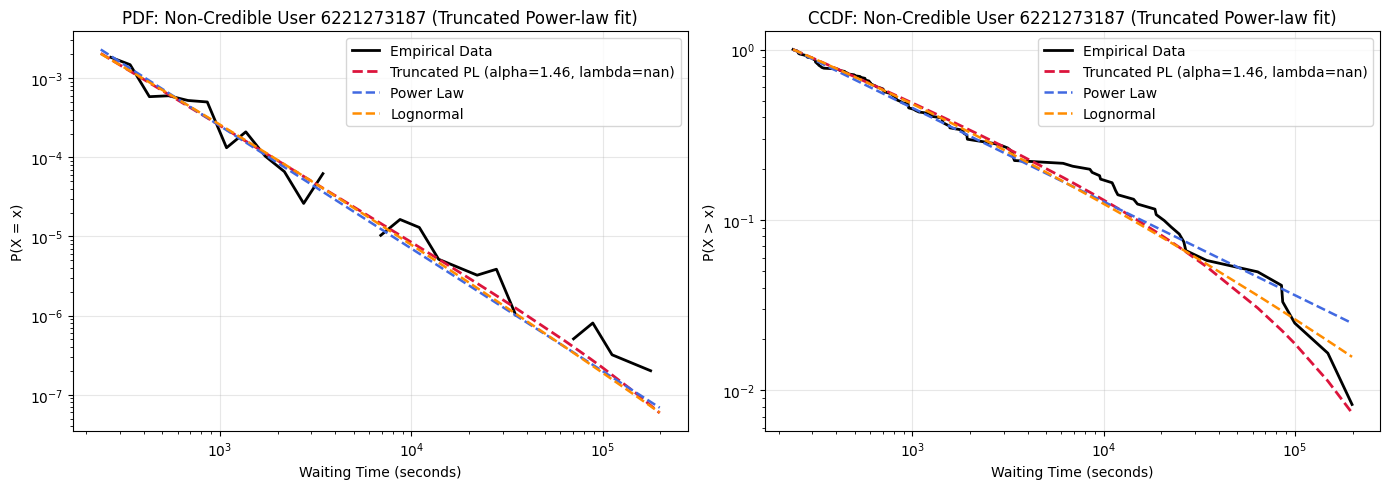



Analyzing waiting times for Non-Credible User 1151037126...
POWER LAW FIT RESULTS: Non-Credible User 1151037126
alpha: 1.5188
xmin: 749.0000
sigma: 0.0527
Data points above xmin: 97 / 213 (45.54%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -2.1324, p = 0.0095
  truncated power law is significantly better

Power Law vs Lognormal:
  R = -1.2532, p = 0.2101
  No significant difference

Power Law vs Exponential:
  R = 4.8499, p = 0.0000
  Power law is significantly better

KS distance (power law): 0.0630
KS p-value (tail): 0.646724


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


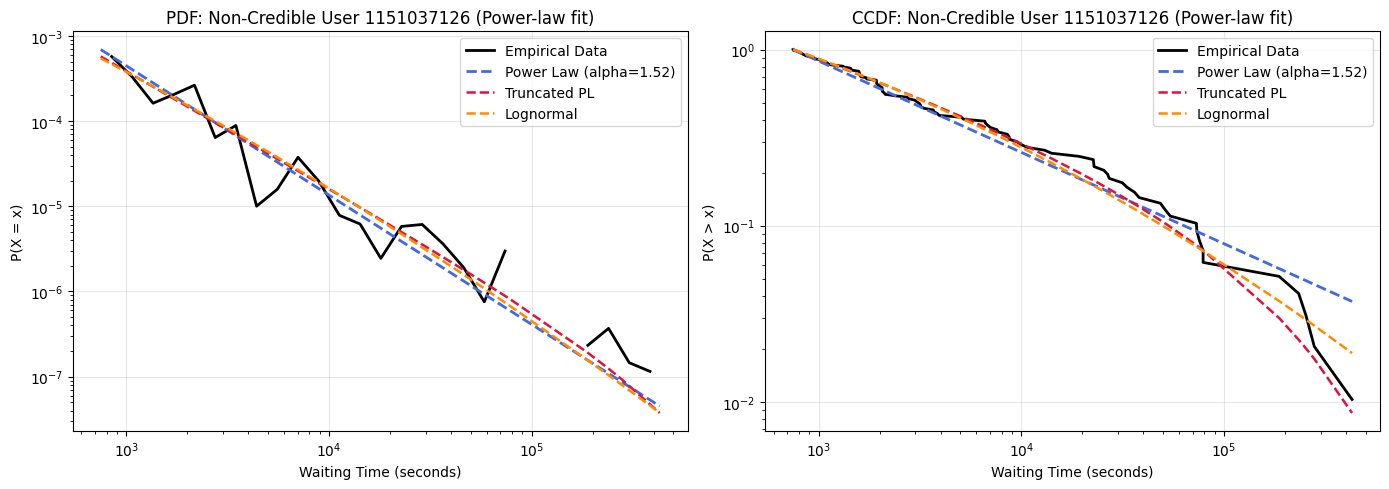

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Non-Credible User 1151037126
alpha: 1.3765
lambda: nan
xmin: 749.0000
sigma: nan
Data points above xmin: 97 / 213 (45.54%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.1324, p = 0.0095
  Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 2.4212, p = 0.0155
  Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 5.3959, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0822
KS p-value (tail): 0.502172


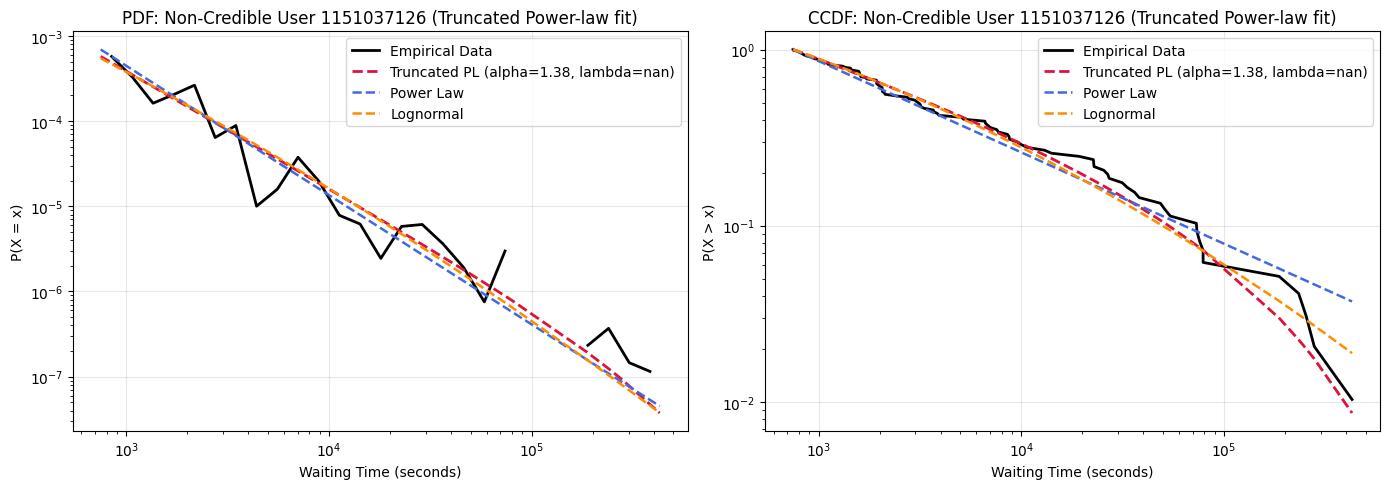



Analyzing waiting times for Non-Credible User 6938249017...
POWER LAW FIT RESULTS: Non-Credible User 6938249017
alpha: 2.2259
xmin: 44980.0000
sigma: 0.3276
Data points above xmin: 14 / 62 (22.58%)

POWER LAW COMPARISONS

Power Law vs Truncated PL:
  R = -0.5166, p = 0.5456
  No significant difference

Power Law vs Lognormal:
  R = -0.2507, p = 0.8020
  No significant difference

Power Law vs Exponential:
  R = 1.1364, p = 0.2558
  No significant difference

KS distance (power law): 0.1206
KS p-value (tail): 0.971803


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


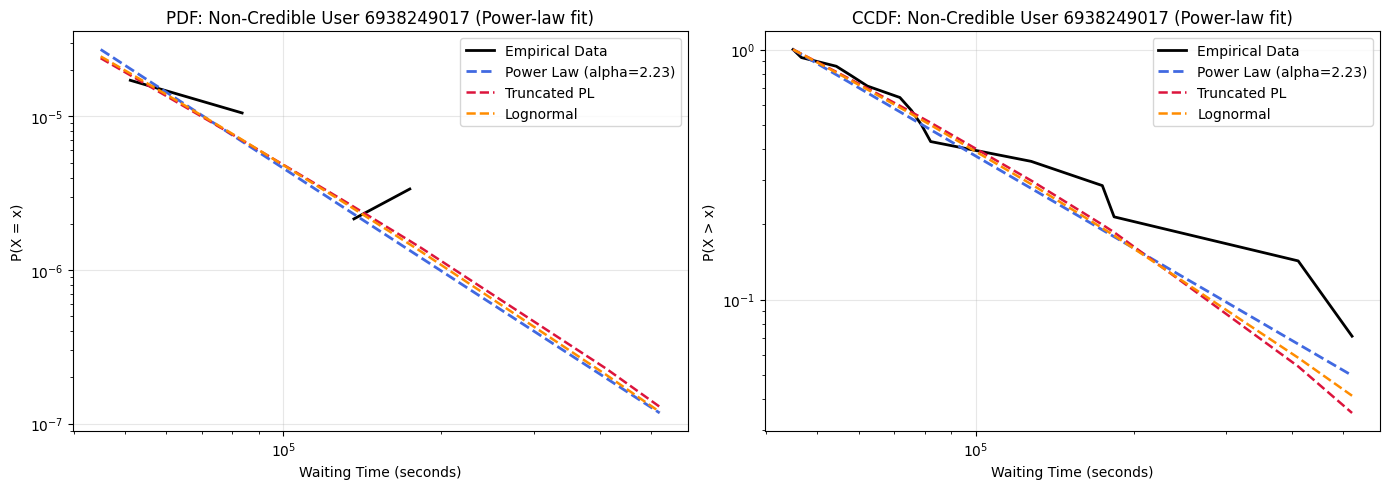

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS: Non-Credible User 6938249017
alpha: 1.9162
lambda: nan
xmin: 44980.0000
sigma: nan
Data points above xmin: 14 / 62 (22.58%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 0.5166, p = 0.5456
  No significant difference

Truncated PL vs Lognormal:
  R = 0.8210, p = 0.4117
  No significant difference

Truncated PL vs Exponential:
  R = 1.4586, p = 0.1447
  No significant difference

KS distance (truncated power law): 0.1528
KS p-value (tail): 0.851803


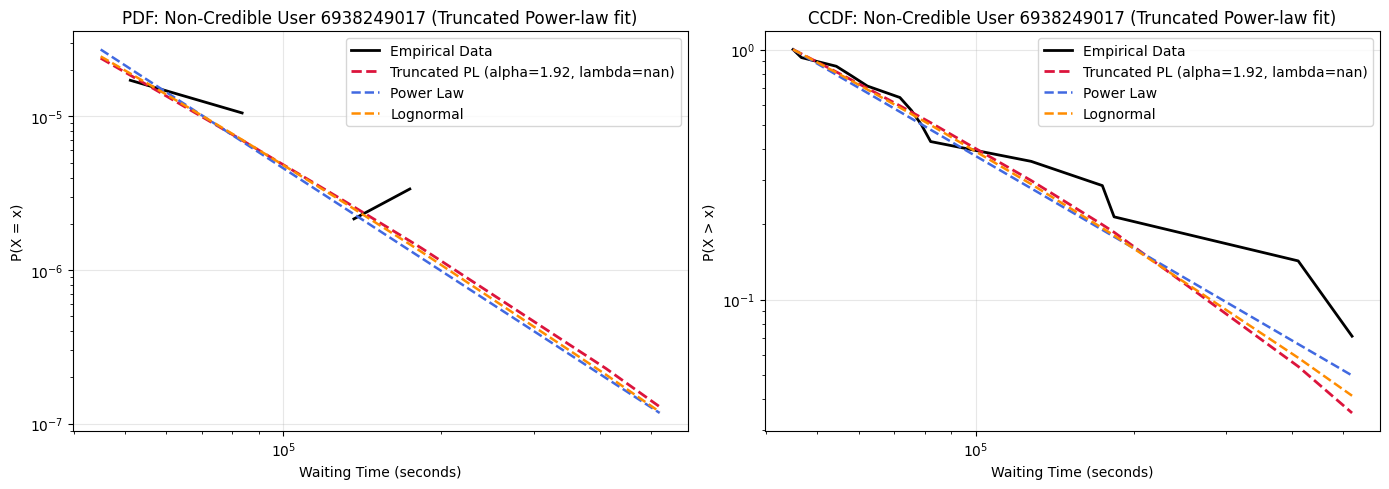

In [ ]:
for user in non_credible_active_users:
    user_messages = non_credible_messages[non_credible_messages['sender_id'] == user] # Gather messages sent by the user.
    user_dates = pd.to_datetime(user_messages['date'], errors='coerce').dropna()
    waiting_time = user_dates.diff().dropna()
    # Fit the waiting time to a power-law distribution and plot it with comparisons to other distributions and KS test on the tail
    print(f"\n\nAnalyzing waiting times for Non-Credible User {user}...")
    fit_power_law_report(waiting_time.dt.total_seconds(), f"Non-Credible User {user}")
    fit_truncated_power_law_report(waiting_time.dt.total_seconds(), f"Non-Credible User {user}")


### Comparison of alpha for the different users

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

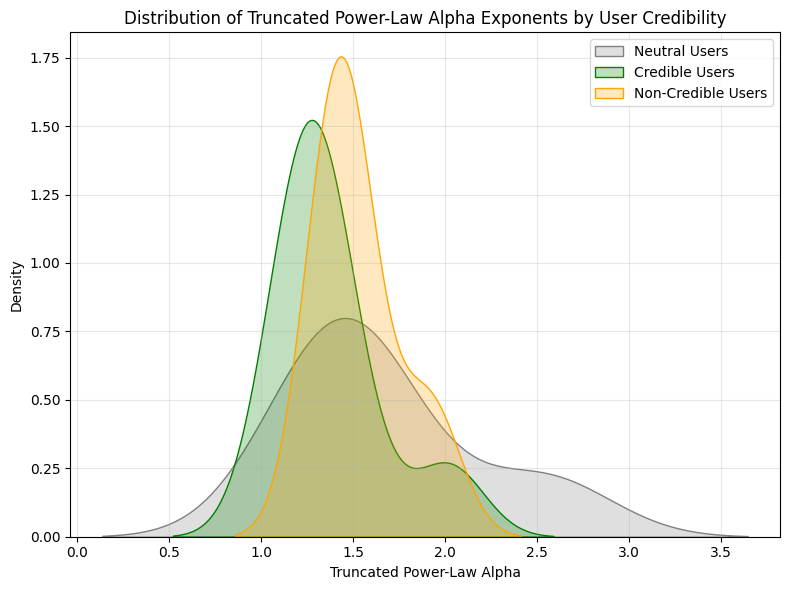

In [ ]:
neutral_credibility_alphas, neutral_credibility_lambdas = extract_truncated_power_law_params(neutral_credibility_active_users, neutral_credibility_messages)
credible_alphas, credible_lambdas = extract_truncated_power_law_params(credible_active_users, credible_messages)
non_credible_alphas, non_credible_lambdas = extract_truncated_power_law_params(non_credible_active_users, non_credible_messages)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(neutral_credibility_alphas, color='gray', label='Neutral Users', fill=True)
sns.kdeplot(credible_alphas, color='green', label='Credible Users', fill=True)
sns.kdeplot(non_credible_alphas, color='orange', label='Non-Credible Users', fill=True)
plt.xlabel('Truncated Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Truncated Power-Law Alpha Exponents by User Credibility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

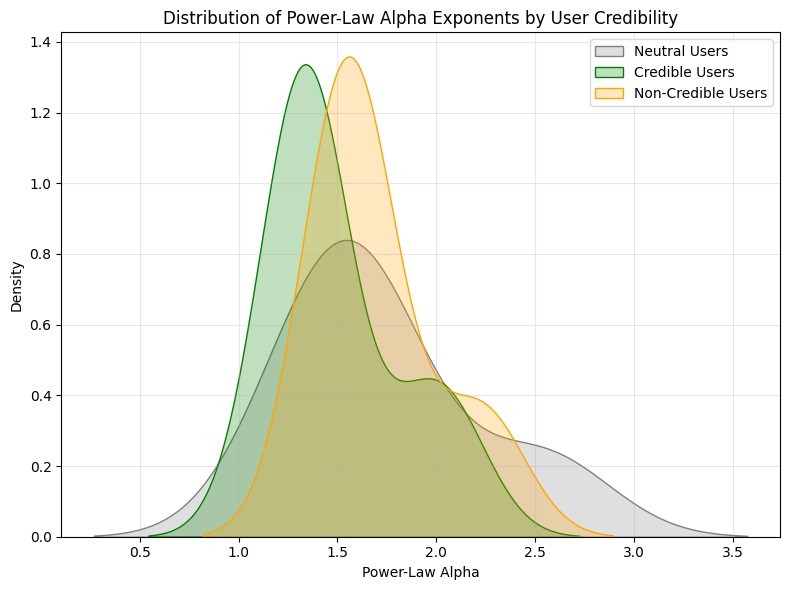

In [ ]:
neutral_credibility_alphas, neutral_credibility_lambdas = extract_power_law_params(neutral_credibility_active_users, neutral_credibility_messages)
credible_alphas, credible_lambdas = extract_power_law_params(credible_active_users, credible_messages)
non_credible_alphas, non_credible_lambdas = extract_power_law_params(non_credible_active_users, non_credible_messages)
# Plot the distributions of alpha and lambda for each ideology group
plt.figure(figsize=(8,6))
sns.kdeplot(neutral_credibility_alphas, color='gray', label='Neutral Users', fill=True)
sns.kdeplot(credible_alphas, color='green', label='Credible Users', fill=True)
sns.kdeplot(non_credible_alphas, color='orange', label='Non-Credible Users', fill=True)
plt.xlabel('Power-Law Alpha')
plt.ylabel('Density')
plt.title('Distribution of Power-Law Alpha Exponents by User Credibility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()